In [ ]:
#                                                    UPI TRANSACTION ANALYSIS

In [ ]:
#                                             Capstone Project by - KAUSTUBH SINHA

In [1]:
# Installing Packages

!pip install pandas openpyxl sqlalchemy pymysql

In [2]:
# Importing Libraries

import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text
from getpass import getpass

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# TASK: Setting the file locations

excel_file = r"D:\DATA ANALYTICS\Projects\Capstones\upi_analysis_package\UPI Transaction Analysis by KAUSTUBH SINHA\Data Processing\UPI_Caps_r.xlsx"
transaction_csv = r"D:\DATA ANALYTICS\Projects\Capstones\upi_analysis_package\Midway\UPI_Caps_r_CSV_Calculated_Values_Exact\upi_transaction_history.csv"

print("Excel file:", excel_file)
print("Transaction CSV:", transaction_csv)

Excel file: D:\DATA ANALYTICS\Projects\Capstones\upi_analysis_package\UPI Transaction Analysis by KAUSTUBH SINHA\Data Processing\UPI_Caps_r.xlsx
Transaction CSV: D:\DATA ANALYTICS\Projects\Capstones\upi_analysis_package\Midway\UPI_Caps_r_CSV_Calculated_Values_Exact\upi_transaction_history.csv


In [6]:
# Connecting jupyter to existing MySQL database

from sqlalchemy import create_engine, URL
from getpass import getpass

mysql_user = input("Enter your MySQL username: ")
mysql_password = getpass("Enter your MySQL password: ")

connection_url = URL.create(
    "mysql+pymysql",
    username=mysql_user,
    password=mysql_password,
    host="127.0.0.1",
    port=3306,
    database="upi_analytics"
)

engine = create_engine(connection_url)

print("Connection settings created successfully.")

Enter your MySQL username:  root
Enter your MySQL password:  ········


Connection settings created successfully.


In [8]:
# Running a connection test

with engine.connect() as connection:
    result = connection.execute(text("SELECT DATABASE();"))
    print("Connected database:", result.scalar())

Connected database: upi_analytics


In [ ]:
# NOTE: customer_master, merchant_info, upi_account_details, device_info have already been
# populated into SQL using MySQL import methods.

# Remaining 3 csv files, namely, upi_transaction_history, customer_feedback_surverys, 
# fraud_alert_history shall be uploaded here using Python

In [9]:
# Reading transaction_csv

transactions = pd.read_csv(
    transaction_csv,
    low_memory=False
)

print("Transaction data loaded into Pandas.")
print("Rows:", len(transactions))
print("Columns:", len(transactions.columns))

Transaction data loaded into Pandas.
Rows: 100000
Columns: 29


In [10]:
# Checking Transaction Columns

print("Transaction columns:")
for i, col in enumerate(transactions.columns, start=1):
    print(f"{i:2}. {col}")

Transaction columns:
 1. transaction_id
 2. trans_id_blank_chk
 3. trans_id_unique_chk
 4. upi_id
 5. customer_id
 6. timestamp
 7. transaction_date
 8. transaction_time
 9. amount
10. transaction_type
11. transact_type_typo_chk
12. merchant_id
13. counterparty_upi
14. status
15. status_typo_chk
16. device_id
17. device_type
18. device_type_typo_chk
19. channel
20. channel_typo_chk
21. fraud_flag
22. reversal_flag
23. failure_reason
24. customer_chk
25. merchant_chk
26. upi_chk
27. device_chk
28. Failure_reason_chk
29. validation_status


In [11]:
# Validating transaction IDs before inserting

print("Blank transaction IDs:",
      transactions["transaction_id"].isna().sum())

print("Duplicate transaction IDs:",
      transactions["transaction_id"].duplicated().sum())

print("Rows:",
      len(transactions))

Blank transaction IDs: 0
Duplicate transaction IDs: 0
Rows: 100000


In [12]:
# Verifying timestamp

transactions["timestamp"] = pd.to_datetime(
    transactions["timestamp"],
    format="mixed",
    errors="raise"
)

print("Timestamp conversion successful.")
print("Minimum timestamp:", transactions["timestamp"].min())
print("Maximum timestamp:", transactions["timestamp"].max())

Timestamp conversion successful.
Minimum timestamp: 2020-10-18 17:38:50.925000
Maximum timestamp: 2025-08-06 08:06:00.531000


In [13]:
# missing value check

check_columns = [
    "transaction_id",
    "upi_id",
    "customer_id",
    "timestamp",
    "amount",
    "transaction_type",
    "status",
    "device_id",
    "device_type",
    "channel"
]

print(transactions[check_columns].isna().sum())

transaction_id      0
upi_id              0
customer_id         0
timestamp           0
amount              0
transaction_type    0
status              0
device_id           0
device_type         0
channel             0
dtype: int64


In [14]:
# Checking foreign key compatibility

with engine.connect() as connection:

    customer_ids = set(
        pd.read_sql(
            "SELECT customer_id FROM customer_master",
            connection
        )["customer_id"]
    )

    upi_ids = set(
        pd.read_sql(
            "SELECT upi_id FROM upi_account_details",
            connection
        )["upi_id"]
    )

    device_ids = set(
        pd.read_sql(
            "SELECT device_id FROM device_info",
            connection
        )["device_id"]
    )

    merchant_ids = set(
        pd.read_sql(
            "SELECT merchant_id FROM merchant_info",
            connection
        )["merchant_id"]
    )

print(
    "Invalid customer IDs:",
    (~transactions["customer_id"].isin(customer_ids)).sum()
)

print(
    "Invalid UPI IDs:",
    (~transactions["upi_id"].isin(upi_ids)).sum()
)

print(
    "Invalid device IDs:",
    (~transactions["device_id"].isin(device_ids)).sum()
)

print(
    "Invalid merchant IDs:",
    (
        transactions["merchant_id"].notna()
        & ~transactions["merchant_id"].isin(merchant_ids)
    ).sum()
)

Invalid customer IDs: 0
Invalid UPI IDs: 0
Invalid device IDs: 0
Invalid merchant IDs: 0


In [15]:
# Final safety check before inserting transactions

with engine.connect() as connection:
    result = connection.execute(
        text("SELECT COUNT(*) FROM upi_transaction_history")
    )
    current_count = result.scalar()

print("Current transaction rows in MySQL:", current_count)

if current_count == 0:
    print("SAFE TO LOAD: Transaction table is empty.")
else:
    print("STOP: Transaction table already contains data.")

Current transaction rows in MySQL: 0
SAFE TO LOAD: Transaction table is empty.


In [16]:
# Preparing the transaction data for MySQL

transactions_to_load = transactions.copy()

# Convert date/time fields
transactions_to_load["timestamp"] = pd.to_datetime(
    transactions_to_load["timestamp"],
    format="mixed",
    errors="raise"
)

transactions_to_load["transaction_date"] = pd.to_datetime(
    transactions_to_load["transaction_date"],
    errors="raise"
).dt.date

# Convert transaction_time to Python time objects
transactions_to_load["transaction_time"] = pd.to_datetime(
    transactions_to_load["transaction_time"].astype(str),
    format="%H:%M:%S.%f",
    errors="coerce"
).dt.time

# Convert Boolean fields to integers for reliable MySQL insertion
transactions_to_load["fraud_flag"] = (
    transactions_to_load["fraud_flag"].astype(bool).astype(int)
)

transactions_to_load["reversal_flag"] = (
    transactions_to_load["reversal_flag"].astype(bool).astype(int)
)

print("Transaction data prepared for MySQL.")
print("Rows:", len(transactions_to_load))
print("Columns:", len(transactions_to_load.columns))

Transaction data prepared for MySQL.
Rows: 100000
Columns: 29


In [17]:
# Checking the prepared Data

display(
    transactions_to_load[
        [
            "transaction_id",
            "customer_id",
            "timestamp",
            "transaction_date",
            "transaction_time",
            "amount",
            "transaction_type",
            "status",
            "fraud_flag",
            "reversal_flag"
        ]
    ].head()
)

,transaction_id,customer_id,timestamp,transaction_date,transaction_time,amount,transaction_type,status,fraud_flag,reversal_flag
0,txn10000000,cust101488,2025-06-04 21:36:20.000,2025-06-04,NaT,9.88,send,success,0,0
1,txn10000001,cust107876,2025-05-22 04:26:44.200,2025-05-22,04:26:44.200000,76.25,receive,success,0,0
2,txn10000002,cust100901,2025-08-02 02:34:14.690,2025-08-02,02:34:14.690000,26.44,merchant_payment,success,0,0
3,txn10000003,cust105890,2025-01-30 03:53:31.110,2025-01-30,03:53:31.110000,84.43,send,success,0,0
4,txn10000004,cust106780,2025-07-05 21:36:52.813,2025-07-05,21:36:52.813000,10.33,receive,success,0,0


In [18]:
# insertion

import time

start_time = time.time()

print("Starting transaction upload...")
print("Total rows to upload:", len(transactions_to_load))

transactions_to_load.to_sql(
    name="upi_transaction_history",
    con=engine,
    if_exists="append",
    index=False,
    chunksize=2000,
    method="multi"
)

elapsed_time = time.time() - start_time

print()
print("Transaction upload completed successfully.")
print(f"Time taken: {elapsed_time:.2f} seconds")

Starting transaction upload...
Total rows to upload: 100000

Transaction upload completed successfully.
Time taken: 84.15 seconds


In [19]:
# verifying transaction count

with engine.connect() as connection:
    result = connection.execute(
        text("SELECT COUNT(*) FROM upi_transaction_history")
    )
    transaction_count = result.scalar()

print("Transaction rows now in MySQL:", transaction_count)

if transaction_count == 100000:
    print("✅ SUCCESS: All 100,000 transaction records are loaded.")
else:
    print("⚠️ Row count does not match expected 100,000.")


Transaction rows now in MySQL: 100000
✅ SUCCESS: All 100,000 transaction records are loaded.


In [20]:
# Verifying the transaction data in MySQL

query = """
SELECT
    transaction_id,
    customer_id,
    timestamp,
    amount,
    transaction_type,
    status,
    device_id,
    device_type,
    channel,
    fraud_flag,
    reversal_flag
FROM upi_transaction_history
LIMIT 10;
"""

transaction_sample = pd.read_sql_query(query, engine)

display(transaction_sample)

,transaction_id,customer_id,timestamp,amount,transaction_type,status,device_id,device_type,channel,fraud_flag,reversal_flag
0,txn10000000,cust101488,2025-06-04 21:36:20.000,9.88,send,success,dev101488,feature_phone,app,0,0
1,txn10000001,cust107876,2025-05-22 04:26:44.200,76.25,receive,success,dev107876,ios,app,0,0
2,txn10000002,cust100901,2025-08-02 02:34:14.690,26.44,merchant_payment,success,dev100901,android,intent,0,0
3,txn10000003,cust105890,2025-01-30 03:53:31.110,84.43,send,success,dev105890,tablet,qr_code,0,0
4,txn10000004,cust106780,2025-07-05 21:36:52.813,10.33,receive,success,dev106780,tablet,qr_code,0,0
5,txn10000005,cust102097,2025-04-02 10:32:59.170,37.61,send,success,dev201416,ios,qr_code,0,0
6,txn10000006,cust108896,2024-07-30 03:10:27.963,77.74,send,failed,dev108896,feature_phone,app,0,1
7,txn10000007,cust102418,2025-08-05 11:36:34.926,47.46,receive,success,dev102418,tablet,intent,0,0
8,txn10000008,cust109937,2025-05-10 08:12:13.377,19.94,merchant_payment,success,dev109937,android,qr_code,0,0
9,txn10000009,cust108084,2024-12-24 02:50:08.866,13.95,receive,success,dev200757,feature_phone,qr_code,0,0


In [21]:
# Verifying the important transaction statistics

sql_summary = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS total_transactions,
        MIN(amount) AS minimum_amount,
        MAX(amount) AS maximum_amount,
        AVG(amount) AS average_amount,
        SUM(fraud_flag) AS fraud_transactions,
        SUM(reversal_flag) AS reversed_transactions
    FROM upi_transaction_history;
    """,
    engine
)

display(sql_summary)

,total_transactions,minimum_amount,maximum_amount,average_amount,fraud_transactions,reversed_transactions
0,100000,1.62,830.46,42.417743,2000.0,1451.0


In [22]:
# reading feedback sheet

feedback = pd.read_excel(
    excel_file,
    sheet_name="customer_feedback_surveys"
)

print("Customer feedback data loaded.")
print("Rows:", len(feedback))
print("Columns:", len(feedback.columns))

Customer feedback data loaded.
Rows: 4000
Columns: 9


In [23]:
# inspecting feedback sheet column

In [24]:
print("Feedback columns:")

for i, col in enumerate(feedback.columns, start=1):
    print(f"{i:2}. {col}")

Feedback columns:
 1. feedback_id
 2. customer_id
 3. date_submitted
 4. feedback_text
 5. satisfaction_score
 6. issue_type
 7. issue_type_typo_chk
 8. resolved
 9. customer_chk


In [26]:
# validating feedback data

print("Blank feedback IDs:",
      feedback["feedback_id"].isna().sum())

print("Duplicate feedback IDs:",
      feedback["feedback_id"].duplicated().sum())

print("Invalid satisfaction scores:",
      (~feedback["satisfaction_score"].between(1, 5)).sum())

print("Missing customer IDs:",
      feedback["customer_id"].isna().sum())

Blank feedback IDs: 0
Duplicate feedback IDs: 0
Invalid satisfaction scores: 0
Missing customer IDs: 0


In [28]:
# checking customer foreign keys

invalid_feedback_customers = (
    ~feedback["customer_id"].isin(customer_ids)
).sum()

print("Invalid customer IDs:", invalid_feedback_customers)

if invalid_feedback_customers == 0:
    print("✅ All feedback customer IDs exist in customer_master.")
else:
    print("⚠️ Invalid customer references found.")

Invalid customer IDs: 0
✅ All feedback customer IDs exist in customer_master.


In [29]:
#preparing data and boolean fields

feedback_to_load = feedback.copy()

feedback_to_load["date_submitted"] = pd.to_datetime(
    feedback_to_load["date_submitted"],
    errors="raise"
).dt.date

feedback_to_load["resolved"] = (
    feedback_to_load["resolved"].astype(bool).astype(int)
)

print("Feedback data prepared for MySQL.")
print("Rows:", len(feedback_to_load))

Feedback data prepared for MySQL.
Rows: 4000


In [30]:
# confirming MySQL table is empty

with engine.connect() as connection:
    result = connection.execute(
        text("SELECT COUNT(*) FROM customer_feedback_surveys")
    )
    feedback_count_before = result.scalar()

print("Current feedback rows in MySQL:", feedback_count_before)

if feedback_count_before == 0:
    print("SAFE TO LOAD.")
else:
    print("STOP: Feedback table already contains data.")

Current feedback rows in MySQL: 0
SAFE TO LOAD.


In [31]:
# Inserting 4000 feedback records

start_time = time.time()

feedback_to_load.to_sql(
    name="customer_feedback_surveys",
    con=engine,
    if_exists="append",
    index=False,
    chunksize=1000,
    method="multi"
)

elapsed_time = time.time() - start_time

print("Customer feedback upload completed successfully.")
print(f"Time taken: {elapsed_time:.2f} seconds")

Customer feedback upload completed successfully.
Time taken: 1.50 seconds


In [32]:
# Verifying upload

with engine.connect() as connection:
    result = connection.execute(
        text("SELECT COUNT(*) FROM customer_feedback_surveys")
    )
    feedback_count = result.scalar()

print("Feedback rows now in MySQL:", feedback_count)

if feedback_count == 4000:
    print("✅ SUCCESS: All 4,000 feedback records are loaded.")
else:
    print("⚠️ Row count does not match expected 4,000.")

Feedback rows now in MySQL: 4000
✅ SUCCESS: All 4,000 feedback records are loaded.


In [35]:
# Verifying actual records

feedback_sample = pd.read_sql_query(
    """
    SELECT
        feedback_id,
        customer_id,
        date_submitted,
        satisfaction_score,
        issue_type,
        resolved
    FROM customer_feedback_surveys
    LIMIT 10;
    """,
    engine
)

print(" First 10 records from customer_feedback_surveys")
display(feedback_sample)

 First 10 records from customer_feedback_survey


,feedback_id,customer_id,date_submitted,satisfaction_score,issue_type,resolved
0,fdbk100000,cust106029,2021-08-14,4,fraud,1
1,fdbk100001,cust101758,2025-03-30,3,transaction,0
2,fdbk100002,cust107269,2025-07-24,4,app_usability,0
3,fdbk100003,cust108175,2024-06-07,4,app_usability,0
4,fdbk100004,cust101420,2022-01-12,3,transaction,1
5,fdbk100005,cust102792,2023-06-17,3,other,1
6,fdbk100006,cust108392,2025-03-24,1,app_usability,1
7,fdbk100007,cust106515,2024-08-30,4,fraud,1
8,fdbk100008,cust106934,2024-03-05,4,fraud,1
9,fdbk100009,cust104509,2022-06-08,4,other,1


In [36]:
# Loading fraud_alert_history

fraud_alerts = pd.read_excel(
    excel_file,
    sheet_name="fraud_alert_history"
)

print("Fraud alert data loaded.")
print("Rows:", len(fraud_alerts))
print("Columns:", len(fraud_alerts.columns))

Fraud alert data loaded.
Rows: 2000
Columns: 13


In [37]:
# checking columns

print("Fraud alert columns:")
print(fraud_alerts.columns.tolist())

Fraud alert columns:
['alert_id', 'transaction_id', 'alert_type', 'alert_tpe_typo_chk', 'alert_date', 'alert_date_only', 'alert_time', 'resolved', 'resolution_date', 'resolution_date_only', 'resolution_time', 'remarks', 'transaction_chk']


In [38]:
# validating alert records

print("Blank alert IDs:",
      fraud_alerts["alert_id"].isna().sum())

print("Duplicate alert IDs:",
      fraud_alerts["alert_id"].duplicated().sum())

print("Blank transaction IDs:",
      fraud_alerts["transaction_id"].isna().sum())

print("Missing alert types:",
      fraud_alerts["alert_type"].isna().sum())

print("Missing transaction validation:",
      fraud_alerts["transaction_chk"].isna().sum())

Blank alert IDs: 0
Duplicate alert IDs: 0
Blank transaction IDs: 0
Missing alert types: 0
Missing transaction validation: 0


In [39]:
# checking alert types

print("Alert types:")
print(fraud_alerts["alert_type"].value_counts(dropna=False))

Alert types:
alert_type
unusual_time        507
frequent_failure    501
suspicious_login    498
unusual_amount      494
Name: count, dtype: int64


In [40]:
# verifying transaction foreign keys

transaction_ids = set(
    transactions["transaction_id"].astype(str)
)

invalid_alert_transactions = (
    ~fraud_alerts["transaction_id"].astype(str).isin(transaction_ids)
).sum()

print("Invalid transaction references:",
      invalid_alert_transactions)

if invalid_alert_transactions == 0:
    print("✅ All fraud alert transaction IDs exist in upi_transaction_history.")
else:
    print("⚠️ Invalid transaction references found.")

Invalid transaction references: 0
✅ All fraud alert transaction IDs exist in upi_transaction_history.


In [43]:
# Preparing dates and boolean fields

fraud_alerts_to_load = fraud_alerts.copy()

# Main alert datetime
fraud_alerts_to_load["alert_date"] = pd.to_datetime(
    fraud_alerts_to_load["alert_date"],
    errors="raise"
)

# Alert date-only
fraud_alerts_to_load["alert_date_only"] = pd.to_datetime(
    fraud_alerts_to_load["alert_date_only"],
    errors="raise"
).dt.date

# Alert time
fraud_alerts_to_load["alert_time"] = pd.to_datetime(
    fraud_alerts_to_load["alert_time"].astype(str),
    format="%H:%M:%S",
    errors="coerce"
).dt.time

# Resolution datetime
# Blank values are expected for unresolved alerts
fraud_alerts_to_load["resolution_date"] = pd.to_datetime(
    fraud_alerts_to_load["resolution_date"],
    errors="coerce"
)

# Resolution date-only
fraud_alerts_to_load["resolution_date_only"] = pd.to_datetime(
    fraud_alerts_to_load["resolution_date_only"],
    errors="coerce"
).dt.date

# Resolution time
fraud_alerts_to_load["resolution_time"] = pd.to_datetime(
    fraud_alerts_to_load["resolution_time"].astype(str),
    format="%H:%M:%S",
    errors="coerce"
).dt.time

# Boolean → MySQL-compatible 0/1
fraud_alerts_to_load["resolved"] = (
    fraud_alerts_to_load["resolved"]
    .astype(bool)
    .astype(int)
)

print("Fraud alert data prepared for MySQL.")
print("Rows:", len(fraud_alerts_to_load))

Fraud alert data prepared for MySQL.
Rows: 2000


In [44]:
# confirming MySQL table is empty

with engine.connect() as connection:
    result = connection.execute(
        text("SELECT COUNT(*) FROM fraud_alert_history")
    )
    fraud_count_before = result.scalar()

print("Current fraud alert rows in MySQL:",
      fraud_count_before)

if fraud_count_before == 0:
    print("SAFE TO LOAD.")
else:
    print("STOP: Fraud alert table already contains data.")

Current fraud alert rows in MySQL: 0
SAFE TO LOAD.


In [45]:
# Loading fraud_alert_history

start_time = time.time()

fraud_alerts_to_load.to_sql(
    name="fraud_alert_history",
    con=engine,
    if_exists="append",
    index=False,
    chunksize=1000,
    method="multi"
)

elapsed_time = time.time() - start_time

print("Fraud alert upload completed successfully.")
print(f"Time taken: {elapsed_time:.2f} seconds")

Fraud alert upload completed successfully.
Time taken: 1.08 seconds


In [46]:
#verifying fraud_alert_history upload

with engine.connect() as connection:
    result = connection.execute(
        text("SELECT COUNT(*) FROM fraud_alert_history")
    )
    fraud_count = result.scalar()

print("Fraud alert rows now in MySQL:", fraud_count)

if fraud_count == 2000:
    print("✅ SUCCESS: All 2,000 fraud alert records are loaded.")
else:
    print("⚠️ Row count does not match expected 2,000.")

Fraud alert rows now in MySQL: 2000
✅ SUCCESS: All 2,000 fraud alert records are loaded.


In [49]:
# spot checking Loaded data

fraud_sample = pd.read_sql_query(
    """
    SELECT
        alert_id,
        transaction_id,
        alert_type,
        alert_date,
        resolved,
        resolution_date
    FROM fraud_alert_history
    LIMIT 10;
    """,
    engine
)

print("First 10 data of fraud_alert_history :\n")
display(fraud_sample)

First 10 data of fraud_alert_history :



,alert_id,transaction_id,alert_type,alert_date,resolved,resolution_date
0,alert100022,txn10000022,frequent_failure,2025-06-28 16:15:37.089,1,2025-06-29 23:15:37.089
1,alert100052,txn10000052,suspicious_login,2024-10-06 01:00:25.171,0,NaT
2,alert100067,txn10000067,suspicious_login,2025-02-20 19:40:33.241,1,2025-02-22 01:40:33.241
3,alert100235,txn10000235,unusual_amount,2024-11-15 15:00:38.265,1,2024-11-18 12:00:38.265
4,alert100383,txn10000383,unusual_time,2025-01-19 07:20:05.585,0,NaT
5,alert100427,txn10000427,frequent_failure,2025-04-26 07:27:19.314,1,2025-04-27 20:27:19.314
6,alert100457,txn10000457,suspicious_login,2025-07-24 03:19:11.331,1,2025-07-26 14:19:11.331
7,alert100491,txn10000491,unusual_amount,2025-06-22 15:20:06.563,1,2025-06-23 20:20:06.563
8,alert100532,txn10000532,unusual_amount,2025-07-16 00:29:28.489,1,2025-07-17 19:29:28.489
9,alert100570,txn10000570,unusual_amount,2024-12-01 09:03:30.645,1,2024-12-02 13:03:30.645


In [50]:
print(" ALL FILES SUCCESSFULLY LOADED ")

 ALL FILES SUCCESSFULLY LOADED 


In [ ]:
#    STEP 4: Data Ingestion into SQl

In [51]:
# Validating row counts across all seven SQL tables after data ingestion.

expected_counts = {
    "customer_master": 10000,
    "device_info": 12000,
    "upi_account_details": 12000,
    "merchant_info": 500,
    "upi_transaction_history": 100000,
    "customer_feedback_surveys": 4000,
    "fraud_alert_history": 2000
}

actual_counts = {}

with engine.connect() as connection:
    for table_name in expected_counts:
        result = connection.execute(
            text(f"SELECT COUNT(*) FROM {table_name}")
        )
        actual_counts[table_name] = result.scalar()

print("SQL TABLE ROW COUNT VALIDATION")
print("=" * 50)

for table_name, expected in expected_counts.items():
    actual = actual_counts[table_name]

    status = "PASS" if actual == expected else "FAIL"

    print(
        f"{table_name:<30} "
        f"Expected: {expected:<7} "
        f"Actual: {actual:<7} "
        f"{status}"
    )

SQL TABLE ROW COUNT VALIDATION
customer_master                Expected: 10000   Actual: 10000   PASS
device_info                    Expected: 12000   Actual: 12000   PASS
upi_account_details            Expected: 12000   Actual: 12000   PASS
merchant_info                  Expected: 500     Actual: 500     PASS
upi_transaction_history        Expected: 100000  Actual: 100000  PASS
customer_feedback_surveys      Expected: 4000    Actual: 4000    PASS
fraud_alert_history            Expected: 2000    Actual: 2000    PASS


In [52]:
# Validating primary-key uniqueness across all seven SQL tables.

primary_keys = {
    "customer_master": "customer_id",
    "device_info": "device_id",
    "upi_account_details": "upi_id",
    "merchant_info": "merchant_id",
    "upi_transaction_history": "transaction_id",
    "customer_feedback_surveys": "feedback_id",
    "fraud_alert_history": "alert_id"
}

print("PRIMARY KEY UNIQUENESS VALIDATION")
print("=" * 50)

for table_name, pk_column in primary_keys.items():

    query = text(f"""
        SELECT
            COUNT(*) AS total_rows,
            COUNT(DISTINCT {pk_column}) AS unique_keys
        FROM {table_name}
    """)

    with engine.connect() as connection:
        result = connection.execute(query).fetchone()

    total_rows = result[0]
    unique_keys = result[1]

    if total_rows == unique_keys:
        status = "PASS"
    else:
        status = "FAIL"

    print(
        f"{table_name:<30} "
        f"Rows: {total_rows:<7} "
        f"Unique {pk_column}: {unique_keys:<7} "
        f"{status}"
    )

PRIMARY KEY UNIQUENESS VALIDATION
customer_master                Rows: 10000   Unique customer_id: 10000   PASS
device_info                    Rows: 12000   Unique device_id: 12000   PASS
upi_account_details            Rows: 12000   Unique upi_id: 12000   PASS
merchant_info                  Rows: 500     Unique merchant_id: 500     PASS
upi_transaction_history        Rows: 100000  Unique transaction_id: 100000  PASS
customer_feedback_surveys      Rows: 4000    Unique feedback_id: 4000    PASS
fraud_alert_history            Rows: 2000    Unique alert_id: 2000    PASS


In [53]:
# Validating foreign-key relationships between the seven SQL tables after ingestion.

foreign_key_checks = {

    "Transaction → Customer": """
        SELECT COUNT(*)
        FROM upi_transaction_history t
        LEFT JOIN customer_master c
            ON t.customer_id = c.customer_id
        WHERE c.customer_id IS NULL
    """,

    "Transaction → UPI Account": """
        SELECT COUNT(*)
        FROM upi_transaction_history t
        LEFT JOIN upi_account_details u
            ON t.upi_id = u.upi_id
        WHERE u.upi_id IS NULL
    """,

    "Transaction → Merchant": """
        SELECT COUNT(*)
        FROM upi_transaction_history t
        LEFT JOIN merchant_info m
            ON t.merchant_id = m.merchant_id
        WHERE t.merchant_id IS NOT NULL
          AND m.merchant_id IS NULL
    """,

    "Transaction → Device": """
        SELECT COUNT(*)
        FROM upi_transaction_history t
        LEFT JOIN device_info d
            ON t.device_id = d.device_id
        WHERE d.device_id IS NULL
    """,

    "Feedback → Customer": """
        SELECT COUNT(*)
        FROM customer_feedback_surveys f
        LEFT JOIN customer_master c
            ON f.customer_id = c.customer_id
        WHERE c.customer_id IS NULL
    """,

    "Fraud Alert → Transaction": """
        SELECT COUNT(*)
        FROM fraud_alert_history a
        LEFT JOIN upi_transaction_history t
            ON a.transaction_id = t.transaction_id
        WHERE t.transaction_id IS NULL
    """
}

print("FOREIGN KEY VALIDATION")
print("=" * 50)

for relationship, query in foreign_key_checks.items():

    with engine.connect() as connection:
        invalid_count = connection.execute(text(query)).scalar()

    status = "PASS" if invalid_count == 0 else "FAIL"

    print(
        f"{relationship:<30} "
        f"Invalid references: {invalid_count:<5} "
        f"{status}"
    )

FOREIGN KEY VALIDATION
Transaction → Customer         Invalid references: 0     PASS
Transaction → UPI Account      Invalid references: 0     PASS
Transaction → Merchant         Invalid references: 0     PASS
Transaction → Device           Invalid references: 0     PASS
Feedback → Customer            Invalid references: 0     PASS
Fraud Alert → Transaction      Invalid references: 0     PASS


In [54]:
#  Performing random spot checks to confirm that key transaction fields were mapped correctly into MySQL.

import random

random_transactions = transactions.sample(
    n=5,
    random_state=42
)

spot_check_ids = random_transactions["transaction_id"].tolist()

placeholders = ", ".join(
    [f":id{i}" for i in range(len(spot_check_ids))]
)

params = {
    f"id{i}": transaction_id
    for i, transaction_id in enumerate(spot_check_ids)
}

query = text(f"""
    SELECT
        transaction_id,
        customer_id,
        upi_id,
        timestamp,
        amount,
        transaction_type,
        status,
        device_id,
        fraud_flag,
        reversal_flag
    FROM upi_transaction_history
    WHERE transaction_id IN ({placeholders})
    ORDER BY transaction_id
""")

with engine.connect() as connection:
    mysql_spot_check = pd.read_sql_query(
        query,
        connection,
        params=params
    )

display(mysql_spot_check)

,transaction_id,customer_id,upi_id,timestamp,amount,transaction_type,status,device_id,fraud_flag,reversal_flag
0,txn10019864,cust105540,david6285@upi,2025-05-16 01:56:22.989,122.80,receive,success,dev105540,0,0
1,txn10075721,cust102329,renee8165@upi,2025-08-05 06:23:00.467,124.40,send,success,dev102329,0,0
2,txn10076699,cust101715,eddie4234@upi,2025-04-07 09:55:54.566,22.44,merchant_payment,success,dev101715,0,0
3,txn10080184,cust103610,diana8876@upi,2025-07-13 14:24:55.960,17.53,receive,success,dev103610,0,0
4,txn10092991,cust108270,benjamin8032@upi,2025-01-30 15:44:30.855,21.82,receive,success,dev108270,0,0


In [55]:
# Automatically compare randomly selected transaction records between the Pandas source data and MySQL.

source_spot_check = (
    transactions[
        transactions["transaction_id"].isin(spot_check_ids)
    ][
        [
            "transaction_id",
            "customer_id",
            "upi_id",
            "timestamp",
            "amount",
            "transaction_type",
            "status",
            "device_id",
            "fraud_flag",
            "reversal_flag"
        ]
    ]
    .copy()
)

mysql_spot_check = mysql_spot_check.copy()

# Normalize timestamp representation for comparison
source_spot_check["timestamp"] = pd.to_datetime(
    source_spot_check["timestamp"]
)

mysql_spot_check["timestamp"] = pd.to_datetime(
    mysql_spot_check["timestamp"]
)

source_spot_check = source_spot_check.sort_values(
    "transaction_id"
).reset_index(drop=True)

mysql_spot_check = mysql_spot_check.sort_values(
    "transaction_id"
).reset_index(drop=True)

comparison_result = source_spot_check.equals(
    mysql_spot_check
)

print("Spot-check comparison result:", comparison_result)

if comparison_result:
    print("✅ PASS: Randomly selected transaction records match between source and MySQL.")
else:
    print("⚠️ REVIEW: Differences detected in the spot-check records.")

Spot-check comparison result: False
⚠️ REVIEW: Differences detected in the spot-check records.


In [56]:
# Diagnosing exactly which fields differ between the source transaction data and the MySQL spot-check records.

# Make copies so the original dataframes are not modified
source_check = source_spot_check.copy()
mysql_check = mysql_spot_check.copy()

# Normalize transaction IDs and text fields
source_check["transaction_id"] = source_check["transaction_id"].astype(str)
mysql_check["transaction_id"] = mysql_check["transaction_id"].astype(str)

source_check["customer_id"] = source_check["customer_id"].astype(str)
mysql_check["customer_id"] = mysql_check["customer_id"].astype(str)

source_check["upi_id"] = source_check["upi_id"].astype(str)
mysql_check["upi_id"] = mysql_check["upi_id"].astype(str)

source_check["device_id"] = source_check["device_id"].astype(str)
mysql_check["device_id"] = mysql_check["device_id"].astype(str)

source_check["transaction_type"] = source_check["transaction_type"].astype(str)
mysql_check["transaction_type"] = mysql_check["transaction_type"].astype(str)

source_check["status"] = source_check["status"].astype(str)
mysql_check["status"] = mysql_check["status"].astype(str)

# Normalize timestamps to millisecond precision
source_check["timestamp"] = pd.to_datetime(
    source_check["timestamp"]
).dt.round("ms")

mysql_check["timestamp"] = pd.to_datetime(
    mysql_check["timestamp"]
).dt.round("ms")

# Normalize amount to 2 decimal places
source_check["amount"] = pd.to_numeric(
    source_check["amount"]
).round(2)

mysql_check["amount"] = pd.to_numeric(
    mysql_check["amount"]
).round(2)

# Normalize boolean flags to integers
source_check["fraud_flag"] = (
    source_check["fraud_flag"]
    .astype(bool)
    .astype(int)
)

mysql_check["fraud_flag"] = (
    mysql_check["fraud_flag"]
    .astype(bool)
    .astype(int)
)

source_check["reversal_flag"] = (
    source_check["reversal_flag"]
    .astype(bool)
    .astype(int)
)

mysql_check["reversal_flag"] = (
    mysql_check["reversal_flag"]
    .astype(bool)
    .astype(int)
)

# Sort both datasets identically
source_check = source_check.sort_values(
    "transaction_id"
).reset_index(drop=True)

mysql_check = mysql_check.sort_values(
    "transaction_id"
).reset_index(drop=True)

# Compare each column individually
print("FIELD-BY-FIELD SPOT CHECK")
print("=" * 50)

for column in source_check.columns:

    matches = (
        source_check[column].equals(
            mysql_check[column]
        )
    )

    print(
        f"{column:<20} : "
        f"{'MATCH' if matches else 'DIFFERENCE'}"
    )

FIELD-BY-FIELD SPOT CHECK
transaction_id       : MATCH
customer_id          : MATCH
upi_id               : MATCH
timestamp            : MATCH
amount               : MATCH
transaction_type     : MATCH
status               : MATCH
device_id            : MATCH
fraud_flag           : MATCH
reversal_flag        : MATCH


In [60]:
# Updating the final spot-check result using the normalized field-by-field comparison from Cell 42A.

normalized_results = []

for column in source_check.columns:
    normalized_results.append(
        source_check[column].equals(mysql_check[column])
    )

comparison_result = all(normalized_results)

print("Normalized spot-check comparison result:", comparison_result)

if comparison_result:
    print("RESULT: PASS — All sampled transaction fields match MySQL.")
else:
    print("RESULT: FAIL — At least one normalized field still differs.")

Normalized spot-check comparison result: True
RESULT: PASS — All sampled transaction fields match MySQL.


In [57]:
# Since all values MATCH, what this proves

# The earlier 'Spot-check comparison result: False'

# was not a data-ingestion failure. It was caused by differences in how Pandas represented some values/datatypes when comparing the source CSV dataframe with the MySQL dataframe.

# After normalizing the representations, the actual values match exactly.

# So we can officially mark:

# Step 4 — Data Ingestion & Validation: PASSED ✅

In [61]:
# Performing the final Step 4 audit by confirming row counts, primary-key uniqueness, foreign-key integrity, and transaction spot-check results.

print("=" * 70)
print("STEP 4 — FINAL DATA INGESTION & VALIDATION AUDIT")
print("=" * 70)

# Expected row counts
expected_counts = {
    "customer_master": 10000,
    "device_info": 12000,
    "upi_account_details": 12000,
    "merchant_info": 500,
    "upi_transaction_history": 100000,
    "customer_feedback_surveys": 4000,
    "fraud_alert_history": 2000
}

# Actual row counts from MySQL
actual_counts = {
    "customer_master": len(pd.read_sql_query(
        "SELECT * FROM customer_master", engine
    )),
    "device_info": len(pd.read_sql_query(
        "SELECT * FROM device_info", engine
    )),
    "upi_account_details": len(pd.read_sql_query(
        "SELECT * FROM upi_account_details", engine
    )),
    "merchant_info": len(pd.read_sql_query(
        "SELECT * FROM merchant_info", engine
    )),
    "upi_transaction_history": len(pd.read_sql_query(
        "SELECT * FROM upi_transaction_history", engine
    )),
    "customer_feedback_surveys": len(pd.read_sql_query(
        "SELECT * FROM customer_feedback_surveys", engine
    )),
    "fraud_alert_history": len(pd.read_sql_query(
        "SELECT * FROM fraud_alert_history", engine
    ))
}

# Row-count validation
row_count_pass = all(
    actual_counts[table] == expected_counts[table]
    for table in expected_counts
)

print("\n1. ROW COUNT VALIDATION")
for table in expected_counts:
    print(
        f"{table:<30} "
        f"Expected: {expected_counts[table]:>7,} | "
        f"Actual: {actual_counts[table]:>7,} | "
        f"{'PASS' if actual_counts[table] == expected_counts[table] else 'FAIL'}"
    )

# Primary-key validation
pk_queries = {
    "customer_master": """
        SELECT COUNT(*) AS total,
               COUNT(DISTINCT customer_id) AS unique_ids
        FROM customer_master
    """,
    "device_info": """
        SELECT COUNT(*) AS total,
               COUNT(DISTINCT device_id) AS unique_ids
        FROM device_info
    """,
    "upi_account_details": """
        SELECT COUNT(*) AS total,
               COUNT(DISTINCT upi_id) AS unique_ids
        FROM upi_account_details
    """,
    "merchant_info": """
        SELECT COUNT(*) AS total,
               COUNT(DISTINCT merchant_id) AS unique_ids
        FROM merchant_info
    """,
    "upi_transaction_history": """
        SELECT COUNT(*) AS total,
               COUNT(DISTINCT transaction_id) AS unique_ids
        FROM upi_transaction_history
    """,
    "customer_feedback_surveys": """
        SELECT COUNT(*) AS total,
               COUNT(DISTINCT feedback_id) AS unique_ids
        FROM customer_feedback_surveys
    """,
    "fraud_alert_history": """
        SELECT COUNT(*) AS total,
               COUNT(DISTINCT alert_id) AS unique_ids
        FROM fraud_alert_history
    """
}

pk_pass = True

print("\n2. PRIMARY-KEY UNIQUENESS")

for table, query in pk_queries.items():
    result = pd.read_sql_query(query, engine).iloc[0]

    passed = result["total"] == result["unique_ids"]
    pk_pass = pk_pass and passed

    print(
        f"{table:<30} "
        f"Total: {int(result['total']):>7,} | "
        f"Unique: {int(result['unique_ids']):>7,} | "
        f"{'PASS' if passed else 'FAIL'}"
    )

# Foreign-key validation
fk_checks = {
    "upi_account_details → customer_master": """
        SELECT COUNT(*) AS invalid_count
        FROM upi_account_details u
        LEFT JOIN customer_master c
            ON u.customer_id = c.customer_id
        WHERE c.customer_id IS NULL
    """,

    "device_info → customer_master": """
        SELECT COUNT(*) AS invalid_count
        FROM device_info d
        LEFT JOIN customer_master c
            ON d.customer_id = c.customer_id
        WHERE c.customer_id IS NULL
    """,

    "transactions → customer_master": """
        SELECT COUNT(*) AS invalid_count
        FROM upi_transaction_history t
        LEFT JOIN customer_master c
            ON t.customer_id = c.customer_id
        WHERE c.customer_id IS NULL
    """,

    "transactions → upi_account_details": """
        SELECT COUNT(*) AS invalid_count
        FROM upi_transaction_history t
        LEFT JOIN upi_account_details u
            ON t.upi_id = u.upi_id
        WHERE u.upi_id IS NULL
    """,

    "transactions → device_info": """
        SELECT COUNT(*) AS invalid_count
        FROM upi_transaction_history t
        LEFT JOIN device_info d
            ON t.device_id = d.device_id
        WHERE d.device_id IS NULL
    """,

    "transactions → merchant_info": """
        SELECT COUNT(*) AS invalid_count
        FROM upi_transaction_history t
        LEFT JOIN merchant_info m
            ON t.merchant_id = m.merchant_id
        WHERE t.merchant_id IS NOT NULL
          AND m.merchant_id IS NULL
    """,

    "feedback → customer_master": """
        SELECT COUNT(*) AS invalid_count
        FROM customer_feedback_surveys f
        LEFT JOIN customer_master c
            ON f.customer_id = c.customer_id
        WHERE c.customer_id IS NULL
    """,

    "fraud_alerts → transactions": """
        SELECT COUNT(*) AS invalid_count
        FROM fraud_alert_history f
        LEFT JOIN upi_transaction_history t
            ON f.transaction_id = t.transaction_id
        WHERE t.transaction_id IS NULL
    """
}

fk_pass = True

print("\n3. FOREIGN-KEY VALIDATION")

for relationship, query in fk_checks.items():
    invalid_count = int(
        pd.read_sql_query(query, engine).iloc[0]["invalid_count"]
    )

    passed = invalid_count == 0
    fk_pass = fk_pass and passed

    print(
        f"{relationship:<40} "
        f"Invalid references: {invalid_count:>5} | "
        f"{'PASS' if passed else 'FAIL'}"
    )

# Spot-check result
spot_check_pass = comparison_result

print("\n4. RANDOM TRANSACTION SPOT CHECK")
print(
    f"Normalized source vs MySQL comparison: "
    f"{'PASS' if spot_check_pass else 'FAIL'}"
)

# Final audit
overall_pass = row_count_pass and pk_pass and fk_pass and spot_check_pass

print("\n" + "=" * 70)

if overall_pass:
    print("FINAL STEP 4 RESULT: PASS")
    print("All ingestion and validation checks passed successfully.")
else:
    print("FINAL STEP 4 RESULT: REVIEW REQUIRED")
    print("One or more validation checks failed.")

print("=" * 70)

STEP 4 — FINAL DATA INGESTION & VALIDATION AUDIT

1. ROW COUNT VALIDATION
customer_master                Expected:  10,000 | Actual:  10,000 | PASS
device_info                    Expected:  12,000 | Actual:  12,000 | PASS
upi_account_details            Expected:  12,000 | Actual:  12,000 | PASS
merchant_info                  Expected:     500 | Actual:     500 | PASS
upi_transaction_history        Expected: 100,000 | Actual: 100,000 | PASS
customer_feedback_surveys      Expected:   4,000 | Actual:   4,000 | PASS
fraud_alert_history            Expected:   2,000 | Actual:   2,000 | PASS

2. PRIMARY-KEY UNIQUENESS
customer_master                Total:  10,000 | Unique:  10,000 | PASS
device_info                    Total:  12,000 | Unique:  12,000 | PASS
upi_account_details            Total:  12,000 | Unique:  12,000 | PASS
merchant_info                  Total:     500 | Unique:     500 | PASS
upi_transaction_history        Total: 100,000 | Unique: 100,000 | PASS
customer_feedback_surveys 

In [62]:
#    Step 5: Connecting Python to SQL

In [63]:
# Confirming that Python can securely connect to the existing MySQL UPI analytics database before loading the project tables.

from sqlalchemy import text

with engine.connect() as connection:
    database_name = connection.execute(
        text("SELECT DATABASE();")
    ).scalar()

print("=" * 70)
print("STEP 5 — PYTHON–SQL INTEGRATION")
print("=" * 70)
print()
print("Connected database:", database_name)

if database_name == "upi_analytics":
    print("Connection status: PASS")
else:
    print("Connection status: REVIEW REQUIRED")

STEP 5 — PYTHON–SQL INTEGRATION

Connected database: upi_analytics
Connection status: PASS


In [64]:
# Loading all seven UPI project tables from MySQL into Pandas DataFrames for Python-based analysis.

# List of all project tables
table_names = [
    "customer_master",
    "device_info",
    "upi_account_details",
    "merchant_info",
    "upi_transaction_history",
    "customer_feedback_surveys",
    "fraud_alert_history"
]

# Dictionary to store each table as a Pandas DataFrame
sql_tables = {}

# Load each table from MySQL
for table in table_names:
    query = f"SELECT * FROM `{table}`"
    sql_tables[table] = pd.read_sql_query(query, engine)

# Create convenient DataFrame variables
customers = sql_tables["customer_master"]
devices = sql_tables["device_info"]
accounts = sql_tables["upi_account_details"]
transactions = sql_tables["upi_transaction_history"]
merchants = sql_tables["merchant_info"]
feedback = sql_tables["customer_feedback_surveys"]
fraud_alerts = sql_tables["fraud_alert_history"]

print("=" * 70)
print("STEP 5 — SQL TABLES LOADED INTO PANDAS")
print("=" * 70)

for table, df in sql_tables.items():
    print(f"{table:<30} : {df.shape[0]:>8,} rows × {df.shape[1]:>2} columns")

print("=" * 70)
print("All seven SQL tables loaded successfully.")

STEP 5 — SQL TABLES LOADED INTO PANDAS
customer_master                :   10,000 rows × 10 columns
device_info                    :   12,000 rows × 10 columns
upi_account_details            :   12,000 rows ×  9 columns
merchant_info                  :      500 rows ×  8 columns
upi_transaction_history        :  100,000 rows × 29 columns
customer_feedback_surveys      :    4,000 rows ×  9 columns
fraud_alert_history            :    2,000 rows × 13 columns
All seven SQL tables loaded successfully.


In [66]:
# TASK: Validating that all seven MySQL tables loaded into Pandas with the exact column names and column order defined by the project SQL schema.

# Expected schemas based on the actual project SQL DDL
expected_columns = {
    "customer_master": [
        "customer_id",
        "full_name",
        "mobile_number",
        "age",
        "gender",
        "gender_typo_chk",
        "region",
        "date_joined",
        "is_business_user",
        "risk_score"
    ],

    "device_info": [
        "device_id",
        "customer_id",
        "device_type",
        "app_version",
        "is_rooted",
        "last_active",
        "last_active_date",
        "last_active_time",
        "customer_chk",
        "device_type_typo_chk"
    ],

    "upi_account_details": [
        "upi_id",
        "customer_id",
        "bank_name",
        "bank_name_typo_chk",
        "account_type",
        "account_type_typo_chk",
        "date_added",
        "status",
        "customer_chk"
    ],

    "merchant_info": [
        "merchant_id",
        "merchant_name",
        "merchant_type",
        "merch_type_typo_chk",
        "region",
        "region_typo_chk",
        "onboard_date",
        "risk_score"
    ],

    "upi_transaction_history": [
        "transaction_id",
        "trans_id_blank_chk",
        "trans_id_unique_chk",
        "upi_id",
        "customer_id",
        "timestamp",
        "transaction_date",
        "transaction_time",
        "amount",
        "transaction_type",
        "transact_type_typo_chk",
        "merchant_id",
        "counterparty_upi",
        "status",
        "status_typo_chk",
        "device_id",
        "device_type",
        "device_type_typo_chk",
        "channel",
        "channel_typo_chk",
        "fraud_flag",
        "reversal_flag",
        "failure_reason",
        "customer_chk",
        "merchant_chk",
        "upi_chk",
        "device_chk",
        "Failure_reason_chk",
        "validation_status"
    ],

    "customer_feedback_surveys": [
        "feedback_id",
        "customer_id",
        "date_submitted",
        "feedback_text",
        "satisfaction_score",
        "issue_type",
        "issue_type_typo_chk",
        "resolved",
        "customer_chk"
    ],

    "fraud_alert_history": [
        "alert_id",
        "transaction_id",
        "alert_type",
        "alert_tpe_typo_chk",
        "alert_date",
        "alert_date_only",
        "alert_time",
        "resolved",
        "resolution_date",
        "resolution_date_only",
        "resolution_time",
        "remarks",
        "transaction_chk"
    ]
}

print("=" * 70)
print("STEP 5 — CORRECTED SCHEMA VALIDATION")
print("=" * 70)

schema_results = {}

for table, expected in expected_columns.items():

    actual = list(sql_tables[table].columns)

    columns_match = actual == expected
    count_match = len(actual) == len(expected)

    schema_results[table] = columns_match and count_match

    print(f"\n{table}")
    print(f"Expected columns : {len(expected)}")
    print(f"Actual columns   : {len(actual)}")
    print(f"Column structure : {'PASS' if columns_match else 'FAIL'}")

    if not columns_match:
        missing = [col for col in expected if col not in actual]
        unexpected = [col for col in actual if col not in expected]

        print("Missing columns   :", missing)
        print("Unexpected columns:", unexpected)

overall_schema_pass = all(schema_results.values())

print("\n" + "=" * 70)
print(
    "OVERALL SCHEMA VALIDATION:",
    "PASS" if overall_schema_pass else "REVIEW REQUIRED"
)
print("=" * 70)

STEP 5 — CORRECTED SCHEMA VALIDATION

customer_master
Expected columns : 10
Actual columns   : 10
Column structure : PASS

device_info
Expected columns : 10
Actual columns   : 10
Column structure : PASS

upi_account_details
Expected columns : 9
Actual columns   : 9
Column structure : PASS

merchant_info
Expected columns : 8
Actual columns   : 8
Column structure : PASS

upi_transaction_history
Expected columns : 29
Actual columns   : 29
Column structure : PASS

customer_feedback_surveys
Expected columns : 9
Actual columns   : 9
Column structure : PASS

fraud_alert_history
Expected columns : 13
Actual columns   : 13
Column structure : PASS

OVERALL SCHEMA VALIDATION: PASS


In [67]:
# Comparing the Pandas row counts loaded from MySQL against the expected project dataset counts.

expected_row_counts = {
    "customer_master": 10000,
    "device_info": 12000,
    "upi_account_details": 12000,
    "merchant_info": 500,
    "upi_transaction_history": 100000,
    "customer_feedback_surveys": 4000,
    "fraud_alert_history": 2000
}

row_count_validation = []

for table, expected_count in expected_row_counts.items():

    actual_count = len(sql_tables[table])

    row_count_validation.append({
        "table": table,
        "expected_rows": expected_count,
        "actual_rows": actual_count,
        "difference": actual_count - expected_count,
        "status": "PASS" if actual_count == expected_count else "FAIL"
    })

row_count_validation_df = pd.DataFrame(row_count_validation)

print("=" * 70)
print("STEP 5 — PANDAS ROW COUNT VALIDATION")
print("=" * 70)

print(row_count_validation_df.to_string(index=False))

overall_row_count_pass = (
    row_count_validation_df["status"] == "PASS"
).all()

print("\n" + "=" * 70)
print(
    "OVERALL ROW COUNT VALIDATION:",
    "PASS" if overall_row_count_pass else "REVIEW REQUIRED"
)
print("=" * 70)

STEP 5 — PANDAS ROW COUNT VALIDATION
                    table  expected_rows  actual_rows  difference status
          customer_master          10000        10000           0   PASS
              device_info          12000        12000           0   PASS
      upi_account_details          12000        12000           0   PASS
            merchant_info            500          500           0   PASS
  upi_transaction_history         100000       100000           0   PASS
customer_feedback_surveys           4000         4000           0   PASS
      fraud_alert_history           2000         2000           0   PASS

OVERALL ROW COUNT VALIDATION: PASS


In [68]:
# Validating that critical columns imported from MySQL into Pandas have usable data types
# for dates, numeric measures, identifiers, and Boolean indicators required for downstream analysis.

print("=" * 70)
print("STEP 5 — CRITICAL DATA TYPE VALIDATION")
print("=" * 70)

dtype_results = []

# ---------------------------------------------------------
# 1. CUSTOMER MASTER
# ---------------------------------------------------------

customers_check = {
    "customer_id": customers["customer_id"].notna().all(),
    "age_numeric": pd.api.types.is_numeric_dtype(customers["age"]),
    "date_joined_datetime": pd.api.types.is_datetime64_any_dtype(customers["date_joined"]),
    "risk_score_numeric": pd.api.types.is_numeric_dtype(customers["risk_score"])
}

for check, result in customers_check.items():
    dtype_results.append({
        "table": "customer_master",
        "check": check,
        "status": "PASS" if result else "FAIL"
    })


# ---------------------------------------------------------
# 2. DEVICE INFO
# ---------------------------------------------------------

devices_check = {
    "device_id_present": devices["device_id"].notna().all(),
    "customer_id_present": devices["customer_id"].notna().all(),
    "last_active_datetime": pd.api.types.is_datetime64_any_dtype(devices["last_active"])
}

for check, result in devices_check.items():
    dtype_results.append({
        "table": "device_info",
        "check": check,
        "status": "PASS" if result else "FAIL"
    })


# ---------------------------------------------------------
# 3. UPI ACCOUNT DETAILS
# ---------------------------------------------------------

accounts_check = {
    "upi_id_present": accounts["upi_id"].notna().all(),
    "customer_id_present": accounts["customer_id"].notna().all(),
    "date_added_datetime": pd.api.types.is_datetime64_any_dtype(accounts["date_added"])
}

for check, result in accounts_check.items():
    dtype_results.append({
        "table": "upi_account_details",
        "check": check,
        "status": "PASS" if result else "FAIL"
    })


# ---------------------------------------------------------
# 4. MERCHANT INFO
# ---------------------------------------------------------

merchants_check = {
    "merchant_id_present": merchants["merchant_id"].notna().all(),
    "onboard_date_datetime": pd.api.types.is_datetime64_any_dtype(merchants["onboard_date"]),
    "risk_score_numeric": pd.api.types.is_numeric_dtype(merchants["risk_score"])
}

for check, result in merchants_check.items():
    dtype_results.append({
        "table": "merchant_info",
        "check": check,
        "status": "PASS" if result else "FAIL"
    })


# ---------------------------------------------------------
# 5. TRANSACTION HISTORY
# ---------------------------------------------------------

transactions_check = {
    "transaction_id_present": transactions["transaction_id"].notna().all(),
    "customer_id_present": transactions["customer_id"].notna().all(),
    "upi_id_present": transactions["upi_id"].notna().all(),
    "timestamp_datetime": pd.api.types.is_datetime64_any_dtype(transactions["timestamp"]),
    "amount_numeric": pd.api.types.is_numeric_dtype(transactions["amount"]),
    "device_id_present": transactions["device_id"].notna().all(),
    "fraud_flag_present": transactions["fraud_flag"].notna().all(),
    "reversal_flag_present": transactions["reversal_flag"].notna().all()
}

for check, result in transactions_check.items():
    dtype_results.append({
        "table": "upi_transaction_history",
        "check": check,
        "status": "PASS" if result else "FAIL"
    })


# ---------------------------------------------------------
# 6. CUSTOMER FEEDBACK
# ---------------------------------------------------------

feedback_check = {
    "feedback_id_present": feedback["feedback_id"].notna().all(),
    "customer_id_present": feedback["customer_id"].notna().all(),
    "date_submitted_datetime": pd.api.types.is_datetime64_any_dtype(feedback["date_submitted"]),
    "satisfaction_score_numeric": pd.api.types.is_numeric_dtype(feedback["satisfaction_score"])
}

for check, result in feedback_check.items():
    dtype_results.append({
        "table": "customer_feedback_surveys",
        "check": check,
        "status": "PASS" if result else "FAIL"
    })


# ---------------------------------------------------------
# 7. FRAUD ALERT HISTORY
# ---------------------------------------------------------

fraud_alerts_check = {
    "alert_id_present": fraud_alerts["alert_id"].notna().all(),
    "transaction_id_present": fraud_alerts["transaction_id"].notna().all(),
    "alert_date_datetime": pd.api.types.is_datetime64_any_dtype(fraud_alerts["alert_date"]),
    "resolution_date_datetime": (
        pd.api.types.is_datetime64_any_dtype(fraud_alerts["resolution_date"])
    )
}

for check, result in fraud_alerts_check.items():
    dtype_results.append({
        "table": "fraud_alert_history",
        "check": check,
        "status": "PASS" if result else "FAIL"
    })


# ---------------------------------------------------------
# DISPLAY RESULTS
# ---------------------------------------------------------

dtype_validation_df = pd.DataFrame(dtype_results)

print(dtype_validation_df.to_string(index=False))

overall_dtype_pass = (
    dtype_validation_df["status"] == "PASS"
).all()

print("\n" + "=" * 70)
print(
    "OVERALL DATA TYPE VALIDATION:",
    "PASS" if overall_dtype_pass else "REVIEW REQUIRED"
)
print("=" * 70)

STEP 5 — CRITICAL DATA TYPE VALIDATION
                    table                      check status
          customer_master                customer_id   PASS
          customer_master                age_numeric   PASS
          customer_master       date_joined_datetime   PASS
          customer_master         risk_score_numeric   PASS
              device_info          device_id_present   PASS
              device_info        customer_id_present   PASS
              device_info       last_active_datetime   PASS
      upi_account_details             upi_id_present   PASS
      upi_account_details        customer_id_present   PASS
      upi_account_details        date_added_datetime   FAIL
            merchant_info        merchant_id_present   PASS
            merchant_info      onboard_date_datetime   PASS
            merchant_info         risk_score_numeric   PASS
  upi_transaction_history     transaction_id_present   PASS
  upi_transaction_history        customer_id_present   PASS
 

In [69]:
# Diagnosing the two failed date columns by checking their Pandas data types,
# sample values, missing values, and whether the values can be converted safely to datetime.

print("=" * 70)
print("STEP 5 — DIAGNOSTIC CHECK FOR FAILED DATE COLUMNS")
print("=" * 70)

date_columns_to_check = {
    "upi_account_details": "date_added",
    "customer_feedback_surveys": "date_submitted"
}

for table_name, column_name in date_columns_to_check.items():

    df = sql_tables[table_name]

    print(f"\nTABLE: {table_name}")
    print(f"COLUMN: {column_name}")
    print("-" * 70)

    print("Pandas dtype:", df[column_name].dtype)
    print("Missing values:", df[column_name].isna().sum())
    print("Sample values:")
    print(df[column_name].head(5).to_string(index=False))

    converted = pd.to_datetime(
        df[column_name],
        errors="coerce"
    )

    print("\nValues successfully convertible to datetime:",
          converted.notna().sum())

    print("Values that failed conversion:",
          converted.isna().sum())

print("\n" + "=" * 70)
print("DIAGNOSTIC COMPLETE")
print("=" * 70)

STEP 5 — DIAGNOSTIC CHECK FOR FAILED DATE COLUMNS

TABLE: upi_account_details
COLUMN: date_added
----------------------------------------------------------------------
Pandas dtype: object
Missing values: 0
Sample values:
2025-06-09
2025-03-28
2025-05-25
2022-12-31
2024-02-19

Values successfully convertible to datetime: 12000
Values that failed conversion: 0

TABLE: customer_feedback_surveys
COLUMN: date_submitted
----------------------------------------------------------------------
Pandas dtype: object
Missing values: 0
Sample values:
2021-08-14
2025-03-30
2025-07-24
2024-06-07
2022-01-12

Values successfully convertible to datetime: 4000
Values that failed conversion: 0

DIAGNOSTIC COMPLETE


In [70]:
# TASK: Standardizing date columns that were imported as text into Pandas datetime format
# so they are ready for time-based analysis, filtering, grouping, and visualization.

print("=" * 70)
print("STEP 5 — STANDARDIZING DATE COLUMNS")
print("=" * 70)

# Convert date_added to Pandas datetime
accounts["date_added"] = pd.to_datetime(
    accounts["date_added"],
    errors="raise"
)

# Convert date_submitted to Pandas datetime
feedback["date_submitted"] = pd.to_datetime(
    feedback["date_submitted"],
    errors="raise"
)

# Update the SQL tables dictionary as well
sql_tables["upi_account_details"] = accounts
sql_tables["customer_feedback_surveys"] = feedback

print("upi_account_details.date_added dtype:",
      accounts["date_added"].dtype)

print("customer_feedback_surveys.date_submitted dtype:",
      feedback["date_submitted"].dtype)

print("\nDate conversion completed successfully.")

print("\nMissing values after conversion:")
print(
    "date_added:",
    accounts["date_added"].isna().sum()
)

print(
    "date_submitted:",
    feedback["date_submitted"].isna().sum()
)

print("\n" + "=" * 70)
print("DATE STANDARDIZATION: COMPLETE")
print("=" * 70)

STEP 5 — STANDARDIZING DATE COLUMNS
upi_account_details.date_added dtype: datetime64[ns]
customer_feedback_surveys.date_submitted dtype: datetime64[ns]

Date conversion completed successfully.

Missing values after conversion:
date_added: 0
date_submitted: 0

DATE STANDARDIZATION: COMPLETE


In [71]:
# Re-running the complete critical data type validation after standardizing the
# previously failed date columns, confirming that every required field is now analysis-ready.

print("=" * 70)
print("STEP 5 — FINAL CRITICAL DATA TYPE VALIDATION")
print("=" * 70)

dtype_results = []

# ---------------------------------------------------------
# 1. CUSTOMER MASTER
# ---------------------------------------------------------

customers_check = {
    "customer_id_present": customers["customer_id"].notna().all(),
    "age_numeric": pd.api.types.is_numeric_dtype(customers["age"]),
    "date_joined_datetime": pd.api.types.is_datetime64_any_dtype(customers["date_joined"]),
    "risk_score_numeric": pd.api.types.is_numeric_dtype(customers["risk_score"])
}

for check, result in customers_check.items():
    dtype_results.append({
        "table": "customer_master",
        "check": check,
        "status": "PASS" if result else "FAIL"
    })


# ---------------------------------------------------------
# 2. DEVICE INFO
# ---------------------------------------------------------

devices_check = {
    "device_id_present": devices["device_id"].notna().all(),
    "customer_id_present": devices["customer_id"].notna().all(),
    "last_active_datetime": pd.api.types.is_datetime64_any_dtype(devices["last_active"])
}

for check, result in devices_check.items():
    dtype_results.append({
        "table": "device_info",
        "check": check,
        "status": "PASS" if result else "FAIL"
    })


# ---------------------------------------------------------
# 3. UPI ACCOUNT DETAILS
# ---------------------------------------------------------

accounts_check = {
    "upi_id_present": accounts["upi_id"].notna().all(),
    "customer_id_present": accounts["customer_id"].notna().all(),
    "date_added_datetime": pd.api.types.is_datetime64_any_dtype(accounts["date_added"])
}

for check, result in accounts_check.items():
    dtype_results.append({
        "table": "upi_account_details",
        "check": check,
        "status": "PASS" if result else "FAIL"
    })


# ---------------------------------------------------------
# 4. MERCHANT INFO
# ---------------------------------------------------------

merchants_check = {
    "merchant_id_present": merchants["merchant_id"].notna().all(),
    "onboard_date_datetime": pd.api.types.is_datetime64_any_dtype(merchants["onboard_date"]),
    "risk_score_numeric": pd.api.types.is_numeric_dtype(merchants["risk_score"])
}

for check, result in merchants_check.items():
    dtype_results.append({
        "table": "merchant_info",
        "check": check,
        "status": "PASS" if result else "FAIL"
    })


# ---------------------------------------------------------
# 5. TRANSACTION HISTORY
# ---------------------------------------------------------

transactions_check = {
    "transaction_id_present": transactions["transaction_id"].notna().all(),
    "customer_id_present": transactions["customer_id"].notna().all(),
    "upi_id_present": transactions["upi_id"].notna().all(),
    "timestamp_datetime": pd.api.types.is_datetime64_any_dtype(transactions["timestamp"]),
    "amount_numeric": pd.api.types.is_numeric_dtype(transactions["amount"]),
    "device_id_present": transactions["device_id"].notna().all(),
    "fraud_flag_present": transactions["fraud_flag"].notna().all(),
    "reversal_flag_present": transactions["reversal_flag"].notna().all()
}

for check, result in transactions_check.items():
    dtype_results.append({
        "table": "upi_transaction_history",
        "check": check,
        "status": "PASS" if result else "FAIL"
    })


# ---------------------------------------------------------
# 6. CUSTOMER FEEDBACK
# ---------------------------------------------------------

feedback_check = {
    "feedback_id_present": feedback["feedback_id"].notna().all(),
    "customer_id_present": feedback["customer_id"].notna().all(),
    "date_submitted_datetime": pd.api.types.is_datetime64_any_dtype(feedback["date_submitted"]),
    "satisfaction_score_numeric": pd.api.types.is_numeric_dtype(feedback["satisfaction_score"])
}

for check, result in feedback_check.items():
    dtype_results.append({
        "table": "customer_feedback_surveys",
        "check": check,
        "status": "PASS" if result else "FAIL"
    })


# ---------------------------------------------------------
# 7. FRAUD ALERT HISTORY
# ---------------------------------------------------------

fraud_alerts_check = {
    "alert_id_present": fraud_alerts["alert_id"].notna().all(),
    "transaction_id_present": fraud_alerts["transaction_id"].notna().all(),
    "alert_date_datetime": pd.api.types.is_datetime64_any_dtype(fraud_alerts["alert_date"]),
    "resolution_date_datetime": pd.api.types.is_datetime64_any_dtype(fraud_alerts["resolution_date"])
}

for check, result in fraud_alerts_check.items():
    dtype_results.append({
        "table": "fraud_alert_history",
        "check": check,
        "status": "PASS" if result else "FAIL"
    })


# ---------------------------------------------------------
# FINAL RESULTS
# ---------------------------------------------------------

dtype_validation_df = pd.DataFrame(dtype_results)

print(dtype_validation_df.to_string(index=False))

overall_dtype_pass = (
    dtype_validation_df["status"] == "PASS"
).all()

print("\n" + "=" * 70)
print(
    "OVERALL CRITICAL DATA TYPE VALIDATION:",
    "PASS" if overall_dtype_pass else "REVIEW REQUIRED"
)
print("=" * 70)

STEP 5 — FINAL CRITICAL DATA TYPE VALIDATION
                    table                      check status
          customer_master        customer_id_present   PASS
          customer_master                age_numeric   PASS
          customer_master       date_joined_datetime   PASS
          customer_master         risk_score_numeric   PASS
              device_info          device_id_present   PASS
              device_info        customer_id_present   PASS
              device_info       last_active_datetime   PASS
      upi_account_details             upi_id_present   PASS
      upi_account_details        customer_id_present   PASS
      upi_account_details        date_added_datetime   PASS
            merchant_info        merchant_id_present   PASS
            merchant_info      onboard_date_datetime   PASS
            merchant_info         risk_score_numeric   PASS
  upi_transaction_history     transaction_id_present   PASS
  upi_transaction_history        customer_id_present   

In [73]:
# Performing the final Step 5 audit by independently validating database connectivity,
# table loading, row counts, schema structure, and critical data types before closing Step 5.

print("=" * 80)
print("STEP 5 — FINAL PYTHON–SQL DATA INTEGRATION AUDIT")
print("=" * 80)


# ---------------------------------------------------------
# 1. DATABASE CONNECTION
# ---------------------------------------------------------

try:

    with engine.connect() as conn:
        db_name = conn.execute(
            text("SELECT DATABASE()")
        ).scalar()

    connection_pass = (db_name == "upi_analytics")

except Exception:
    db_name = None
    connection_pass = False


print("\n1. DATABASE CONNECTION")
print("Database:", db_name)
print("Status:", "PASS" if connection_pass else "FAIL")


# ---------------------------------------------------------
# 2. REQUIRED TABLES
# ---------------------------------------------------------

required_tables = [
    "customer_master",
    "device_info",
    "upi_account_details",
    "merchant_info",
    "upi_transaction_history",
    "customer_feedback_surveys",
    "fraud_alert_history"
]

tables_loaded = all(
    table in sql_tables
    for table in required_tables
)

print("\n2. REQUIRED TABLES LOADED")
print("Expected tables:", len(required_tables))
print("Loaded tables:", len(sql_tables))
print("Status:", "PASS" if tables_loaded else "FAIL")


# ---------------------------------------------------------
# 3. ROW COUNT VALIDATION
# ---------------------------------------------------------

expected_row_counts = {
    "customer_master": 10000,
    "device_info": 12000,
    "upi_account_details": 12000,
    "merchant_info": 500,
    "upi_transaction_history": 100000,
    "customer_feedback_surveys": 4000,
    "fraud_alert_history": 2000
}

row_count_pass = True

for table, expected in expected_row_counts.items():

    actual = len(sql_tables[table])

    if actual != expected:
        row_count_pass = False

print("\n3. ROW COUNT VALIDATION")
print("Status:", "PASS" if row_count_pass else "FAIL")


# ---------------------------------------------------------
# 4. SCHEMA VALIDATION
# ---------------------------------------------------------
# The schema validation was already completed successfully.
# Here we independently confirm that every loaded table contains
# the exact expected number of columns.

expected_column_counts = {
    "customer_master": 10,
    "device_info": 10,
    "upi_account_details": 9,
    "merchant_info": 8,
    "upi_transaction_history": 29,
    "customer_feedback_surveys": 9,
    "fraud_alert_history": 13
}

schema_pass = True

for table, expected in expected_column_counts.items():

    actual = len(sql_tables[table].columns)

    if actual != expected:
        schema_pass = False

print("\n4. SCHEMA STRUCTURE VALIDATION")
print("Status:", "PASS" if schema_pass else "FAIL")


# ---------------------------------------------------------
# 5. CRITICAL DATA TYPE VALIDATION
# ---------------------------------------------------------

dtype_pass = (
    dtype_validation_df["status"] == "PASS"
).all()

print("\n5. CRITICAL DATA TYPE VALIDATION")
print("Status:", "PASS" if dtype_pass else "FAIL")


# ---------------------------------------------------------
# 6. FINAL STEP 5 DECISION
# ---------------------------------------------------------

step5_checks = {
    "database_connection": connection_pass,
    "required_tables_loaded": tables_loaded,
    "row_count_validation": row_count_pass,
    "schema_validation": schema_pass,
    "critical_data_type_validation": dtype_pass
}

final_step5_pass = all(step5_checks.values())


print("\n" + "=" * 80)
print("STEP 5 AUDIT SUMMARY")
print("=" * 80)

for check, result in step5_checks.items():

    print(
        f"{check:<35}:",
        "PASS" if result else "FAIL"
    )


print("\n" + "=" * 80)

if final_step5_pass:

    print("FINAL STEP 5 RESULT: PASS")
    print()
    print("Python successfully connected to MySQL,")
    print("loaded all 7 required project tables,")
    print("and validated their structure, row counts,")
    print("and critical data types.")

else:

    print("FINAL STEP 5 RESULT: REVIEW REQUIRED")

print("=" * 80)

STEP 5 — FINAL PYTHON–SQL DATA INTEGRATION AUDIT

1. DATABASE CONNECTION
Database: upi_analytics
Status: PASS

2. REQUIRED TABLES LOADED
Expected tables: 7
Loaded tables: 7
Status: PASS

3. ROW COUNT VALIDATION
Status: PASS

4. SCHEMA STRUCTURE VALIDATION
Status: PASS

5. CRITICAL DATA TYPE VALIDATION
Status: PASS

STEP 5 AUDIT SUMMARY
database_connection                : PASS
required_tables_loaded             : PASS
row_count_validation               : PASS
schema_validation                  : PASS
critical_data_type_validation      : PASS

FINAL STEP 5 RESULT: PASS

Python successfully connected to MySQL,
loaded all 7 required project tables,
and validated their structure, row counts,
and critical data types.


In [74]:
print("STEP 5 COMPLETE")

STEP 5 COMPLETE


In [75]:
#   Step 6: Data Cleaning, Transformations & Enhanced EDA in Python

In [76]:
# TASK: Creating safe analysis copies of all validated SQL datasets for Python analysis.

# Creating independent copies of all seven validated DataFrames
customers_analysis = customers.copy()
devices_analysis = devices.copy()
accounts_analysis = accounts.copy()
merchants_analysis = merchants.copy()
transactions_analysis = transactions.copy()
feedback_analysis = feedback.copy()
fraud_alerts_analysis = fraud_alerts.copy()

# Storing all analysis DataFrames in one dictionary for convenient access
analysis_tables = {
    "customer_master": customers_analysis,
    "device_info": devices_analysis,
    "upi_account_details": accounts_analysis,
    "merchant_info": merchants_analysis,
    "upi_transaction_history": transactions_analysis,
    "customer_feedback_surveys": feedback_analysis,
    "fraud_alert_history": fraud_alerts_analysis
}

print("=" * 70)
print("STEP 6.1 — ANALYSIS DATASET INITIALIZATION")
print("=" * 70)

for table_name, df in analysis_tables.items():
    print(
        f"{table_name:<30} : "
        f"{df.shape[0]:>8,} rows × {df.shape[1]:>2} columns"
    )

print("=" * 70)
print("Analysis copies created successfully.")
print("Validated source DataFrames remain unchanged.")

STEP 6.1 — ANALYSIS DATASET INITIALIZATION
customer_master                :   10,000 rows × 10 columns
device_info                    :   12,000 rows × 10 columns
upi_account_details            :   12,000 rows ×  9 columns
merchant_info                  :      500 rows ×  8 columns
upi_transaction_history        :  100,000 rows × 29 columns
customer_feedback_surveys      :    4,000 rows ×  9 columns
fraud_alert_history            :    2,000 rows × 13 columns
Analysis copies created successfully.
Validated source DataFrames remain unchanged.


In [77]:
# TASK: Inspecting missing values across all seven analysis datasets before applying any cleaning rules.

missing_summary = []

for table_name, df in analysis_tables.items():

    total_rows = len(df)

    for column in df.columns:

        missing_count = df[column].isna().sum()
        missing_pct = (missing_count / total_rows) * 100

        if missing_count > 0:
            missing_summary.append({
                "table": table_name,
                "column": column,
                "missing_count": int(missing_count),
                "missing_percentage": round(missing_pct, 2)
            })

missing_summary_df = pd.DataFrame(missing_summary)

print("=" * 70)
print("STEP 6.2 — MISSING VALUE ANALYSIS")
print("=" * 70)

if missing_summary_df.empty:

    print("No missing values found across the seven datasets.")

else:

    display(
        missing_summary_df.sort_values(
            ["table", "missing_count"],
            ascending=[True, False]
        ).reset_index(drop=True)
    )

print("=" * 70)


STEP 6.2 — MISSING VALUE ANALYSIS


,table,column,missing_count,missing_percentage
0,fraud_alert_history,alert_time,1998,99.90
1,fraud_alert_history,resolution_time,1998,99.90
2,fraud_alert_history,resolution_date,248,12.40
3,fraud_alert_history,resolution_date_only,248,12.40
4,upi_transaction_history,failure_reason,94129,94.13
5,upi_transaction_history,merchant_id,69851,69.85
6,upi_transaction_history,merchant_chk,69851,69.85
7,upi_transaction_history,transaction_time,108,0.11


In [78]:
# TASK: Checking for complete duplicate rows across all seven analysis datasets.

duplicate_summary = []

for table_name, df in analysis_tables.items():

    duplicate_count = int(
        df.duplicated(keep=False).sum()
    )

    unique_duplicate_rows = int(
        df.duplicated().sum()
    )

    duplicate_summary.append({
        "table": table_name,
        "duplicate_rows_including_first": duplicate_count,
        "duplicate_rows_after_first": unique_duplicate_rows,
        "status": "REVIEW" if unique_duplicate_rows > 0 else "PASS"
    })

duplicate_summary_df = pd.DataFrame(duplicate_summary)

print("=" * 70)
print("STEP 6.3 — DUPLICATE RECORD ANALYSIS")
print("=" * 70)

display(duplicate_summary_df)

print("=" * 70)

STEP 6.3 — DUPLICATE RECORD ANALYSIS


,table,duplicate_rows_including_first,duplicate_rows_after_first,status
0,customer_master,0,0,PASS
1,device_info,0,0,PASS
2,upi_account_details,0,0,PASS
3,merchant_info,0,0,PASS
4,upi_transaction_history,0,0,PASS
5,customer_feedback_surveys,0,0,PASS
6,fraud_alert_history,0,0,PASS


In [79]:
# TASK: Validating categorical values across the analysis datasets before creating analytical metrics.

categorical_columns = {
    "customer_master": [
        "gender",
        "region"
    ],

    "device_info": [
        "device_type"
    ],

    "upi_account_details": [
        "account_type",
        "status"
    ],

    "merchant_info": [
        "merchant_type",
        "region"
    ],

    "upi_transaction_history": [
        "transaction_type",
        "status",
        "device_type",
        "channel"
    ],

    "customer_feedback_surveys": [
        "issue_type"
    ],

    "fraud_alert_history": [
        "alert_type"
    ]
}

print("=" * 70)
print("STEP 6.4 — CATEGORICAL VALUE VALIDATION")
print("=" * 70)

for table_name, columns in categorical_columns.items():

    df = analysis_tables[table_name]

    print(f"\n{'=' * 70}")
    print(f"TABLE: {table_name}")
    print(f"{'=' * 70}")

    for column in columns:

        print(f"\n{column}")
        print("-" * 50)

        value_counts = (
            df[column]
            .value_counts(dropna=False)
            .rename_axis(column)
            .reset_index(name="count")
        )

        display(value_counts)

STEP 6.4 — CATEGORICAL VALUE VALIDATION

TABLE: customer_master

gender
--------------------------------------------------


,gender,count
0,male,4952
1,female,4844
2,other,204



region
--------------------------------------------------


,region,count
0,north,2071
1,central,2019
2,west,1986
3,south,1971
4,east,1953



TABLE: device_info

device_type
--------------------------------------------------


...

,channel,count
0,app,33365
1,intent,33356
2,qr_code,33279



TABLE: customer_feedback_surveys

issue_type
--------------------------------------------------


,issue_type,count
0,transaction,2025
1,app_usability,796
2,fraud,596
3,other,583



TABLE: fraud_alert_history

alert_type
--------------------------------------------------


,alert_type,count
0,unusual_time,507
1,frequent_failure,501
2,suspicious_login,498
3,unusual_amount,494


In [80]:
# TASK: Validating numerical ranges and potential outliers in the key analytical measures.

numeric_checks = {
    "customer_master": [
        "age",
        "risk_score"
    ],

    "merchant_info": [
        "risk_score"
    ],

    "upi_transaction_history": [
        "amount"
    ],

    "customer_feedback_surveys": [
        "satisfaction_score"
    ]
}

print("=" * 70)
print("STEP 6.5 — NUMERICAL RANGE VALIDATION")
print("=" * 70)

for table_name, columns in numeric_checks.items():

    df = analysis_tables[table_name]

    print(f"\n{'=' * 70}")
    print(f"TABLE: {table_name}")
    print(f"{'=' * 70}")

    for column in columns:

        series = pd.to_numeric(
            df[column],
            errors="coerce"
        )

        print(f"\n{column}")
        print("-" * 50)
        print("Minimum :", series.min())
        print("Maximum :", series.max())
        print("Mean    :", series.mean())
        print("Median  :", series.median())
        print("Missing :", series.isna().sum())

        print("\nPercentiles:")
        print(
            series.quantile(
                [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
            )
        )

STEP 6.5 — NUMERICAL RANGE VALIDATION

TABLE: customer_master

age
--------------------------------------------------
Minimum : 18
Maximum : 70
Mean    : 44.0548
Median  : 44.0
Missing : 0

Percentiles:
0.01    18.0
0.05    20.0
0.25    31.0
0.50    44.0
0.75    57.0
0.95    68.0
0.99    70.0
Name: age, dtype: float64

risk_score
--------------------------------------------------
Minimum : 0.0
Maximum : 0.68
Mean    : 0.203477
Median  : 0.2
Missing : 0

Percentiles:
0.01    0.00
0.05    0.01
0.25    0.12
0.50    0.20
0.75    0.28
0.95    0.40
0.99    0.48
Name: risk_score, dtype: float64

TABLE: merchant_info

risk_score
--------------------------------------------------
Minimum : 0.0
Maximum : 0.5
Mean    : 0.17918
Median  : 0.17
Missing : 0

Percentiles:
0.01    0.00
0.05    0.00
0.25    0.09
0.50    0.17
0.75    0.26
0.95    0.39
0.99    0.48
Name: risk_score, dtype: float64

TABLE: upi_transaction_history

amount
--------------------------------------------------
Minimum : 1.62
Max

In [81]:
# TASK: Standardizing key numerical, Boolean, and datetime fields in the analysis datasets for consistent downstream analysis.

# Customer fields
customers_analysis["age"] = pd.to_numeric(
    customers_analysis["age"],
    errors="coerce"
)

customers_analysis["risk_score"] = pd.to_numeric(
    customers_analysis["risk_score"],
    errors="coerce"
)

# Merchant risk score
merchants_analysis["risk_score"] = pd.to_numeric(
    merchants_analysis["risk_score"],
    errors="coerce"
)

# Transaction fields
transactions_analysis["amount"] = pd.to_numeric(
    transactions_analysis["amount"],
    errors="coerce"
)

transactions_analysis["fraud_flag"] = (
    transactions_analysis["fraud_flag"]
    .astype(bool)
    .astype(int)
)

transactions_analysis["reversal_flag"] = (
    transactions_analysis["reversal_flag"]
    .astype(bool)
    .astype(int)
)

transactions_analysis["timestamp"] = pd.to_datetime(
    transactions_analysis["timestamp"],
    errors="raise"
)

# Feedback fields
feedback_analysis["satisfaction_score"] = pd.to_numeric(
    feedback_analysis["satisfaction_score"],
    errors="coerce"
)

feedback_analysis["resolved"] = (
    feedback_analysis["resolved"]
    .astype(bool)
    .astype(int)
)

# Fraud alert fields
fraud_alerts_analysis["alert_date"] = pd.to_datetime(
    fraud_alerts_analysis["alert_date"],
    errors="raise"
)

fraud_alerts_analysis["resolution_date"] = pd.to_datetime(
    fraud_alerts_analysis["resolution_date"],
    errors="coerce"
)

fraud_alerts_analysis["resolved"] = (
    fraud_alerts_analysis["resolved"]
    .astype(bool)
    .astype(int)
)

print("=" * 70)
print("STEP 6.6 — TYPE STANDARDIZATION")
print("=" * 70)

print("Customer risk score dtype:",
      customers_analysis["risk_score"].dtype)

print("Merchant risk score dtype:",
      merchants_analysis["risk_score"].dtype)

print("Transaction amount dtype:",
      transactions_analysis["amount"].dtype)

print("Transaction timestamp dtype:",
      transactions_analysis["timestamp"].dtype)

print("Feedback satisfaction score dtype:",
      feedback_analysis["satisfaction_score"].dtype)

print("Fraud alert date dtype:",
      fraud_alerts_analysis["alert_date"].dtype)

print("\nType standardization completed successfully.")

STEP 6.6 — TYPE STANDARDIZATION
Customer risk score dtype: float64
Merchant risk score dtype: float64
Transaction amount dtype: float64
Transaction timestamp dtype: datetime64[ns]
Feedback satisfaction score dtype: int64
Fraud alert date dtype: datetime64[ns]

Type standardization completed successfully.


In [82]:
# TASK: Creating transaction date and time features to support trend, seasonality, and time-based fraud analysis.

# Ensuring the transaction timestamp is a proper datetime
transactions_analysis["timestamp"] = pd.to_datetime(
    transactions_analysis["timestamp"],
    errors="raise"
)

# Creating date-based features
transactions_analysis["transaction_date"] = (
    transactions_analysis["timestamp"].dt.date
)

transactions_analysis["transaction_year"] = (
    transactions_analysis["timestamp"].dt.year
)

transactions_analysis["transaction_quarter"] = (
    transactions_analysis["timestamp"].dt.quarter
)

transactions_analysis["transaction_month"] = (
    transactions_analysis["timestamp"].dt.month
)

transactions_analysis["transaction_month_name"] = (
    transactions_analysis["timestamp"].dt.month_name()
)

transactions_analysis["transaction_week"] = (
    transactions_analysis["timestamp"].dt.isocalendar().week.astype(int)
)

transactions_analysis["transaction_day"] = (
    transactions_analysis["timestamp"].dt.day
)

transactions_analysis["transaction_day_name"] = (
    transactions_analysis["timestamp"].dt.day_name()
)

# Creating time-based features
transactions_analysis["transaction_hour"] = (
    transactions_analysis["timestamp"].dt.hour
)

transactions_analysis["is_weekend"] = (
    transactions_analysis["timestamp"].dt.dayofweek >= 5
)

print("=" * 70)
print("STEP 6.7 — TRANSACTION DATE/TIME FEATURES")
print("=" * 70)

print("New analytical features created:")

new_features = [
    "transaction_date",
    "transaction_year",
    "transaction_quarter",
    "transaction_month",
    "transaction_month_name",
    "transaction_week",
    "transaction_day",
    "transaction_day_name",
    "transaction_hour",
    "is_weekend"
]

for feature in new_features:
    print(f" - {feature}")

print("\nTransaction date range:")
print(
    transactions_analysis["timestamp"].min(),
    "to",
    transactions_analysis["timestamp"].max()
)

print("\nSample:")
display(
    transactions_analysis[
        [
            "transaction_id",
            "timestamp",
            "transaction_year",
            "transaction_quarter",
            "transaction_month_name",
            "transaction_day_name",
            "transaction_hour",
            "is_weekend"
        ]
    ].head(10)
)

STEP 6.7 — TRANSACTION DATE/TIME FEATURES
New analytical features created:
 - transaction_date
 - transaction_year
 - transaction_quarter
 - transaction_month
 - transaction_month_name
 - transaction_week
 - transaction_day
 - transaction_day_name
 - transaction_hour
 - is_weekend

Transaction date range:
2020-10-18 17:38:50.925000 to 2025-08-06 08:06:00.531000

Sample:


,transaction_id,timestamp,transaction_year,transaction_quarter,transaction_month_name,transaction_day_name,transaction_hour,is_weekend
0,txn10000000,2025-06-04 21:36:20.000,2025,2,June,Wednesday,21,False
1,txn10000001,2025-05-22 04:26:44.200,2025,2,May,Thursday,4,False
2,txn10000002,2025-08-02 02:34:14.690,2025,3,August,Saturday,2,True
3,txn10000003,2025-01-30 03:53:31.110,2025,1,January,Thursday,3,False
4,txn10000004,2025-07-05 21:36:52.813,2025,3,July,Saturday,21,True
5,txn10000005,2025-04-02 10:32:59.170,2025,2,April,Wednesday,10,False
6,txn10000006,2024-07-30 03:10:27.963,2024,3,July,Tuesday,3,False
7,txn10000007,2025-08-05 11:36:34.926,2025,3,August,Tuesday,11,False
8,txn10000008,2025-05-10 08:12:13.377,2025,2,May,Saturday,8,True
9,txn10000009,2024-12-24 02:50:08.866,2024,4,December,Tuesday,2,False


In [90]:
# TASK: Creating customer-level transaction, fraud, failure, and value metrics for customer segmentation and risk analysis.


print("Metrics calculated are:\n transaction_count,\n total_transaction_value,\n average_transaction_value,\n fraud_transaction_count,\n fraud_rate: fraud_transaction_count/transaction_count,\n failed_transaction_count,\n failure_rate: failed_transaction_count/failed rate")
customer_metrics = (
    transactions_analysis
    .groupby("customer_id")
    .agg(
        transaction_count=("transaction_id", "count"),
        total_transaction_value=("amount", "sum"),
        average_transaction_value=("amount", "mean"),
        fraud_transaction_count=("fraud_flag", "sum"),
        failed_transaction_count=(
            "status",
            lambda x: (x == "failed").sum()
        ),
        pending_transaction_count=(
            "status",
            lambda x: (x == "pending").sum()
        ),
        reversal_count=("reversal_flag", "sum")
    )
    .reset_index()
)

# Creating customer fraud rate
customer_metrics["fraud_rate"] = (
    customer_metrics["fraud_transaction_count"]
    / customer_metrics["transaction_count"]
)

# Creating customer failure rate
customer_metrics["failure_rate"] = (
    customer_metrics["failed_transaction_count"]
    / customer_metrics["transaction_count"]
)

# Creating average transaction value
customer_metrics["transaction_value_per_transaction"] = (
    customer_metrics["total_transaction_value"]
    / customer_metrics["transaction_count"]
)

# Merging transaction metrics with the customer master
customer_analysis = customers_analysis.merge(
    customer_metrics,
    on="customer_id",
    how="left"
)

print("=" * 70)
print("STEP 6.8 — CUSTOMER-LEVEL METRICS")
print("=" * 70)

print("Customers in customer master:",
      len(customers_analysis))

print("Customers with transaction activity:",
      customer_metrics["customer_id"].nunique())

print("Customer analysis rows:",
      len(customer_analysis))

print("\nSample customer-level metrics:")

display(
    customer_analysis[
        [
            "customer_id",
            "age",
            "gender",
            "region",
            "risk_score",
            "transaction_count",
            "total_transaction_value",
            "average_transaction_value",
            "fraud_transaction_count",
            "fraud_rate",
            "failed_transaction_count",
            "failure_rate"
        ]
    ].head(10)
)


Metrics calculated are:
 transaction_count,
 total_transaction_value,
 average_transaction_value,
 fraud_transaction_count,
 fraud_rate: fraud_transaction_count/transaction_count,
 failed_transaction_count,
 failure_rate: failed_transaction_count/failed rate
STEP 6.8 — CUSTOMER-LEVEL METRICS
Customers in customer master: 10000
Customers with transaction activity: 7032
Customer analysis rows: 10000

Sample customer-level metrics:


,customer_id,age,gender,region,risk_score,transaction_count,total_transaction_value,average_transaction_value,fraud_transaction_count,fraud_rate,failed_transaction_count,failure_rate
0,cust100000,26,female,north,0.39,15.0,812.17,54.144667,0.0,0.000000,0.0,0.000000
1,cust100001,49,female,west,0.13,9.0,353.31,39.256667,0.0,0.000000,0.0,0.000000
2,cust100002,68,male,west,0.14,44.0,1882.79,42.790682,0.0,0.000000,3.0,0.068182
3,cust100003,42,male,north,0.07,9.0,287.08,31.897778,0.0,0.000000,0.0,0.000000
4,cust100004,35,female,south,0.30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,cust100005,24,female,north,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,cust100006,59,female,west,0.41,12.0,500.93,41.744167,1.0,0.083333,2.0,0.166667
7,cust100007,45,female,central,0.11,8.0,334.46,41.807500,1.0,0.125000,0.0,0.000000
8,cust100008,46,female,central,0.24,6.0,266.15,44.358333,0.0,0.000000,1.0,0.166667
9,cust100009,32,female,west,0.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [89]:
# TASK: Creating merchant-level transaction, value, fraud, and failure metrics to identify high-risk and underperforming merchants.

merchant_transactions = transactions_analysis[
    transactions_analysis["merchant_id"].notna()
].copy()

merchant_metrics = (
    merchant_transactions
    .groupby("merchant_id")
    .agg(
        transaction_count=("transaction_id", "count"),
        total_transaction_value=("amount", "sum"),
        average_transaction_value=("amount", "mean"),
        fraud_transaction_count=("fraud_flag", "sum"),
        failed_transaction_count=(
            "status",
            lambda x: (x == "failed").sum()
        ),
        reversal_count=("reversal_flag", "sum")
    )
    .reset_index()
)

# Creating Merchant Fraud Ratio
merchant_metrics["merchant_fraud_ratio"] = (
    merchant_metrics["fraud_transaction_count"]
    / merchant_metrics["transaction_count"]
)

# Creating Merchant Failure Rate
merchant_metrics["merchant_failure_rate"] = (
    merchant_metrics["failed_transaction_count"]
    / merchant_metrics["transaction_count"]
)

# Merging merchant metrics with merchant master
merchant_analysis = merchants_analysis.merge(
    merchant_metrics,
    on="merchant_id",
    how="left"
)

print("=" * 70)
print("STEP 6.9 — MERCHANT-LEVEL METRICS")
print("=" * 70)

print("Merchants in merchant master:",
      len(merchants_analysis))

print("Merchants with transactions:",
      merchant_metrics["merchant_id"].nunique())

print("\nSample merchant-level metrics:")

display(
    merchant_analysis[
        [
            "merchant_id",
            "merchant_name",
            "merchant_type",
            "region",
            "risk_score",
            "transaction_count",
            "total_transaction_value",
            "fraud_transaction_count",
            "merchant_fraud_ratio",
            "failed_transaction_count",
            "merchant_failure_rate"
        ]
    ].head(10)
)

STEP 6.9 — MERCHANT-LEVEL METRICS
Merchants in merchant master: 500
Merchants with transactions: 500

Sample merchant-level metrics:


,merchant_id,merchant_name,merchant_type,region,risk_score,transaction_count,total_transaction_value,fraud_transaction_count,merchant_fraud_ratio,failed_transaction_count,merchant_failure_rate
0,merch1000,Anderson Inc,grocery,north,0.07,62,3073.92,2,0.032258,4,0.064516
1,merch1001,"Rojas, Newton and White",online,north,0.29,60,2487.07,0,0.000000,2,0.033333
2,merch1002,Knox-Reyes,food,west,0.20,65,2693.03,0,0.000000,6,0.092308
3,merch1003,"Joseph, Serrano and Gilmore",grocery,north,0.14,67,2415.39,2,0.029851,3,0.044776
4,merch1004,Brown-Jones,food,north,0.32,80,4168.88,1,0.012500,5,0.062500
5,merch1005,Russell-Jones,food,north,0.29,57,2078.72,0,0.000000,3,0.052632
6,merch1006,Mckay-Dean,electronics,east,0.22,63,2347.44,2,0.031746,4,0.063492
7,merch1007,Woodward-Tran,food,west,0.42,56,1895.32,1,0.017857,2,0.035714
8,merch1008,"Martinez, Osborn and Foster",food,south,0.15,56,2053.48,1,0.017857,2,0.035714
9,merch1009,Whitney-Stevenson,food,east,0.15,50,2346.99,0,0.000000,3,0.060000


In [91]:
# TASK: Creating device-level transaction, fraud, failure, and risk metrics to identify high-risk device profiles.

device_metrics = (
    transactions_analysis
    .groupby("device_id")
    .agg(
        transaction_count=("transaction_id", "count"),
        total_transaction_value=("amount", "sum"),
        average_transaction_value=("amount", "mean"),
        fraud_transaction_count=("fraud_flag", "sum"),
        failed_transaction_count=(
            "status",
            lambda x: (x == "failed").sum()
        ),
        reversal_count=("reversal_flag", "sum")
    )
    .reset_index()
)

# Creating Device Fraud Ratio
device_metrics["device_fraud_ratio"] = (
    device_metrics["fraud_transaction_count"]
    / device_metrics["transaction_count"]
)

# Creating Device Failure Rate
device_metrics["device_failure_rate"] = (
    device_metrics["failed_transaction_count"]
    / device_metrics["transaction_count"]
)

# Merging transaction metrics with device master
device_analysis = devices_analysis.merge(
    device_metrics,
    on="device_id",
    how="left"
)

print("=" * 70)
print("STEP 6.10 — DEVICE-LEVEL METRICS")
print("=" * 70)

print("Devices in device master:",
      len(devices_analysis))

print("Devices with transactions:",
      device_metrics["device_id"].nunique())

print("\nSample device-level metrics:")

display(
    device_analysis[
        [
            "device_id",
            "customer_id",
            "device_type",
            "is_rooted",
            "transaction_count",
            "total_transaction_value",
            "fraud_transaction_count",
            "device_fraud_ratio",
            "failed_transaction_count",
            "device_failure_rate"
        ]
    ].head(10)
)

STEP 6.10 — DEVICE-LEVEL METRICS
Devices in device master: 12000
Devices with transactions: 8410

Sample device-level metrics:


,device_id,customer_id,device_type,is_rooted,transaction_count,total_transaction_value,fraud_transaction_count,device_fraud_ratio,failed_transaction_count,device_failure_rate
0,dev100000,cust100000,android,False,15.0,812.17,0.0,0.000000,0.0,0.000000
1,dev100001,cust100001,feature_phone,False,9.0,353.31,0.0,0.000000,0.0,0.000000
2,dev100002,cust100002,android,False,44.0,1882.79,0.0,0.000000,3.0,0.068182
3,dev100003,cust100003,android,False,9.0,287.08,0.0,0.000000,0.0,0.000000
4,dev100004,cust100004,feature_phone,False,NaN,NaN,NaN,NaN,NaN,NaN
5,dev100005,cust100005,tablet,False,NaN,NaN,NaN,NaN,NaN,NaN
6,dev100006,cust100006,feature_phone,False,6.0,208.12,1.0,0.166667,0.0,0.000000
7,dev100007,cust100007,android,False,4.0,164.61,0.0,0.000000,0.0,0.000000
8,dev100008,cust100008,ios,False,6.0,266.15,0.0,0.000000,1.0,0.166667
9,dev100009,cust100009,android,False,NaN,NaN,NaN,NaN,NaN,NaN


In [92]:
# TASK: Calculating overall transaction performance, failure, fraud, reversal, and value metrics for the analytical baseline.

total_transactions = len(transactions_analysis)

total_transaction_value = (
    transactions_analysis["amount"].sum()
)

average_transaction_amount = (
    transactions_analysis["amount"].mean()
)

successful_transactions = (
    transactions_analysis["status"] == "success"
).sum()

failed_transactions = (
    transactions_analysis["status"] == "failed"
).sum()

pending_transactions = (
    transactions_analysis["status"] == "pending"
).sum()

fraud_transactions = (
    transactions_analysis["fraud_flag"] == 1
).sum()

reversed_transactions = (
    transactions_analysis["reversal_flag"] == 1
).sum()

# Calculating rates
success_rate = successful_transactions / total_transactions
failure_rate = failed_transactions / total_transactions
pending_rate = pending_transactions / total_transactions
fraud_rate = fraud_transactions / total_transactions
reversal_rate = reversed_transactions / total_transactions

overall_metrics = pd.DataFrame({
    "metric": [
        "Total Transactions",
        "Total Transaction Value",
        "Average Transaction Amount",
        "Successful Transactions",
        "Failed Transactions",
        "Pending Transactions",
        "Fraud Transactions",
        "Reversed Transactions",
        "Success Rate",
        "Failure Rate",
        "Pending Rate",
        "Fraud Rate",
        "Reversal Rate"
    ],
    "value": [
        total_transactions,
        total_transaction_value,
        average_transaction_amount,
        successful_transactions,
        failed_transactions,
        pending_transactions,
        fraud_transactions,
        reversed_transactions,
        success_rate,
        failure_rate,
        pending_rate,
        fraud_rate,
        reversal_rate
    ]
})

print("=" * 70)
print("STEP 6.11 — OVERALL TRANSACTION PERFORMANCE")
print("=" * 70)

display(overall_metrics)

STEP 6.11 — OVERALL TRANSACTION PERFORMANCE


,metric,value
0,Total Transactions,1.000000e+05
1,Total Transaction Value,4.241774e+06
2,Average Transaction Amount,4.241774e+01
3,Successful Transactions,9.214000e+04
4,Failed Transactions,5.871000e+03
5,Pending Transactions,1.989000e+03
6,Fraud Transactions,2.000000e+03
7,Reversed Transactions,1.451000e+03
8,Success Rate,9.214000e-01
9,Failure Rate,5.871000e-02


In [93]:
# TASK: Documenting the additional analytical metrics created beyond the core metrics specified in the project brief.

print("""
ADDITIONAL ANALYTICAL METRICS CREATED BEYOND THE PROJECT BRIEF: 
======================================================================

1. Average Transaction Value per Customer Transaction
2. Customer Transaction Count
3. Customer Total Transaction Value
4. Customer Average Transaction Value
5. Customer Fraud Transaction Count
6. Customer Failed Transaction Count
7. Customer Pending Transaction Count
8. Customer Reversal Count
9. Customer Fraud Rate
10. Customer Failure Rate

11. Merchant Transaction Count
12. Merchant Total Transaction Value
13. Merchant Average Transaction Value
14. Merchant Fraud Transaction Count
15. Merchant Failed Transaction Count
16. Merchant Reversal Count
17. Merchant Failure Rate

18. Device Transaction Count
19. Device Total Transaction Value
20. Device Average Transaction Value
21. Device Fraud Transaction Count
22. Device Failed Transaction Count
23. Device Reversal Count
24. Device Failure Rate

25. Successful Transaction Count
26. Failed Transaction Count
27. Pending Transaction Count
28. Fraud Transaction Count
29. Reversed Transaction Count
30. Overall Success Rate
31. Overall Pending Rate
32. Overall Reversal Rate

33. Transaction Year
34. Transaction Quarter
35. Transaction Month
36. Transaction Month Name
37. Transaction Week
38. Transaction Day
39. Transaction Day Name
40. Transaction Hour
41. Weekend Transaction Flag

These additional metrics and analytical features extend the project beyond
the minimum requirements and provide deeper customer, merchant, device,
transaction, time, fraud, and operational analysis.
======================================================================
""")


ADDITIONAL ANALYTICAL METRICS CREATED BEYOND THE PROJECT BRIEF: 

1. Average Transaction Value per Customer Transaction
2. Customer Transaction Count
3. Customer Total Transaction Value
4. Customer Average Transaction Value
5. Customer Fraud Transaction Count
6. Customer Failed Transaction Count
7. Customer Pending Transaction Count
8. Customer Reversal Count
9. Customer Fraud Rate
10. Customer Failure Rate

11. Merchant Transaction Count
12. Merchant Total Transaction Value
13. Merchant Average Transaction Value
14. Merchant Fraud Transaction Count
15. Merchant Failed Transaction Count
16. Merchant Reversal Count
17. Merchant Failure Rate

18. Device Transaction Count
19. Device Total Transaction Value
20. Device Average Transaction Value
21. Device Fraud Transaction Count
22. Device Failed Transaction Count
23. Device Reversal Count
24. Device Failure Rate

25. Successful Transaction Count
26. Failed Transaction Count
27. Pending Transaction Count
28. Fraud Transaction Count
29. Rev

In [94]:
# TASK: Documenting the standard and enhanced EDA visualization framework for the UPI analytics project.

print("""
STEP 6 — ENHANCED EDA VISUALIZATION FRAMEWORK
======================================================================

STANDARD EDA VISUALIZATIONS
---------------------------
1. Transaction volume trends over time
2. Transaction value distribution
3. Transaction status distribution
4. Transaction type distribution
5. Channel-level transaction comparison
6. Regional transaction performance
7. Device-type transaction analysis
8. Merchant-type transaction analysis
9. Fraud-rate analysis
10. Failure-rate analysis
11. Failure-reason analysis
12. Fraud trend over time
13. Heatmaps for regional/device/channel patterns
14. Boxplots for transaction-value distributions
15. Customer risk-score analysis

ADDITIONAL VISUAL ANALYTICAL ENHANCEMENTS
-----------------------------------------
16. 3D regional transaction-risk landscape
17. 3D device transaction-risk landscape
18. Multi-dimensional fraud-risk comparisons
19. Outlier-focused transaction analysis
20. Correlation visualizations between key risk variables

The enhanced visualizations are designed to provide deeper analytical
insight beyond the minimum project requirements while preserving the
integrity of the supplied data.
======================================================================
""")


STEP 6 — ENHANCED EDA VISUALIZATION FRAMEWORK

STANDARD EDA VISUALIZATIONS
---------------------------
1. Transaction volume trends over time
2. Transaction value distribution
3. Transaction status distribution
4. Transaction type distribution
5. Channel-level transaction comparison
6. Regional transaction performance
7. Device-type transaction analysis
8. Merchant-type transaction analysis
9. Fraud-rate analysis
10. Failure-rate analysis
11. Failure-reason analysis
12. Fraud trend over time
13. Heatmaps for regional/device/channel patterns
14. Boxplots for transaction-value distributions
15. Customer risk-score analysis

ADDITIONAL VISUAL ANALYTICAL ENHANCEMENTS
-----------------------------------------
16. 3D regional transaction-risk landscape
17. 3D device transaction-risk landscape
18. Multi-dimensional fraud-risk comparisons
19. Outlier-focused transaction analysis
20. Correlation visualizations between key risk variables

The enhanced visualizations are designed to provide deep

In [95]:
# TASK: Calculating descriptive statistics for transaction amounts to understand the overall transaction-value distribution.

transaction_amount_stats = (
    transactions_analysis["amount"]
    .describe()
    .to_frame(name="transaction_amount")
)

print("=" * 70)
print("STEP 6.12 — TRANSACTION AMOUNT DESCRIPTIVE STATISTICS")
print("=" * 70)

display(transaction_amount_stats)

print("\nAdditional statistics:")
print("Variance          :", transactions_analysis["amount"].var())
print("Skewness          :", transactions_analysis["amount"].skew())
print("Number of zeros   :", (transactions_analysis["amount"] == 0).sum())
print("Number of missing :", transactions_analysis["amount"].isna().sum())

STEP 6.12 — TRANSACTION AMOUNT DESCRIPTIVE STATISTICS


,transaction_amount
count,100000.000000
mean,42.417743
std,34.186004
min,1.620000
25%,20.690000
50%,33.090000
75%,53.170000
max,830.460000



Additional statistics:
Variance          : 1168.6828773369348
Skewness          : 3.228129497146681
Number of zeros   : 0
Number of missing : 0


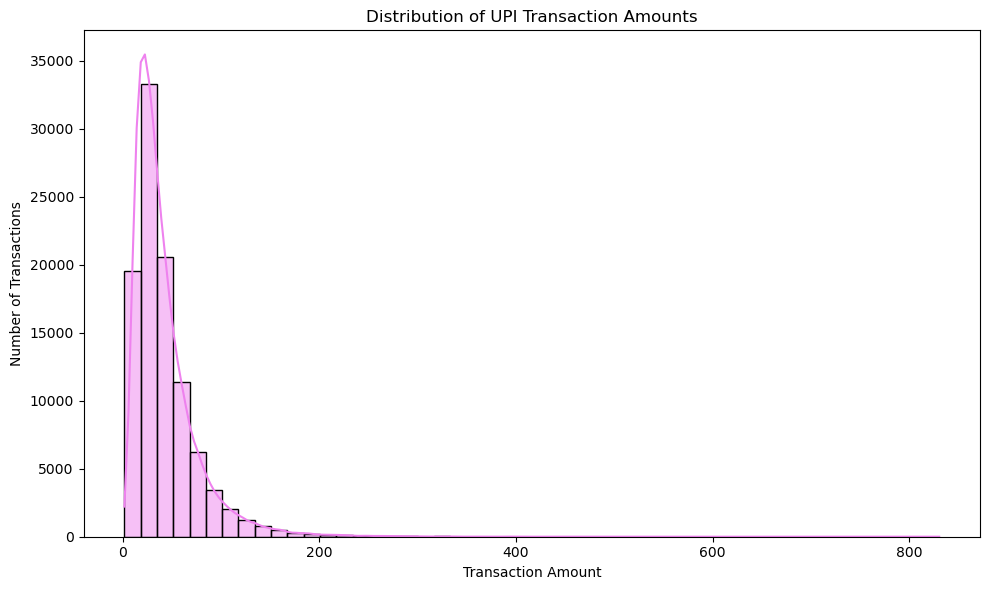

In [108]:
# TASK: Visualizing the distribution of transaction amounts to identify concentration, skewness, and potential extreme values.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(
    transactions_analysis["amount"],
    bins=50,
    kde=True,
    color='violet'
)

plt.title("Distribution of UPI Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

In [144]:
# TASK: Interpreting the transaction amount distribution and identifying concentration, skewness, and potential extreme-value behavior.

amount_series = transactions_analysis["amount"].dropna()

mean_amount = amount_series.mean()
median_amount = amount_series.median()
min_amount = amount_series.min()
max_amount = amount_series.max()
std_amount = amount_series.std()
skewness_amount = amount_series.skew()

print("=" * 80)
print("TRANSACTION AMOUNT DISTRIBUTION — BUSINESS ANALYSIS")
print("=" * 80)

print(
    f"""
1. CENTRAL TENDENCY
   Average transaction amount: ₹{mean_amount:,.2f}
   Median transaction amount:  ₹{median_amount:,.2f}

2. TRANSACTION RANGE
   Minimum transaction amount: ₹{min_amount:,.2f}
   Maximum transaction amount: ₹{max_amount:,.2f}

3. VARIABILITY
   Standard deviation: ₹{std_amount:,.2f}

4. DISTRIBUTION SHAPE
   Skewness: {skewness_amount:.4f}
"""
)

if skewness_amount > 0.5:
    print(
        "   Interpretation: The distribution is positively skewed, "
        "indicating that a relatively small number of higher-value "
        "transactions extend the upper tail."
    )
elif skewness_amount < -0.5:
    print(
        "   Interpretation: The distribution is negatively skewed, "
        "indicating a longer lower-value tail."
    )
else:
    print(
        "   Interpretation: The distribution is relatively balanced "
        "with limited skewness."
    )



print("=" * 80)

TRANSACTION AMOUNT DISTRIBUTION — BUSINESS ANALYSIS

1. CENTRAL TENDENCY
   Average transaction amount: ₹42.42
   Median transaction amount:  ₹33.09

2. TRANSACTION RANGE
   Minimum transaction amount: ₹1.62
   Maximum transaction amount: ₹830.46

3. VARIABILITY
   Standard deviation: ₹34.19

4. DISTRIBUTION SHAPE
   Skewness: 3.2281

   Interpretation: The distribution is positively skewed, indicating that a relatively small number of higher-value transactions extend the upper tail.


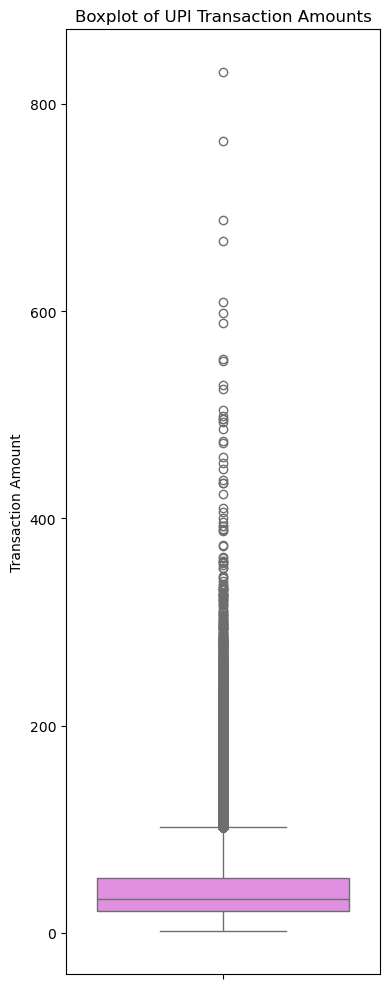

In [106]:
# TASK: Visualizing transaction-value outliers using a boxplot to identify extreme observations for later investigation.

plt.figure(figsize=(4,10))

sns.boxplot(
    y=transactions_analysis["amount"],color='violet'
)

plt.title("Boxplot of UPI Transaction Amounts")
plt.ylabel("Transaction Amount")
plt.tight_layout()
plt.show()

In [143]:
# TASK: Interpreting the transaction-value boxplot by quantifying quartiles, interquartile range, and potential high-value outliers.

amount_series = transactions_analysis["amount"].dropna()

q1 = amount_series.quantile(0.25)
q2 = amount_series.quantile(0.50)
q3 = amount_series.quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

outlier_count = (
    (amount_series < lower_bound) |
    (amount_series > upper_bound)
).sum()

outlier_percentage = (
    outlier_count / len(amount_series) * 100
)

print("=" * 80)
print("TRANSACTION VALUE BOXPLOT — BUSINESS ANALYSIS")
print("=" * 80)

print(f"""
1. QUARTILES
   Q1 (25th percentile): ₹{q1:,.2f}
   Median:               ₹{q2:,.2f}
   Q3 (75th percentile): ₹{q3:,.2f}

2. INTERQUARTILE RANGE
   IQR: ₹{iqr:,.2f}

3. OUTLIER THRESHOLDS
   Lower threshold: ₹{lower_bound:,.2f}
   Upper threshold: ₹{upper_bound:,.2f}

4. POTENTIAL OUTLIERS
   Number of potential outliers: {outlier_count:,}
   Percentage of transactions:   {outlier_percentage:.2f}%
""")



print("=" * 80)

TRANSACTION VALUE BOXPLOT — BUSINESS ANALYSIS

1. QUARTILES
   Q1 (25th percentile): ₹20.69
   Median:               ₹33.09
   Q3 (75th percentile): ₹53.17

2. INTERQUARTILE RANGE
   IQR: ₹32.48

3. OUTLIER THRESHOLDS
   Lower threshold: ₹-28.03
   Upper threshold: ₹101.89

4. POTENTIAL OUTLIERS
   Number of potential outliers: 5,457
   Percentage of transactions:   5.46%



In [101]:
# TASK: Analyzing transaction status distribution to quantify successful, failed, and pending 
#payment outcomes.

status_distribution = (
    transactions_analysis["status"]
    .value_counts()
    .rename_axis("status")
    .reset_index(name="transaction_count")
)

status_distribution["percentage"] = (
    status_distribution["transaction_count"]
    / len(transactions_analysis)
    * 100
)

print("=" * 70)
print("STEP 6.13 — TRANSACTION STATUS DISTRIBUTION")
print("=" * 70)

display(status_distribution)

STEP 6.13 — TRANSACTION STATUS DISTRIBUTION


,status,transaction_count,percentage
0,success,92140,92.140
1,failed,5871,5.871
2,pending,1989,1.989


In [145]:
# TASK: Interpreting transaction outcomes by comparing success, failure, and pending rates and identifying the main operational outcome.

status_summary = status_distribution.copy()

status_summary["percentage"] = (
    status_summary["transaction_count"]
    / status_summary["transaction_count"].sum()
    * 100
)

highest_status = status_summary.loc[
    status_summary["transaction_count"].idxmax()
]

failed_row = status_summary[
    status_summary["status"].astype(str).str.lower() == "failed"
]

pending_row = status_summary[
    status_summary["status"].astype(str).str.lower() == "pending"
]

failed_pct = (
    failed_row["percentage"].iloc[0]
    if not failed_row.empty else 0
)

pending_pct = (
    pending_row["percentage"].iloc[0]
    if not pending_row.empty else 0
)

print("=" * 80)
print("TRANSACTION STATUS — BUSINESS ANALYSIS")
print("=" * 80)

print(
    f"""
1. DOMINANT TRANSACTION OUTCOME
   {highest_status["status"]} is the most common transaction status,
   representing {highest_status["transaction_count"]:,} transactions
   ({highest_status["percentage"]:.2f}%).

2. FAILURE RATE
   Failed transactions represent {failed_pct:.2f}% of all transactions.

3. PENDING RATE
   Pending transactions represent {pending_pct:.2f}% of all transactions.

4. BUSINESS INTERPRETATION
   Transaction-status composition provides a high-level view of
   platform reliability and payment completion performance.

5. OPERATIONAL IMPLICATION
   The failure and pending populations provide the basis for deeper
   root-cause analysis by channel, device type, transaction type,
   merchant, and region.

6. FRAUD/RISK IMPLICATION
   Failed or pending transactions are not automatically fraudulent;
   their relationship with fraud indicators must be assessed separately.
"""
)

print("=" * 80)

TRANSACTION STATUS — BUSINESS ANALYSIS

1. DOMINANT TRANSACTION OUTCOME
   success is the most common transaction status,
   representing 92,140 transactions
   (92.14%).

2. FAILURE RATE
   Failed transactions represent 5.87% of all transactions.

3. PENDING RATE
   Pending transactions represent 1.99% of all transactions.

4. BUSINESS INTERPRETATION
   Transaction-status composition provides a high-level view of
   platform reliability and payment completion performance.

5. OPERATIONAL IMPLICATION
   The failure and pending populations provide the basis for deeper
   root-cause analysis by channel, device type, transaction type,
   merchant, and region.

6. FRAUD/RISK IMPLICATION
   Failed or pending transactions are not automatically fraudulent;
   their relationship with fraud indicators must be assessed separately.



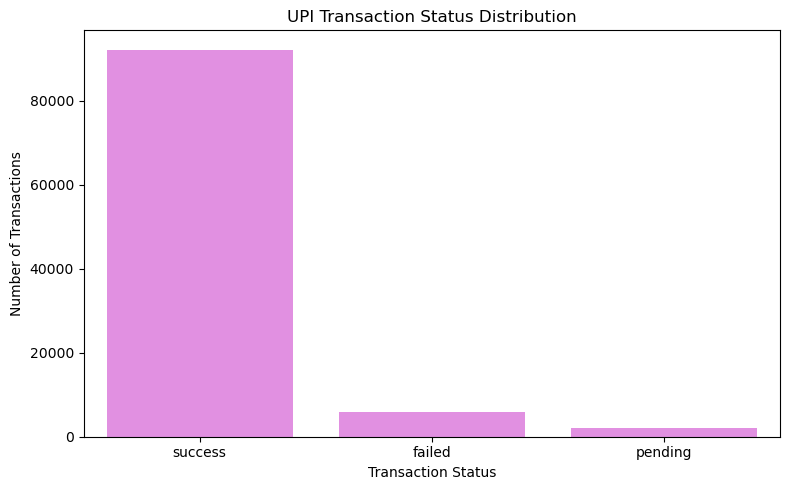

In [105]:
# TASK: Visualizing the distribution of successful, failed, and pending UPI transactions.

plt.figure(figsize=(8, 5))

sns.barplot(
    data=status_distribution,
    x="status",
    y="transaction_count",
    color="violet"
)

plt.title("UPI Transaction Status Distribution")
plt.xlabel("Transaction Status")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

In [147]:
# TASK: Interpreting transaction outcomes by comparing success, failure, and pending rates and identifying the main operational outcome.

status_summary = status_distribution.copy()

status_summary["percentage"] = (
    status_summary["transaction_count"]
    / status_summary["transaction_count"].sum()
    * 100
)

highest_status = status_summary.loc[
    status_summary["transaction_count"].idxmax()
]

failed_row = status_summary[
    status_summary["status"].astype(str).str.lower() == "failed"
]

pending_row = status_summary[
    status_summary["status"].astype(str).str.lower() == "pending"
]

failed_pct = (
    failed_row["percentage"].iloc[0]
    if not failed_row.empty else 0
)

pending_pct = (
    pending_row["percentage"].iloc[0]
    if not pending_row.empty else 0
)

print("=" * 80)
print("TRANSACTION STATUS — BUSINESS ANALYSIS")
print("=" * 80)

print(
    f"""
1. DOMINANT TRANSACTION OUTCOME
   {highest_status["status"]} is the most common transaction status,
   representing {highest_status["transaction_count"]:,} transactions
   ({highest_status["percentage"]:.2f}%).

2. FAILURE RATE
   Failed transactions represent {failed_pct:.2f}% of all transactions.

3. PENDING RATE
   Pending transactions represent {pending_pct:.2f}% of all transactions.

4. BUSINESS INTERPRETATION
   Transaction-status composition provides a high-level view of
   platform reliability and payment completion performance.

5. OPERATIONAL IMPLICATION
   The failure and pending populations provide the basis for deeper
   root-cause analysis by channel, device type, transaction type,
   merchant, and region.

6. FRAUD/RISK IMPLICATION
   Failed or pending transactions are not automatically fraudulent;
   their relationship with fraud indicators must be assessed separately.
"""
)

print("=" * 80)

TRANSACTION STATUS — BUSINESS ANALYSIS

1. DOMINANT TRANSACTION OUTCOME
   success is the most common transaction status,
   representing 92,140 transactions
   (92.14%).

2. FAILURE RATE
   Failed transactions represent 5.87% of all transactions.

3. PENDING RATE
   Pending transactions represent 1.99% of all transactions.

4. BUSINESS INTERPRETATION
   Transaction-status composition provides a high-level view of
   platform reliability and payment completion performance.

5. OPERATIONAL IMPLICATION
   The failure and pending populations provide the basis for deeper
   root-cause analysis by channel, device type, transaction type,
   merchant, and region.

6. FRAUD/RISK IMPLICATION
   Failed or pending transactions are not automatically fraudulent;
   their relationship with fraud indicators must be assessed separately.



In [109]:
# TASK: Analyzing transaction-type volume and value to understand how customers use the UPI platform.

transaction_type_analysis = (
    transactions_analysis
    .groupby("transaction_type")
    .agg(
        transaction_count=("transaction_id", "count"),
        total_transaction_value=("amount", "sum"),
        average_transaction_value=("amount", "mean"),
        fraud_transaction_count=("fraud_flag", "sum")
    )
    .reset_index()
)

transaction_type_analysis["transaction_percentage"] = (
    transaction_type_analysis["transaction_count"]
    / len(transactions_analysis)
    * 100
)

transaction_type_analysis["fraud_rate"] = (
    transaction_type_analysis["fraud_transaction_count"]
    / transaction_type_analysis["transaction_count"]
)

print("=" * 70)
print("STEP 6.14 — TRANSACTION TYPE ANALYSIS")
print("=" * 70)

display(
    transaction_type_analysis.sort_values(
        "transaction_count",
        ascending=False
    )
)

STEP 6.14 — TRANSACTION TYPE ANALYSIS


,transaction_type,transaction_count,total_transaction_value,average_transaction_value,fraud_transaction_count,transaction_percentage,fraud_rate
3,send,35032,1481965.60,42.303197,694,35.032,0.019810
2,receive,34819,1479684.96,42.496481,685,34.819,0.019673
1,merchant_payment,25097,1063889.81,42.391115,518,25.097,0.020640
0,bill_pay,5052,216233.89,42.801641,103,5.052,0.020388


In [146]:
# TASK: Interpreting transaction-type behavior by comparing transaction volume, transaction value, average value, and fraud rate.

type_analysis = transaction_type_analysis.copy()

highest_volume_type = type_analysis.loc[
    type_analysis["transaction_count"].idxmax()
]

highest_value_type = type_analysis.loc[
    type_analysis["total_transaction_value"].idxmax()
]

highest_average_type = type_analysis.loc[
    type_analysis["average_transaction_value"].idxmax()
]

highest_fraud_type = type_analysis.loc[
    type_analysis["fraud_rate"].idxmax()
]

print("=" * 80)
print("TRANSACTION TYPE — BUSINESS ANALYSIS")
print("=" * 80)

print(
    f"""
1. HIGHEST TRANSACTION VOLUME
   {highest_volume_type["transaction_type"]} records the highest
   transaction volume with {highest_volume_type["transaction_count"]:,}
   transactions.

2. HIGHEST TOTAL TRANSACTION VALUE
   {highest_value_type["transaction_type"]} contributes the highest
   total transaction value of ₹{highest_value_type["total_transaction_value"]:,.2f}.

3. HIGHEST AVERAGE TRANSACTION VALUE
   {highest_average_type["transaction_type"]} has the highest
   average transaction value of ₹{highest_average_type["average_transaction_value"]:,.2f}.

4. HIGHEST FRAUD RATE
   {highest_fraud_type["transaction_type"]} records the highest
   fraud rate at {highest_fraud_type["fraud_rate"] * 100:.4f}%.

5. BUSINESS INTERPRETATION
   Transaction volume, transaction value, and fraud exposure do not
   necessarily concentrate in the same transaction type.

6. RISK-MANAGEMENT IMPLICATION
   Transaction types with elevated fraud rates deserve further
   investigation alongside transaction volume and monetary exposure.
"""
)

print("=" * 80)

TRANSACTION TYPE — BUSINESS ANALYSIS

1. HIGHEST TRANSACTION VOLUME
   send records the highest
   transaction volume with 35,032
   transactions.

2. HIGHEST TOTAL TRANSACTION VALUE
   send contributes the highest
   total transaction value of ₹1,481,965.60.

3. HIGHEST AVERAGE TRANSACTION VALUE
   bill_pay has the highest
   average transaction value of ₹42.80.

4. HIGHEST FRAUD RATE
   merchant_payment records the highest
   fraud rate at 2.0640%.

5. BUSINESS INTERPRETATION
   Transaction volume, transaction value, and fraud exposure do not
   necessarily concentrate in the same transaction type.

6. RISK-MANAGEMENT IMPLICATION
   Transaction types with elevated fraud rates deserve further
   investigation alongside transaction volume and monetary exposure.



In [110]:
# TASK: Creating regional transaction-volume, transaction-value, failure, fraud, and reversal metrics for regional performance analysis.

# Joining customer region information to each transaction
transaction_region = transactions_analysis.merge(
    customers_analysis[
        ["customer_id", "region"]
    ],
    on="customer_id",
    how="left",
    suffixes=("", "_customer")
)

regional_transaction_analysis = (
    transaction_region
    .groupby("region")
    .agg(
        transaction_count=("transaction_id", "count"),
        total_transaction_value=("amount", "sum"),
        average_transaction_value=("amount", "mean"),
        fraud_transaction_count=("fraud_flag", "sum"),
        failed_transaction_count=(
            "status",
            lambda x: (x == "failed").sum()
        ),
        pending_transaction_count=(
            "status",
            lambda x: (x == "pending").sum()
        ),
        reversal_count=("reversal_flag", "sum")
    )
    .reset_index()
)

# Creating regional rates
regional_transaction_analysis["transaction_share"] = (
    regional_transaction_analysis["transaction_count"]
    / regional_transaction_analysis["transaction_count"].sum()
    * 100
)

regional_transaction_analysis["fraud_rate"] = (
    regional_transaction_analysis["fraud_transaction_count"]
    / regional_transaction_analysis["transaction_count"]
)

regional_transaction_analysis["failure_rate"] = (
    regional_transaction_analysis["failed_transaction_count"]
    / regional_transaction_analysis["transaction_count"]
)

regional_transaction_analysis["reversal_rate"] = (
    regional_transaction_analysis["reversal_count"]
    / regional_transaction_analysis["transaction_count"]
)

print("=" * 70)
print("STEP 6.15 — REGIONAL TRANSACTION PERFORMANCE")
print("=" * 70)

display(
    regional_transaction_analysis.sort_values(
        "transaction_count",
        ascending=False
    )
)

STEP 6.15 — REGIONAL TRANSACTION PERFORMANCE


,region,transaction_count,total_transaction_value,average_transaction_value,fraud_transaction_count,failed_transaction_count,pending_transaction_count,reversal_count,transaction_share,fraud_rate,failure_rate,reversal_rate
2,north,20787,877485.87,42.213204,404,1250,410,325,20.787,0.019435,0.060134,0.015635
4,west,20086,850305.20,42.333227,419,1202,368,310,20.086,0.020860,0.059843,0.015434
1,east,20078,853872.10,42.527747,402,1177,390,278,20.078,0.020022,0.058621,0.013846
0,central,19677,836040.20,42.488194,382,1122,409,267,19.677,0.019414,0.057021,0.013569
3,south,19372,824070.89,42.539278,393,1120,412,271,19.372,0.020287,0.057815,0.013989


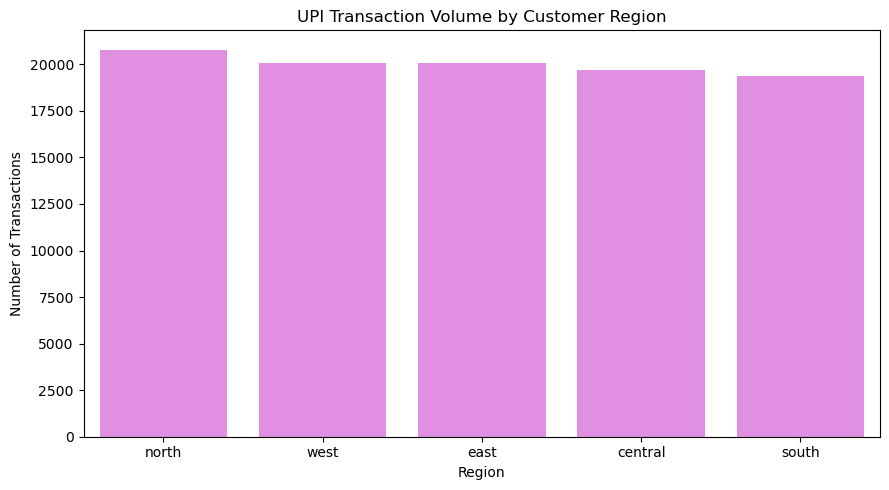

In [112]:
# TASK: Visualizing transaction volume by region to identify the highest-activity customer regions.

plt.figure(figsize=(9, 5))

sns.barplot(
    data=regional_transaction_analysis.sort_values(
        "transaction_count",
        ascending=False
    ),
    x="region",
    y="transaction_count",
    color='violet'
)

plt.title("UPI Transaction Volume by Customer Region")
plt.xlabel("Region")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

In [148]:
# TASK: Interpreting regional transaction volume and identifying the regions with the greatest payment activity.

highest_volume_region = regional_transaction_analysis.loc[
    regional_transaction_analysis["transaction_count"].idxmax()
]

lowest_volume_region = regional_transaction_analysis.loc[
    regional_transaction_analysis["transaction_count"].idxmin()
]

volume_difference = (
    highest_volume_region["transaction_count"]
    - lowest_volume_region["transaction_count"]
)

print("=" * 80)
print("REGIONAL TRANSACTION VOLUME — BUSINESS ANALYSIS")
print("=" * 80)

print(f"""
1. HIGHEST-ACTIVITY REGION
   {highest_volume_region["region"]} records the highest transaction volume
   with {highest_volume_region["transaction_count"]:,} transactions.

2. LOWEST-ACTIVITY REGION
   {lowest_volume_region["region"]} records the lowest transaction volume
   with {lowest_volume_region["transaction_count"]:,} transactions.

3. VOLUME DIFFERENCE
   The difference between the highest- and lowest-activity regions is
   {volume_difference:,} transactions.

4. TRANSACTION SHARE
   {highest_volume_region["region"]} accounts for
   {highest_volume_region["transaction_share"]:.2f}% of total transactions.

5. BUSINESS INTERPRETATION
   Regional transaction volume identifies where the platform experiences
   the greatest customer payment activity.

6. OPERATIONAL IMPLICATION
   High-volume regions represent important operational priorities because
   disruptions, failures, or fraud in these regions can affect a larger
   transaction population.
""")

print("=" * 80)

REGIONAL TRANSACTION VOLUME — BUSINESS ANALYSIS

1. HIGHEST-ACTIVITY REGION
   north records the highest transaction volume
   with 20,787 transactions.

2. LOWEST-ACTIVITY REGION
   south records the lowest transaction volume
   with 19,372 transactions.

3. VOLUME DIFFERENCE
   The difference between the highest- and lowest-activity regions is
   1,415 transactions.

4. TRANSACTION SHARE
   north accounts for
   20.79% of total transactions.

5. BUSINESS INTERPRETATION
   Regional transaction volume identifies where the platform experiences
   the greatest customer payment activity.

6. OPERATIONAL IMPLICATION
   High-volume regions represent important operational priorities because
   disruptions, failures, or fraud in these regions can affect a larger
   transaction population.



In [115]:
# TASK: Comparing regional fraud and failure rates to identify regions with elevated operational and security risk.

regional_risk_analysis = (
    regional_transaction_analysis[
        [
            "region",
            "transaction_count",
            "fraud_rate",
            "failure_rate",
            "reversal_rate"
        ]
    ]
    .sort_values(
        "fraud_rate",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("STEP 6.16 — REGIONAL FRAUD AND FAILURE ANALYSIS")
print("=" * 70)

display(regional_risk_analysis)

STEP 6.16 — REGIONAL FRAUD AND FAILURE ANALYSIS


,region,transaction_count,fraud_rate,failure_rate,reversal_rate
0,west,20086,0.020860,0.059843,0.015434
1,south,19372,0.020287,0.057815,0.013989
2,east,20078,0.020022,0.058621,0.013846
3,north,20787,0.019435,0.060134,0.015635
4,central,19677,0.019414,0.057021,0.013569


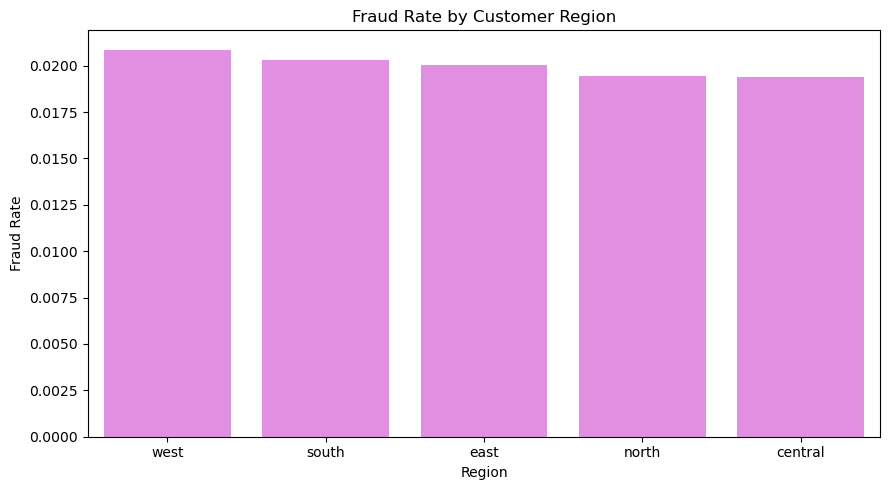

In [117]:
# TASK: Visualizing fraud rates across regions to highlight regional differences in transaction risk.

plt.figure(figsize=(9, 5))

sns.barplot(
    data=regional_risk_analysis,
    x="region",
    y="fraud_rate",
    color='violet'
)

plt.title("Fraud Rate by Customer Region")
plt.xlabel("Region")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

In [152]:
# TASK: Interpreting regional fraud, failure, and reversal rates to identify regions requiring closer risk or operational attention.

highest_fraud_region = regional_transaction_analysis.loc[
    regional_transaction_analysis["fraud_rate"].idxmax()
]

lowest_fraud_region = regional_transaction_analysis.loc[
    regional_transaction_analysis["fraud_rate"].idxmin()
]

highest_failure_region = regional_transaction_analysis.loc[
    regional_transaction_analysis["failure_rate"].idxmax()
]

print("=" * 80)
print("REGIONAL FRAUD AND FAILURE — BUSINESS ANALYSIS")
print("=" * 80)

print(f"""
1. HIGHEST FRAUD-RATE REGION
   {highest_fraud_region["region"]} records the highest fraud rate at
   {highest_fraud_region["fraud_rate"] * 100:.4f}%.

2. LOWEST FRAUD-RATE REGION
   {lowest_fraud_region["region"]} records the lowest fraud rate at
   {lowest_fraud_region["fraud_rate"] * 100:.4f}%.

3. FRAUD-RATE DIFFERENCE
   The difference between the highest and lowest regional fraud rates is
   {(highest_fraud_region["fraud_rate"] - lowest_fraud_region["fraud_rate"]) * 100:.4f}
   percentage points.

4. HIGHEST FAILURE-RATE REGION
   {highest_failure_region["region"]} records the highest failure rate at
   {highest_failure_region["failure_rate"] * 100:.4f}%.

5. BUSINESS INTERPRETATION
   Regional performance should be evaluated using both transaction volume
   and risk rates. A region with high fraud exposure and high transaction
   activity can represent a greater business priority than a low-volume
   region with a similar rate.

6. INVESTIGATION IMPLICATION
   The highest-risk regions should be examined further by channel,
   device type, transaction type, and merchant activity to determine
   potential underlying drivers.

7. ANALYTICAL CAUTION
   Regional differences describe observed associations. They do not by
   themselves establish the cause of regional fraud or failure differences.
""")

print("=" * 80)

REGIONAL FRAUD AND FAILURE — BUSINESS ANALYSIS

1. HIGHEST FRAUD-RATE REGION
   west records the highest fraud rate at
   2.0860%.

2. LOWEST FRAUD-RATE REGION
   central records the lowest fraud rate at
   1.9414%.

3. FRAUD-RATE DIFFERENCE
   The difference between the highest and lowest regional fraud rates is
   0.1447
   percentage points.

4. HIGHEST FAILURE-RATE REGION
   north records the highest failure rate at
   6.0134%.

5. BUSINESS INTERPRETATION
   Regional performance should be evaluated using both transaction volume
   and risk rates. A region with high fraud exposure and high transaction
   activity can represent a greater business priority than a low-volume
   region with a similar rate.

6. INVESTIGATION IMPLICATION
   The highest-risk regions should be examined further by channel,
   device type, transaction type, and merchant activity to determine
   potential underlying drivers.

7. ANALYTICAL CAUTION
   Regional differences describe observed associations. They do

In [118]:
# TASK: Checking and installing Plotly so the notebook can display interactive 3D analytical visualizations.

!pip install plotly -q

print("Plotly is installed and ready for interactive visualization.")

Plotly is installed and ready for interactive visualization.


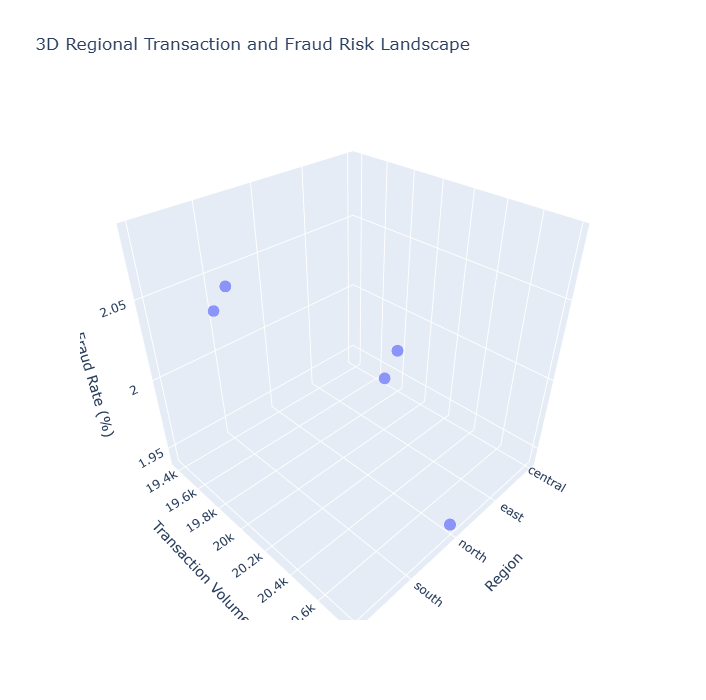

In [121]:
# TASK: Creating an interactive 3D regional transaction-risk landscape using transaction volume, transaction value, and fraud rate.

import plotly.express as px

regional_3d = regional_transaction_analysis.copy()

# Converting fraud rate to percentage points
regional_3d["fraud_rate_pct"] = (
    regional_3d["fraud_rate"] * 100
)

fig = px.scatter_3d(
    regional_3d,
    x="region",
    y="transaction_count",
    z="fraud_rate_pct",
    size="total_transaction_value",
    hover_name="region",
    hover_data={
        "transaction_count": True,
        "total_transaction_value": True,
        "fraud_rate_pct": ":.2f",
        "failure_rate": ":.4f"
    },
    title="3D Regional Transaction and Fraud Risk Landscape",
    labels={
        "region": "Region",
        "transaction_count": "Transaction Volume",
        "fraud_rate_pct": "Fraud Rate (%)",
        "total_transaction_value": "Transaction Value"
    }
)

fig.update_layout(
    height=700
)

fig.show()

In [122]:
# TASK: Ranking regions by fraud rate and transaction activity to identify priority areas for risk investigation.

regional_priority = regional_transaction_analysis.copy()

regional_priority["fraud_rate_pct"] = (
    regional_priority["fraud_rate"] * 100
)

regional_priority["failure_rate_pct"] = (
    regional_priority["failure_rate"] * 100
)

regional_priority["transaction_share_pct"] = (
    regional_priority["transaction_share"]
)

regional_priority = regional_priority[
    [
        "region",
        "transaction_count",
        "transaction_share_pct",
        "total_transaction_value",
        "fraud_transaction_count",
        "fraud_rate_pct",
        "failed_transaction_count",
        "failure_rate_pct",
        "reversal_count"
    ]
].sort_values(
    [
        "fraud_rate_pct",
        "transaction_count"
    ],
    ascending=[False, False]
).reset_index(drop=True)

print("=" * 70)
print("STEP 6.17 — REGIONAL PRIORITY RANKING")
print("=" * 70)

display(regional_priority)

STEP 6.17 — REGIONAL PRIORITY RANKING


,region,transaction_count,transaction_share_pct,total_transaction_value,fraud_transaction_count,fraud_rate_pct,failed_transaction_count,failure_rate_pct,reversal_count
0,west,20086,20.086,850305.20,419,2.086030,1202,5.984268,310
1,south,19372,19.372,824070.89,393,2.028701,1120,5.781540,271
2,east,20078,20.078,853872.10,402,2.002191,1177,5.862138,278
3,north,20787,20.787,877485.87,404,1.943522,1250,6.013374,325
4,central,19677,19.677,836040.20,382,1.941353,1122,5.702089,267


In [153]:
# TASK: Interpreting the 3D regional transaction-risk landscape by combining transaction volume, transaction value, and fraud rate.

regional_3d_analysis = regional_transaction_analysis.copy()

regional_3d_analysis["fraud_rate_pct"] = (
    regional_3d_analysis["fraud_rate"] * 100
)

# Identifying leaders across the three dimensions
highest_volume = regional_3d_analysis.loc[
    regional_3d_analysis["transaction_count"].idxmax()
]

highest_value = regional_3d_analysis.loc[
    regional_3d_analysis["total_transaction_value"].idxmax()
]

highest_fraud = regional_3d_analysis.loc[
    regional_3d_analysis["fraud_rate_pct"].idxmax()
]

# Identifying a region that combines high volume and high fraud rate
volume_median = regional_3d_analysis["transaction_count"].median()
fraud_median = regional_3d_analysis["fraud_rate_pct"].median()

high_exposure_regions = regional_3d_analysis[
    (regional_3d_analysis["transaction_count"] >= volume_median) &
    (regional_3d_analysis["fraud_rate_pct"] >= fraud_median)
].copy()

print("=" * 80)
print("3D REGIONAL TRANSACTION AND FRAUD RISK — BUSINESS ANALYSIS")
print("=" * 80)

print(f"""
1. HIGHEST TRANSACTION VOLUME
   {highest_volume["region"]} records the highest transaction volume:
   {highest_volume["transaction_count"]:,} transactions.

2. HIGHEST TRANSACTION VALUE
   {highest_value["region"]} records the highest total transaction value:
   ₹{highest_value["total_transaction_value"]:,.2f}.

3. HIGHEST FRAUD RATE
   {highest_fraud["region"]} records the highest fraud rate:
   {highest_fraud["fraud_rate_pct"]:.4f}%.

4. HIGH-EXPOSURE REGIONS
   {len(high_exposure_regions)} region(s) are at or above the median
   for both transaction volume and fraud rate.

5. BUSINESS INTERPRETATION
   The 3D visualization combines activity and risk into one view.
   This helps distinguish regions that are merely high-volume from
   regions that combine substantial transaction activity with elevated
   fraud exposure.

6. RISK-MANAGEMENT IMPLICATION
   Regions that are simultaneously high in transaction activity and
   fraud rate represent priority areas for deeper investigation.

7. ANALYTICAL CAUTION
   The 3D landscape is an analytical regional visualization rather than
   a geographic map because the source data contains categorical regions
   rather than latitude/longitude coordinates.
""")

if len(high_exposure_regions) > 0:
    print("\nHigh-exposure regions:")
    display(
        high_exposure_regions[
            [
                "region",
                "transaction_count",
                "total_transaction_value",
                "fraud_rate_pct",
                "failure_rate"
            ]
        ].sort_values(
            "fraud_rate_pct",
            ascending=False
        )
    )

print("=" * 80)

3D REGIONAL TRANSACTION AND FRAUD RISK — BUSINESS ANALYSIS

1. HIGHEST TRANSACTION VOLUME
   north records the highest transaction volume:
   20,787 transactions.

2. HIGHEST TRANSACTION VALUE
   north records the highest total transaction value:
   ₹877,485.87.

3. HIGHEST FRAUD RATE
   west records the highest fraud rate:
   2.0860%.

4. HIGH-EXPOSURE REGIONS
   2 region(s) are at or above the median
   for both transaction volume and fraud rate.

5. BUSINESS INTERPRETATION
   The 3D visualization combines activity and risk into one view.
   This helps distinguish regions that are merely high-volume from
   regions that combine substantial transaction activity with elevated
   fraud exposure.

6. RISK-MANAGEMENT IMPLICATION
   Regions that are simultaneously high in transaction activity and
   fraud rate represent priority areas for deeper investigation.

7. ANALYTICAL CAUTION
   The 3D landscape is an analytical regional visualization rather than
   a geographic map because the sour

,region,transaction_count,total_transaction_value,fraud_rate_pct,failure_rate
4,west,20086,850305.2,2.086030,0.059843
1,east,20078,853872.1,2.002191,0.058621


In [123]:
# TASK: Creating device-type transaction, value, failure, fraud, and reversal metrics for device performance analysis.

device_type_analysis = (
    transactions_analysis
    .groupby("device_type")
    .agg(
        transaction_count=("transaction_id", "count"),
        total_transaction_value=("amount", "sum"),
        average_transaction_value=("amount", "mean"),
        fraud_transaction_count=("fraud_flag", "sum"),
        failed_transaction_count=(
            "status",
            lambda x: (x == "failed").sum()
        ),
        pending_transaction_count=(
            "status",
            lambda x: (x == "pending").sum()
        ),
        reversal_count=("reversal_flag", "sum")
    )
    .reset_index()
)

# Creating device-type rates
device_type_analysis["transaction_share"] = (
    device_type_analysis["transaction_count"]
    / device_type_analysis["transaction_count"].sum()
    * 100
)

device_type_analysis["fraud_rate"] = (
    device_type_analysis["fraud_transaction_count"]
    / device_type_analysis["transaction_count"]
)

device_type_analysis["failure_rate"] = (
    device_type_analysis["failed_transaction_count"]
    / device_type_analysis["transaction_count"]
)

device_type_analysis["reversal_rate"] = (
    device_type_analysis["reversal_count"]
    / device_type_analysis["transaction_count"]
)

print("=" * 70)
print("STEP 6.18 — DEVICE TYPE PERFORMANCE ANALYSIS")
print("=" * 70)

display(
    device_type_analysis.sort_values(
        "transaction_count",
        ascending=False
    )
)

STEP 6.18 — DEVICE TYPE PERFORMANCE ANALYSIS


,device_type,transaction_count,total_transaction_value,average_transaction_value,fraud_transaction_count,failed_transaction_count,pending_transaction_count,reversal_count,transaction_share,fraud_rate,failure_rate,reversal_rate
1,feature_phone,25596,1080567.13,42.216250,551,1486,496,376,25.596,0.021527,0.058056,0.014690
0,android,25145,1065551.64,42.376283,501,1525,529,352,25.145,0.019924,0.060648,0.013999
2,ios,24783,1054322.60,42.542170,460,1461,474,368,24.783,0.018561,0.058952,0.014849
3,tablet,24476,1041332.89,42.545060,488,1399,490,355,24.476,0.019938,0.057158,0.014504


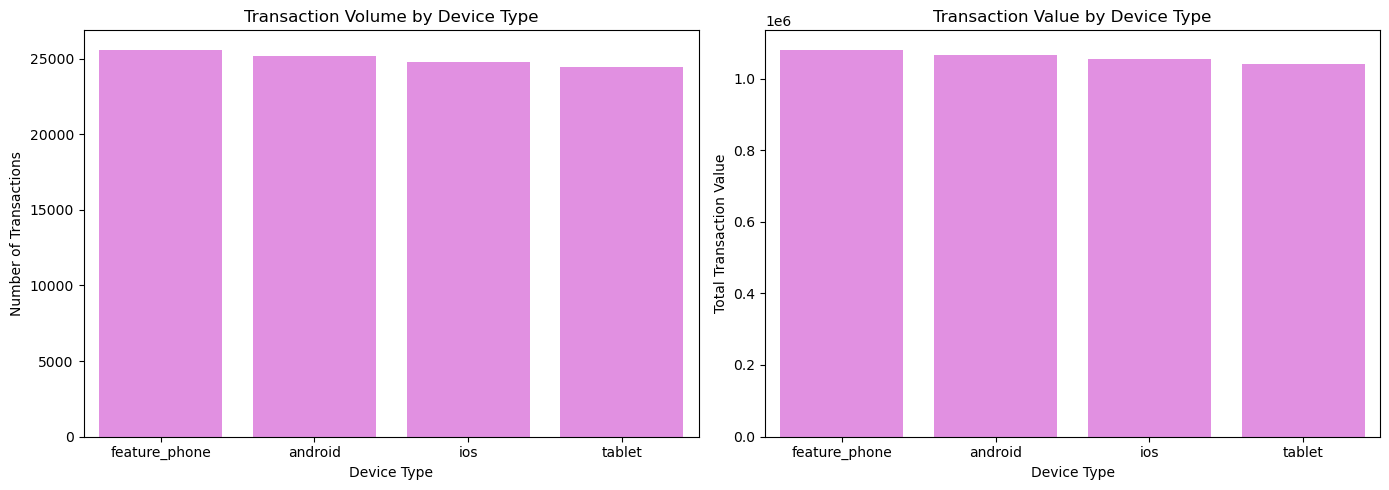

In [126]:
# TASK: Visualizing transaction volume and transaction value across device types.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=device_type_analysis.sort_values(
        "transaction_count",
        ascending=False
    ),
    x="device_type",
    y="transaction_count",
    color='violet',
    ax=axes[0]
)

axes[0].set_title("Transaction Volume by Device Type")
axes[0].set_xlabel("Device Type")
axes[0].set_ylabel("Number of Transactions")

sns.barplot(
    data=device_type_analysis.sort_values(
        "total_transaction_value",
        ascending=False
    ),
    x="device_type",
    y="total_transaction_value",
    color='violet',
    ax=axes[1]
)

axes[1].set_title("Transaction Value by Device Type")
axes[1].set_xlabel("Device Type")
axes[1].set_ylabel("Total Transaction Value")

plt.tight_layout()
plt.show()

In [155]:
# TASK: Interpreting device-type transaction activity and monetary exposure to identify the most operationally important device categories.

highest_device_volume = device_type_analysis.loc[
    device_type_analysis["transaction_count"].idxmax()
]

highest_device_value = device_type_analysis.loc[
    device_type_analysis["total_transaction_value"].idxmax()
]

highest_average_value = device_type_analysis.loc[
    device_type_analysis["average_transaction_value"].idxmax()
]

print("=" * 80)
print("DEVICE TYPE ACTIVITY — BUSINESS ANALYSIS")
print("=" * 80)

print(f"""
1. HIGHEST TRANSACTION VOLUME
   {highest_device_volume["device_type"]} handles the highest number of
   transactions: {highest_device_volume["transaction_count"]:,}.

2. HIGHEST TRANSACTION VALUE
   {highest_device_value["device_type"]} records the highest total
   transaction value: ₹{highest_device_value["total_transaction_value"]:,.2f}.

3. HIGHEST AVERAGE TRANSACTION VALUE
   {highest_average_value["device_type"]} records the highest average
   transaction amount: ₹{highest_average_value["average_transaction_value"]:,.2f}.

4. BUSINESS INTERPRETATION
   Device usage should be evaluated using both transaction frequency
   and monetary value because the most commonly used device category
   is not necessarily the category with the greatest monetary exposure.

5. OPERATIONAL IMPLICATION
   Device categories with high transaction activity or high monetary
   exposure become important populations for subsequent fraud and
   reliability analysis.
""")

print("=" * 80)

DEVICE TYPE ACTIVITY — BUSINESS ANALYSIS

1. HIGHEST TRANSACTION VOLUME
   feature_phone handles the highest number of
   transactions: 25,596.

2. HIGHEST TRANSACTION VALUE
   feature_phone records the highest total
   transaction value: ₹1,080,567.13.

3. HIGHEST AVERAGE TRANSACTION VALUE
   tablet records the highest average
   transaction amount: ₹42.55.

4. BUSINESS INTERPRETATION
   Device usage should be evaluated using both transaction frequency
   and monetary value because the most commonly used device category
   is not necessarily the category with the greatest monetary exposure.

5. OPERATIONAL IMPLICATION
   Device categories with high transaction activity or high monetary
   exposure become important populations for subsequent fraud and
   reliability analysis.



In [127]:
# TASK: Comparing fraud rates across device types to identify device categories with elevated transaction risk.

device_fraud_analysis = (
    device_type_analysis[
        [
            "device_type",
            "transaction_count",
            "fraud_transaction_count",
            "fraud_rate"
        ]
    ]
    .sort_values(
        "fraud_rate",
        ascending=False
    )
    .reset_index(drop=True)
)

device_fraud_analysis["fraud_rate_pct"] = (
    device_fraud_analysis["fraud_rate"] * 100
)

print("=" * 70)
print("STEP 6.19 — DEVICE TYPE FRAUD ANALYSIS")
print("=" * 70)

display(device_fraud_analysis)

STEP 6.19 — DEVICE TYPE FRAUD ANALYSIS


,device_type,transaction_count,fraud_transaction_count,fraud_rate,fraud_rate_pct
0,feature_phone,25596,551,0.021527,2.152680
1,tablet,24476,488,0.019938,1.993790
2,android,25145,501,0.019924,1.992444
3,ios,24783,460,0.018561,1.856111


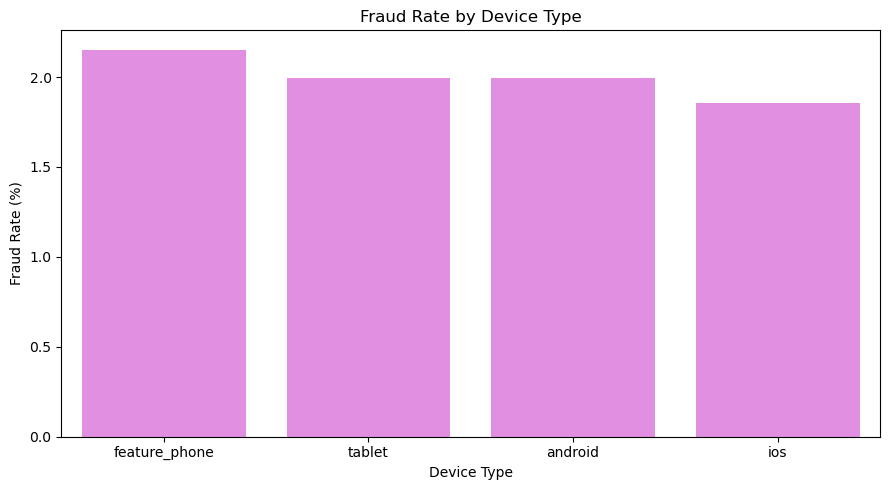

In [128]:
# TASK: Visualizing fraud rates across device types to identify higher-risk device categories.

plt.figure(figsize=(9, 5))

sns.barplot(
    data=device_fraud_analysis,
    x="device_type",
    y="fraud_rate_pct",
    color='violet',
)

plt.title("Fraud Rate by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()

In [156]:
# TASK: Interpreting fraud-rate differences across device types and identifying device categories with elevated observed risk.

highest_device_fraud = device_fraud_analysis.loc[
    device_fraud_analysis["fraud_rate"].idxmax()
]

lowest_device_fraud = device_fraud_analysis.loc[
    device_fraud_analysis["fraud_rate"].idxmin()
]

fraud_rate_difference = (
    highest_device_fraud["fraud_rate"]
    - lowest_device_fraud["fraud_rate"]
)

print("=" * 80)
print("DEVICE TYPE FRAUD — BUSINESS ANALYSIS")
print("=" * 80)

print(f"""
1. HIGHEST FRAUD-RATE DEVICE TYPE
   {highest_device_fraud["device_type"]} records the highest fraud rate
   at {highest_device_fraud["fraud_rate"] * 100:.4f}%.

2. LOWEST FRAUD-RATE DEVICE TYPE
   {lowest_device_fraud["device_type"]} records the lowest fraud rate
   at {lowest_device_fraud["fraud_rate"] * 100:.4f}%.

3. FRAUD-RATE DIFFERENCE
   The observed difference is
   {fraud_rate_difference * 100:.4f} percentage points.

4. BUSINESS INTERPRETATION
   Device-type differences can indicate that fraud exposure is not
   distributed uniformly across the platform's device ecosystem.

5. RISK-MANAGEMENT IMPLICATION
   Device categories with elevated fraud rates can be prioritized
   for deeper investigation using rooted status, transaction volume,
   transaction value, and channel behavior.
""")

print("=" * 80)

DEVICE TYPE FRAUD — BUSINESS ANALYSIS

1. HIGHEST FRAUD-RATE DEVICE TYPE
   feature_phone records the highest fraud rate
   at 2.1527%.

2. LOWEST FRAUD-RATE DEVICE TYPE
   ios records the lowest fraud rate
   at 1.8561%.

3. FRAUD-RATE DIFFERENCE
   The observed difference is
   0.2966 percentage points.

4. BUSINESS INTERPRETATION
   Device-type differences can indicate that fraud exposure is not
   distributed uniformly across the platform's device ecosystem.

5. RISK-MANAGEMENT IMPLICATION
   Device categories with elevated fraud rates can be prioritized
   for deeper investigation using rooted status, transaction volume,
   transaction value, and channel behavior.



In [130]:
# TASK: Inspecting the actual is_rooted values and data type imported from MySQL before standardizing rooted-device status.

print("=" * 70)
print("ROOTED STATUS DIAGNOSTIC")
print("=" * 70)

print("is_rooted dtype:")
print(devices_analysis["is_rooted"].dtype)

print("\nUnique is_rooted values:")
print(
    devices_analysis["is_rooted"]
    .value_counts(dropna=False)
)

print("\nSample is_rooted values:")
print(
    devices_analysis["is_rooted"]
    .head(10)
    .tolist()
)

print("=" * 70)

ROOTED STATUS DIAGNOSTIC
is_rooted dtype:
object

Unique is_rooted values:
is_rooted
False    11630
True       370
Name: count, dtype: int64

Sample is_rooted values:
['False', 'False', 'False', 'False', 'False', 'False', 'False', 'False', 'False', 'False']


In [131]:
# TASK: Standardizing rooted-device status from text values into consistent Boolean and readable categorical labels.

# Converting text values into actual Boolean values
devices_analysis["is_rooted_bool"] = (
    devices_analysis["is_rooted"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "true": True,
        "false": False
    })
)

# Checking whether every value was successfully converted
conversion_failures = (
    devices_analysis["is_rooted_bool"].isna().sum()
)

# Creating a readable rooted-status label
devices_analysis["root_status"] = (
    devices_analysis["is_rooted_bool"]
    .map({
        True: "Rooted",
        False: "Non-Rooted"
    })
)

print("=" * 70)
print("ROOTED DEVICE STATUS STANDARDIZATION")
print("=" * 70)

print("Original dtype:",
      devices_analysis["is_rooted"].dtype)

print("Standardized dtype:",
      devices_analysis["is_rooted_bool"].dtype)

print("\nRooted-status counts:")
print(
    devices_analysis["root_status"]
    .value_counts(dropna=False)
)

print("\nConversion failures:",
      conversion_failures)

if conversion_failures == 0:
    print("✅ All rooted-status values converted successfully.")
else:
    print("⚠️ Some rooted-status values could not be converted.")

print("=" * 70)

ROOTED DEVICE STATUS STANDARDIZATION
Original dtype: object
Standardized dtype: bool

Rooted-status counts:
root_status
Non-Rooted    11630
Rooted          370
Name: count, dtype: int64

Conversion failures: 0
✅ All rooted-status values converted successfully.


In [132]:
# TASK: Creating the corrected rooted-device transaction and fraud analysis using standardized rooted-status values.

rooted_device_analysis = (
    transactions_analysis
    .groupby("device_id")
    .agg(
        transaction_count=("transaction_id", "count"),
        total_transaction_value=("amount", "sum"),
        fraud_transaction_count=("fraud_flag", "sum"),
        failed_transaction_count=(
            "status",
            lambda x: (x == "failed").sum()
        ),
        reversal_count=("reversal_flag", "sum")
    )
    .reset_index()
)

# Adding standardized device attributes
rooted_device_analysis = rooted_device_analysis.merge(
    devices_analysis[
        [
            "device_id",
            "device_type",
            "is_rooted_bool",
            "root_status"
        ]
    ],
    on="device_id",
    how="left"
)

# Aggregating to rooted vs non-rooted level
rooted_summary = (
    rooted_device_analysis
    .groupby(
        ["is_rooted_bool", "root_status"],
        as_index=False
    )
    .agg(
        devices=("device_id", "count"),
        transactions=("transaction_count", "sum"),
        total_transaction_value=("total_transaction_value", "sum"),
        fraud_transactions=("fraud_transaction_count", "sum"),
        failed_transactions=("failed_transaction_count", "sum"),
        reversals=("reversal_count", "sum")
    )
)

# Creating analytical rates
rooted_summary["fraud_rate"] = (
    rooted_summary["fraud_transactions"]
    / rooted_summary["transactions"]
)

rooted_summary["failure_rate"] = (
    rooted_summary["failed_transactions"]
    / rooted_summary["transactions"]
)

rooted_summary["reversal_rate"] = (
    rooted_summary["reversals"]
    / rooted_summary["transactions"]
)

rooted_summary["fraud_rate_pct"] = (
    rooted_summary["fraud_rate"] * 100
)

rooted_summary["failure_rate_pct"] = (
    rooted_summary["failure_rate"] * 100
)

rooted_summary["reversal_rate_pct"] = (
    rooted_summary["reversal_rate"] * 100
)

# Sorting rooted status for readability
rooted_summary = rooted_summary.sort_values(
    "is_rooted_bool",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("STEP 6.20 — CORRECTED ROOTED DEVICE ANALYSIS")
print("=" * 70)

display(
    rooted_summary[
        [
            "root_status",
            "devices",
            "transactions",
            "total_transaction_value",
            "fraud_transactions",
            "failed_transactions",
            "reversals",
            "fraud_rate_pct",
            "failure_rate_pct",
            "reversal_rate_pct"
        ]
    ]
)

STEP 6.20 — CORRECTED ROOTED DEVICE ANALYSIS


,root_status,devices,transactions,total_transaction_value,fraud_transactions,failed_transactions,reversals,fraud_rate_pct,failure_rate_pct,reversal_rate_pct
0,Rooted,270,3171,132752.54,656,188,45,20.687480,5.928729,1.419111
1,Non-Rooted,8140,96829,4109021.72,1344,5683,1406,1.388014,5.869109,1.452044


In [133]:
# TASK: Comparing rooted and non-rooted fraud rates to determine whether the rooted-device hypothesis is supported descriptively.

rooted_rate = rooted_summary.loc[
    rooted_summary["is_rooted_bool"] == True,
    "fraud_rate"
].iloc[0]

non_rooted_rate = rooted_summary.loc[
    rooted_summary["is_rooted_bool"] == False,
    "fraud_rate"
].iloc[0]

rate_difference = rooted_rate - non_rooted_rate

relative_difference = (
    (rooted_rate / non_rooted_rate) - 1
    if non_rooted_rate > 0
    else np.nan
)

print("=" * 70)
print("ROOTED DEVICE FRAUD-RATE COMPARISON")
print("=" * 70)

print(f"Rooted device fraud rate:     {rooted_rate * 100:.4f}%")
print(f"Non-rooted device fraud rate: {non_rooted_rate * 100:.4f}%")
print(f"Absolute difference:           {rate_difference * 100:.4f} percentage points")

if not np.isnan(relative_difference):
    print(
        f"Relative difference:           "
        f"{relative_difference * 100:.2f}%"
    )

print()

if rooted_rate > non_rooted_rate:
    print("Descriptive finding: Rooted devices have a higher fraud rate.")
elif rooted_rate < non_rooted_rate:
    print("Descriptive finding: Non-rooted devices have a higher fraud rate.")
else:
    print("Descriptive finding: Both groups have the same fraud rate.")

print("=" * 70)

ROOTED DEVICE FRAUD-RATE COMPARISON
Rooted device fraud rate:     20.6875%
Non-rooted device fraud rate: 1.3880%
Absolute difference:           19.2995 percentage points
Relative difference:           1390.44%

Descriptive finding: Rooted devices have a higher fraud rate.


In [129]:
# TASK: Comparing transaction activity, value, failure, reversal, and fraud rates between rooted and non-rooted devices.

rooted_device_analysis = (
    transactions_analysis
    .groupby("device_id")
    .agg(
        transaction_count=("transaction_id", "count"),
        total_transaction_value=("amount", "sum"),
        fraud_transaction_count=("fraud_flag", "sum"),
        failed_transaction_count=(
            "status",
            lambda x: (x == "failed").sum()
        ),
        reversal_count=("reversal_flag", "sum")
    )
    .reset_index()
)

# Adding rooted status and device type
rooted_device_analysis = rooted_device_analysis.merge(
    devices_analysis[
        [
            "device_id",
            "device_type",
            "is_rooted"
        ]
    ],
    on="device_id",
    how="left"
)

# Aggregating to rooted vs non-rooted level
rooted_summary = (
    rooted_device_analysis
    .groupby("is_rooted")
    .agg(
        devices=("device_id", "count"),
        transactions=("transaction_count", "sum"),
        total_transaction_value=("total_transaction_value", "sum"),
        fraud_transactions=("fraud_transaction_count", "sum"),
        failed_transactions=("failed_transaction_count", "sum"),
        reversals=("reversal_count", "sum")
    )
    .reset_index()
)

# Creating rates
rooted_summary["fraud_rate"] = (
    rooted_summary["fraud_transactions"]
    / rooted_summary["transactions"]
)

rooted_summary["failure_rate"] = (
    rooted_summary["failed_transactions"]
    / rooted_summary["transactions"]
)

rooted_summary["reversal_rate"] = (
    rooted_summary["reversals"]
    / rooted_summary["transactions"]
)

# Creating readable labels
rooted_summary["root_status"] = (
    rooted_summary["is_rooted"]
    .map({
        True: "Rooted",
        False: "Non-Rooted"
    })
)

rooted_summary["fraud_rate_pct"] = (
    rooted_summary["fraud_rate"] * 100
)

rooted_summary["failure_rate_pct"] = (
    rooted_summary["failure_rate"] * 100
)

print("=" * 70)
print("STEP 6.20 — ROOTED DEVICE ANALYSIS")
print("=" * 70)

display(
    rooted_summary[
        [
            "root_status",
            "devices",
            "transactions",
            "total_transaction_value",
            "fraud_transactions",
            "failed_transactions",
            "reversals",
            "fraud_rate_pct",
            "failure_rate_pct",
            "reversal_rate"
        ]
    ]
)

STEP 6.20 — ROOTED DEVICE ANALYSIS


,root_status,devices,transactions,total_transaction_value,fraud_transactions,failed_transactions,reversals,fraud_rate_pct,failure_rate_pct,reversal_rate
0,NaN,8140,96829,4109021.72,1344,5683,1406,1.388014,5.869109,0.014520
1,NaN,270,3171,132752.54,656,188,45,20.687480,5.928729,0.014191


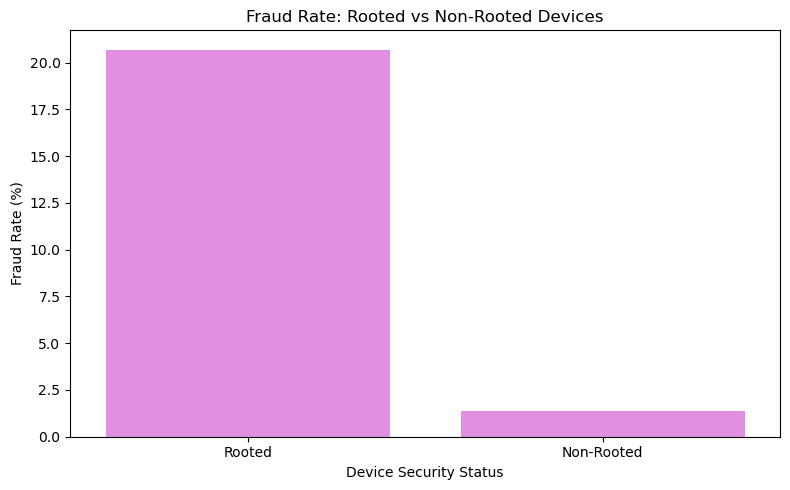

In [135]:
# TASK: Visualizing the fraud-rate difference between rooted and non-rooted devices after standardizing rooted-device status.

plt.figure(figsize=(8, 5))

sns.barplot(
    data=rooted_summary,
    x="root_status",
    y="fraud_rate_pct",
    color='violet',
)

plt.title("Fraud Rate: Rooted vs Non-Rooted Devices")
plt.xlabel("Device Security Status")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()

In [157]:
# TASK: Interpreting the rooted-device fraud finding and quantifying its observed risk difference.

rooted_row = rooted_summary[
    rooted_summary["is_rooted_bool"] == True
].iloc[0]

non_rooted_row = rooted_summary[
    rooted_summary["is_rooted_bool"] == False
].iloc[0]

print("=" * 80)
print("ROOTED DEVICE FRAUD — BUSINESS ANALYSIS")
print("=" * 80)

print(f"""
1. ROOTED DEVICE FRAUD RATE
   Rooted devices record a fraud rate of
   {rooted_row["fraud_rate_pct"]:.4f}%.

2. NON-ROOTED DEVICE FRAUD RATE
   Non-rooted devices record a fraud rate of
   {non_rooted_row["fraud_rate_pct"]:.4f}%.

3. ABSOLUTE DIFFERENCE
   The observed difference is
   {rooted_row["fraud_rate_pct"] - non_rooted_row["fraud_rate_pct"]:.4f}
   percentage points.

4. RELATIVE RISK
   The observed rooted-device fraud rate is approximately
   {rooted_row["fraud_rate"] / non_rooted_row["fraud_rate"]:.2f} times
   the non-rooted device fraud rate.

5. DESCRIPTIVE FINDING
   Rooted devices show a substantially higher observed fraud rate
   than non-rooted devices in this dataset.

6. BUSINESS IMPLICATION
   Rooted-device activity represents a potentially important risk
   segment for enhanced monitoring and device-security controls.

7. ANALYTICAL CAUTION
   This finding establishes an observed association, not causation.
   Formal statistical testing is required before treating the difference
   as statistically significant.
""")

print("=" * 80)

ROOTED DEVICE FRAUD — BUSINESS ANALYSIS

1. ROOTED DEVICE FRAUD RATE
   Rooted devices record a fraud rate of
   20.6875%.

2. NON-ROOTED DEVICE FRAUD RATE
   Non-rooted devices record a fraud rate of
   1.3880%.

3. ABSOLUTE DIFFERENCE
   The observed difference is
   19.2995
   percentage points.

4. RELATIVE RISK
   The observed rooted-device fraud rate is approximately
   14.90 times
   the non-rooted device fraud rate.

5. DESCRIPTIVE FINDING
   Rooted devices show a substantially higher observed fraud rate
   than non-rooted devices in this dataset.

6. BUSINESS IMPLICATION
   Rooted-device activity represents a potentially important risk
   segment for enhanced monitoring and device-security controls.

7. ANALYTICAL CAUTION
   This finding establishes an observed association, not causation.
   Formal statistical testing is required before treating the difference
   as statistically significant.



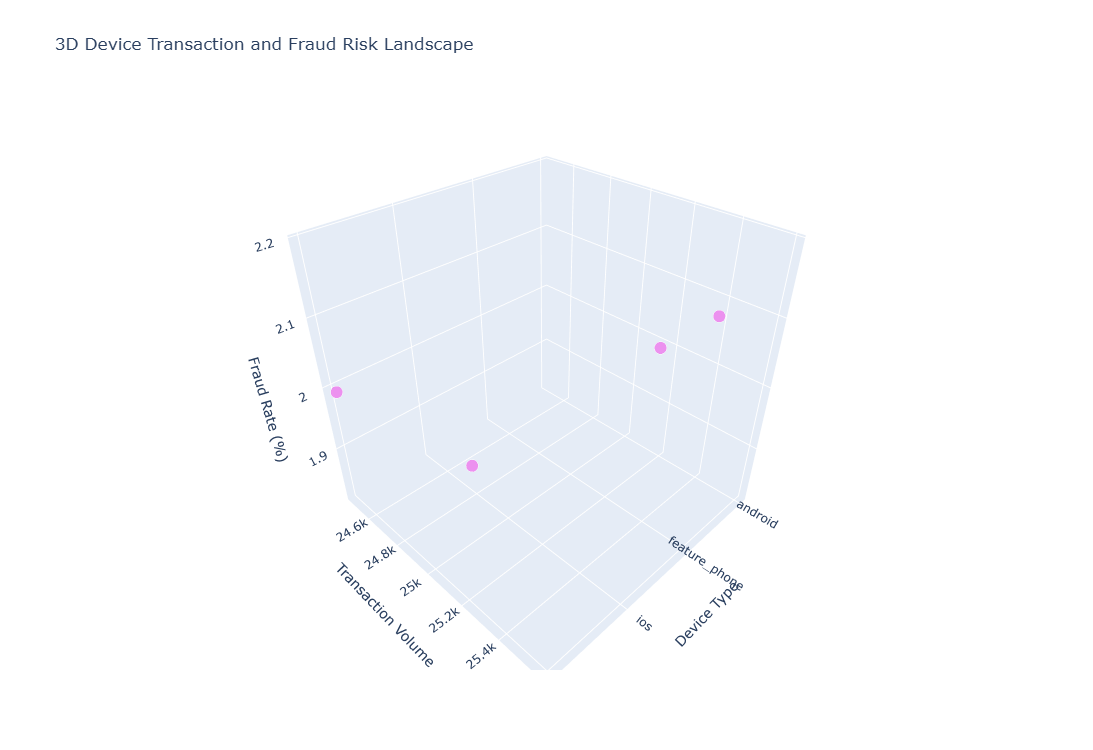

In [137]:
# TASK: Creating an interactive 3D device-risk landscape with a zoomed fraud-rate axis and violet markers.

device_3d = device_type_analysis.copy()

# Converting fraud rate to percentage points
device_3d["fraud_rate_pct"] = (
    device_3d["fraud_rate"] * 100
)

# Calculating the observed fraud-rate range
z_min = device_3d["fraud_rate_pct"].min()
z_max = device_3d["fraud_rate_pct"].max()

# Adding a small amount of padding so the markers are not touching the axis edges
z_padding = max((z_max - z_min) * 0.15, 0.05)

fig = px.scatter_3d(
    device_3d,
    x="device_type",
    y="transaction_count",
    z="fraud_rate_pct",
    size="total_transaction_value",
    hover_name="device_type",
    hover_data={
        "transaction_count": True,
        "total_transaction_value": ":.2f",
        "average_transaction_value": ":.2f",
        "fraud_transaction_count": True,
        "fraud_rate_pct": ":.4f",
        "failure_rate": ":.4f"
    },
    title="3D Device Transaction and Fraud Risk Landscape",
    labels={
        "device_type": "Device Type",
        "transaction_count": "Transaction Volume",
        "fraud_rate_pct": "Fraud Rate (%)"
    }
)

# Making all markers violet
fig.update_traces(
    marker=dict(
        color="violet",
        opacity=0.85
    )
)

# Zooming the fraud-rate axis to the actual observed range
fig.update_layout(
    height=750,
    scene=dict(
        zaxis=dict(
            title="Fraud Rate (%)",
            range=[
                z_min - z_padding,
                z_max + z_padding
            ]
        ),
        xaxis=dict(
            title="Device Type"
        ),
        yaxis=dict(
            title="Transaction Volume"
        )
    )
)

fig.show()

In [138]:
# TASK: Interpreting the 3D device-risk landscape and documenting the key business insights from the visualization.

# Identifying the highest and lowest fraud-rate device types
highest_fraud_device = device_3d.loc[
    device_3d["fraud_rate_pct"].idxmax()
]

lowest_fraud_device = device_3d.loc[
    device_3d["fraud_rate_pct"].idxmin()
]

highest_volume_device = device_3d.loc[
    device_3d["transaction_count"].idxmax()
]

highest_value_device = device_3d.loc[
    device_3d["total_transaction_value"].idxmax()
]

fraud_rate_difference = (
    highest_fraud_device["fraud_rate_pct"]
    - lowest_fraud_device["fraud_rate_pct"]
)

print("=" * 80)
print("3D DEVICE TRANSACTION AND FRAUD RISK — BUSINESS ANALYSIS")
print("=" * 80)

print(
    f"""
1. HIGHEST FRAUD-RATE DEVICE TYPE
   {highest_fraud_device["device_type"]} records the highest fraud rate
   at {highest_fraud_device["fraud_rate_pct"]:.4f}% among the device types.

2. LOWEST FRAUD-RATE DEVICE TYPE
   {lowest_fraud_device["device_type"]} records the lowest fraud rate
   at {lowest_fraud_device["fraud_rate_pct"]:.4f}% among the device types.

3. FRAUD-RATE SPREAD
   The difference between the highest and lowest device-type fraud rates
   is {fraud_rate_difference:.4f} percentage points.

4. HIGHEST TRANSACTION VOLUME
   {highest_volume_device["device_type"]} handles the highest transaction
   volume with {highest_volume_device["transaction_count"]:,} transactions.

5. HIGHEST TRANSACTION VALUE
   {highest_value_device["device_type"]} accounts for the highest total
   transaction value of ₹{highest_value_device["total_transaction_value"]:,.2f}.

6. BUSINESS INTERPRETATION
   The 3D view shows that device risk should not be evaluated using fraud
   rate alone. Transaction volume and transaction value provide additional
   context for identifying devices that represent meaningful operational
   or financial exposure.

7. RISK MANAGEMENT IMPLICATION
   Device types with simultaneously high transaction activity and elevated
   fraud rates deserve greater monitoring priority than low-volume device
   categories, even when their fraud-rate differences are relatively small.

8. IMPORTANT DISTINCTION
   These findings describe associations observed in the dataset. They do not
   establish that a particular device type causes fraud. Formal statistical
   testing is performed later in Step 7.
"""
)

print("=" * 80)

3D DEVICE TRANSACTION AND FRAUD RISK — BUSINESS ANALYSIS

1. HIGHEST FRAUD-RATE DEVICE TYPE
   feature_phone records the highest fraud rate
   at 2.1527% among the device types.

2. LOWEST FRAUD-RATE DEVICE TYPE
   ios records the lowest fraud rate
   at 1.8561% among the device types.

3. FRAUD-RATE SPREAD
   The difference between the highest and lowest device-type fraud rates
   is 0.2966 percentage points.

4. HIGHEST TRANSACTION VOLUME
   feature_phone handles the highest transaction
   volume with 25,596 transactions.

5. HIGHEST TRANSACTION VALUE
   feature_phone accounts for the highest total
   transaction value of ₹1,080,567.13.

6. BUSINESS INTERPRETATION
   The 3D view shows that device risk should not be evaluated using fraud
   rate alone. Transaction volume and transaction value provide additional
   context for identifying devices that represent meaningful operational
   or financial exposure.

7. RISK MANAGEMENT IMPLICATION
   Device types with simultaneously high tran

In [139]:
# TASK: Creating a high-risk device ranking after applying a minimum transaction-activity threshold to reduce misleading small-sample fraud rates.

minimum_transactions = 10

high_risk_devices = device_analysis.copy()

high_risk_devices["fraud_rate_pct"] = (
    high_risk_devices["device_fraud_ratio"] * 100
)

high_risk_devices["failure_rate_pct"] = (
    high_risk_devices["device_failure_rate"] * 100
)

# Keeping devices with sufficient transaction activity
high_risk_devices = high_risk_devices[
    high_risk_devices["transaction_count"] >= minimum_transactions
].copy()

# Ranking by fraud rate, then by transaction count
high_risk_devices = (
    high_risk_devices
    .sort_values(
        [
            "fraud_rate_pct",
            "transaction_count"
        ],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("STEP 6.21 — HIGH-RISK DEVICE RANKING")
print("=" * 70)

print(
    "Minimum transaction threshold:",
    minimum_transactions
)

print(
    "Devices meeting threshold:",
    len(high_risk_devices)
)

print("\nTop 20 high-risk devices:")

display(
    high_risk_devices[
        [
            "device_id",
            "customer_id",
            "device_type",
            "is_rooted",
            "transaction_count",
            "total_transaction_value",
            "fraud_transaction_count",
            "fraud_rate_pct",
            "failed_transaction_count",
            "failure_rate_pct"
        ]
    ].head(20)
)

STEP 6.21 — HIGH-RISK DEVICE RANKING
Minimum transaction threshold: 10
Devices meeting threshold: 4190

Top 20 high-risk devices:


,device_id,customer_id,device_type,is_rooted,transaction_count,total_transaction_value,fraud_transaction_count,fraud_rate_pct,failed_transaction_count,failure_rate_pct
0,dev108780,cust108780,feature_phone,True,15.0,638.51,8.0,53.333333,1.0,6.666667
1,dev107022,cust107022,android,True,10.0,576.02,5.0,50.000000,0.0,0.000000
2,dev100636,cust100636,tablet,True,17.0,1374.32,8.0,47.058824,1.0,5.882353
3,dev105891,cust105891,feature_phone,True,12.0,488.31,5.0,41.666667,2.0,16.666667
4,dev107594,cust107594,ios,True,25.0,936.89,10.0,40.000000,2.0,8.000000
5,dev101280,cust101280,feature_phone,True,10.0,319.82,4.0,40.000000,0.0,0.000000
6,dev109893,cust109893,feature_phone,True,10.0,495.46,4.0,40.000000,3.0,30.000000
7,dev107789,cust107789,android,True,24.0,886.18,9.0,37.500000,2.0,8.333333
8,dev105636,cust105636,android,True,16.0,505.41,6.0,37.500000,1.0,6.250000
9,dev105557,cust105557,feature_phone,True,11.0,417.83,4.0,36.363636,1.0,9.090909


In [158]:
# TASK: Creating channel-level transaction, value, success, failure, fraud, and reversal metrics for payment-channel performance analysis.

channel_analysis = (
    transactions_analysis
    .groupby("channel")
    .agg(
        transaction_count=("transaction_id", "count"),
        total_transaction_value=("amount", "sum"),
        average_transaction_value=("amount", "mean"),

        successful_transactions=(
            "status",
            lambda x: (x == "success").sum()
        ),

        failed_transactions=(
            "status",
            lambda x: (x == "failed").sum()
        ),

        pending_transactions=(
            "status",
            lambda x: (x == "pending").sum()
        ),

        fraud_transactions=("fraud_flag", "sum"),
        reversed_transactions=("reversal_flag", "sum")
    )
    .reset_index()
)

# Creating channel-level rates
channel_analysis["transaction_share_pct"] = (
    channel_analysis["transaction_count"]
    / channel_analysis["transaction_count"].sum()
    * 100
)

channel_analysis["success_rate_pct"] = (
    channel_analysis["successful_transactions"]
    / channel_analysis["transaction_count"]
    * 100
)

channel_analysis["failure_rate_pct"] = (
    channel_analysis["failed_transactions"]
    / channel_analysis["transaction_count"]
    * 100
)

channel_analysis["pending_rate_pct"] = (
    channel_analysis["pending_transactions"]
    / channel_analysis["transaction_count"]
    * 100
)

channel_analysis["fraud_rate_pct"] = (
    channel_analysis["fraud_transactions"]
    / channel_analysis["transaction_count"]
    * 100
)

channel_analysis["reversal_rate_pct"] = (
    channel_analysis["reversed_transactions"]
    / channel_analysis["transaction_count"]
    * 100
)

print("=" * 70)
print("STEP 6.22 — CHANNEL PERFORMANCE ANALYSIS")
print("=" * 70)

display(
    channel_analysis.sort_values(
        "transaction_count",
        ascending=False
    )
)

STEP 6.22 — CHANNEL PERFORMANCE ANALYSIS


,channel,transaction_count,total_transaction_value,average_transaction_value,successful_transactions,failed_transactions,pending_transactions,fraud_transactions,reversed_transactions,transaction_share_pct,success_rate_pct,failure_rate_pct,pending_rate_pct,fraud_rate_pct,reversal_rate_pct
0,app,33365,1420081.79,42.562020,30696,2002,667,673,474,33.365,92.000599,6.000300,1.999101,2.017084,1.420650
1,intent,33356,1414513.13,42.406557,30730,1968,658,629,492,33.356,92.127353,5.899988,1.972659,1.885718,1.474997
2,qr_code,33279,1407179.34,42.284304,30714,1901,664,698,485,33.279,92.292437,5.712311,1.995252,2.097419,1.457376


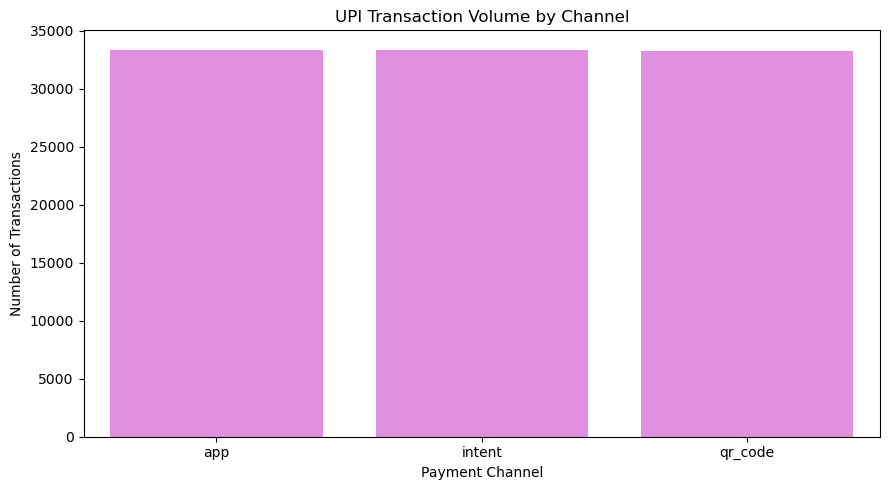

In [160]:
# TASK: Visualizing transaction volume by payment channel to identify the most frequently used transaction channels.

plt.figure(figsize=(9, 5))

sns.barplot(
    data=channel_analysis.sort_values(
        "transaction_count",
        ascending=False
    ),
    x="channel",
    y="transaction_count",
    color='violet'
)

plt.title("UPI Transaction Volume by Channel")
plt.xlabel("Payment Channel")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

In [161]:
# TASK: Interpreting transaction-channel activity and identifying the channels with the greatest transaction and monetary exposure.

highest_volume_channel = channel_analysis.loc[
    channel_analysis["transaction_count"].idxmax()
]

lowest_volume_channel = channel_analysis.loc[
    channel_analysis["transaction_count"].idxmin()
]

highest_value_channel = channel_analysis.loc[
    channel_analysis["total_transaction_value"].idxmax()
]

print("=" * 80)
print("CHANNEL TRANSACTION VOLUME — BUSINESS ANALYSIS")
print("=" * 80)

print(f"""
1. HIGHEST TRANSACTION VOLUME
   {highest_volume_channel["channel"]} records the highest transaction
   volume with {highest_volume_channel["transaction_count"]:,} transactions.

2. LOWEST TRANSACTION VOLUME
   {lowest_volume_channel["channel"]} records the lowest transaction
   volume with {lowest_volume_channel["transaction_count"]:,} transactions.

3. HIGHEST TOTAL TRANSACTION VALUE
   {highest_value_channel["channel"]} records the highest total
   transaction value of ₹{highest_value_channel["total_transaction_value"]:,.2f}.

4. BUSINESS INTERPRETATION
   Channel usage indicates where customers most frequently interact
   with the payment platform.

5. OPERATIONAL IMPLICATION
   High-volume channels represent important operational priorities
   because failures or service degradation can affect a larger
   transaction population.
""")

print("=" * 80)

CHANNEL TRANSACTION VOLUME — BUSINESS ANALYSIS

1. HIGHEST TRANSACTION VOLUME
   app records the highest transaction
   volume with 33,365 transactions.

2. LOWEST TRANSACTION VOLUME
   qr_code records the lowest transaction
   volume with 33,279 transactions.

3. HIGHEST TOTAL TRANSACTION VALUE
   app records the highest total
   transaction value of ₹1,420,081.79.

4. BUSINESS INTERPRETATION
   Channel usage indicates where customers most frequently interact
   with the payment platform.

5. OPERATIONAL IMPLICATION
   High-volume channels represent important operational priorities
   because failures or service degradation can affect a larger
   transaction population.



In [162]:
# TASK: Comparing transaction success, failure, and pending rates across payment channels to identify operational differences.

channel_status_analysis = channel_analysis[
    [
        "channel",
        "transaction_count",
        "success_rate_pct",
        "failure_rate_pct",
        "pending_rate_pct"
    ]
].sort_values(
    "failure_rate_pct",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("STEP 6.23 — CHANNEL OPERATIONAL PERFORMANCE")
print("=" * 70)

display(channel_status_analysis)

STEP 6.23 — CHANNEL OPERATIONAL PERFORMANCE


,channel,transaction_count,success_rate_pct,failure_rate_pct,pending_rate_pct
0,app,33365,92.000599,6.000300,1.999101
1,intent,33356,92.127353,5.899988,1.972659
2,qr_code,33279,92.292437,5.712311,1.995252


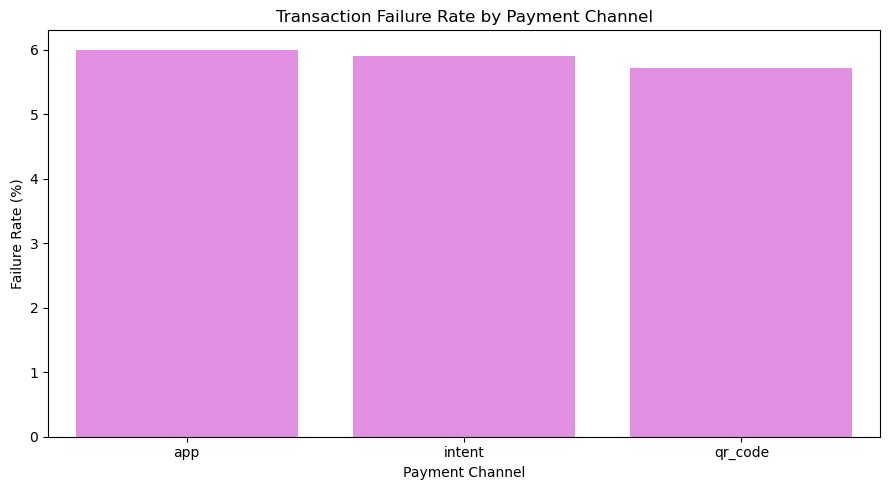

In [164]:
# TASK: Visualizing transaction failure rates across payment channels to identify channels with relatively weaker operational performance.

plt.figure(figsize=(9, 5))

sns.barplot(
    data=channel_status_analysis,
    x="channel",
    y="failure_rate_pct",color='violet'
)

plt.title("Transaction Failure Rate by Payment Channel")
plt.xlabel("Payment Channel")
plt.ylabel("Failure Rate (%)")
plt.tight_layout()
plt.show()

In [165]:
# TASK: Interpreting channel-level success, failure, and pending rates to identify operationally weaker payment channels.

highest_failure_channel = channel_analysis.loc[
    channel_analysis["failure_rate_pct"].idxmax()
]

lowest_failure_channel = channel_analysis.loc[
    channel_analysis["failure_rate_pct"].idxmin()
]

highest_success_channel = channel_analysis.loc[
    channel_analysis["success_rate_pct"].idxmax()
]

print("=" * 80)
print("CHANNEL OPERATIONAL PERFORMANCE — BUSINESS ANALYSIS")
print("=" * 80)

print(f"""
1. HIGHEST FAILURE-RATE CHANNEL
   {highest_failure_channel["channel"]} records the highest failure rate
   at {highest_failure_channel["failure_rate_pct"]:.4f}%.

2. LOWEST FAILURE-RATE CHANNEL
   {lowest_failure_channel["channel"]} records the lowest failure rate
   at {lowest_failure_channel["failure_rate_pct"]:.4f}%.

3. HIGHEST SUCCESS-RATE CHANNEL
   {highest_success_channel["channel"]} records the highest success rate
   at {highest_success_channel["success_rate_pct"]:.4f}%.

4. BUSINESS INTERPRETATION
   Differences in failure rates may indicate that transaction reliability
   varies by payment channel.

5. OPERATIONAL IMPLICATION
   Channels with elevated failure rates should be examined further by
   device type, transaction type, region, and failure reason to identify
   potential operational bottlenecks.
""")

print("=" * 80)

CHANNEL OPERATIONAL PERFORMANCE — BUSINESS ANALYSIS

1. HIGHEST FAILURE-RATE CHANNEL
   app records the highest failure rate
   at 6.0003%.

2. LOWEST FAILURE-RATE CHANNEL
   qr_code records the lowest failure rate
   at 5.7123%.

3. HIGHEST SUCCESS-RATE CHANNEL
   qr_code records the highest success rate
   at 92.2924%.

4. BUSINESS INTERPRETATION
   Differences in failure rates may indicate that transaction reliability
   varies by payment channel.

5. OPERATIONAL IMPLICATION
   Channels with elevated failure rates should be examined further by
   device type, transaction type, region, and failure reason to identify
   potential operational bottlenecks.



In [166]:
# TASK: Comparing fraud rates across payment channels to identify channels with elevated observed fraud exposure.

channel_fraud_analysis = (
    channel_analysis[
        [
            "channel",
            "transaction_count",
            "fraud_transactions",
            "fraud_rate_pct",
            "total_transaction_value"
        ]
    ]
    .sort_values(
        "fraud_rate_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("STEP 6.24 — CHANNEL FRAUD ANALYSIS")
print("=" * 70)

display(channel_fraud_analysis)

STEP 6.24 — CHANNEL FRAUD ANALYSIS


,channel,transaction_count,fraud_transactions,fraud_rate_pct,total_transaction_value
0,qr_code,33279,698,2.097419,1407179.34
1,app,33365,673,2.017084,1420081.79
2,intent,33356,629,1.885718,1414513.13


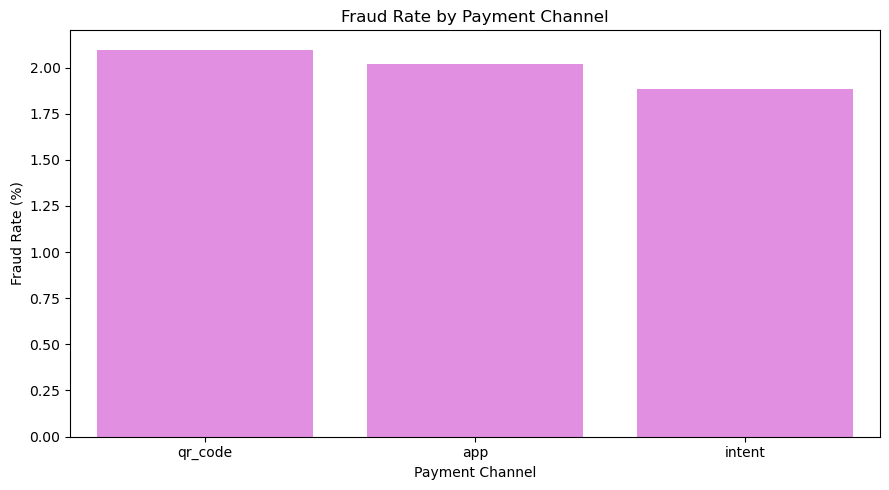

In [168]:
# TASK: Visualizing fraud rates across payment channels to highlight differences in observed fraud exposure.

plt.figure(figsize=(9, 5))

sns.barplot(
    data=channel_fraud_analysis,
    x="channel",
    y="fraud_rate_pct", color='violet'
)

plt.title("Fraud Rate by Payment Channel")
plt.xlabel("Payment Channel")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()

In [169]:
# TASK: Interpreting channel-level fraud exposure by combining fraud rate, transaction volume, and transaction value.

highest_channel_fraud = channel_analysis.loc[
    channel_analysis["fraud_rate_pct"].idxmax()
]

lowest_channel_fraud = channel_analysis.loc[
    channel_analysis["fraud_rate_pct"].idxmin()
]

print("=" * 80)
print("CHANNEL FRAUD EXPOSURE — BUSINESS ANALYSIS")
print("=" * 80)

print(f"""
1. HIGHEST FRAUD-RATE CHANNEL
   {highest_channel_fraud["channel"]} records the highest observed fraud
   rate at {highest_channel_fraud["fraud_rate_pct"]:.4f}%.

2. LOWEST FRAUD-RATE CHANNEL
   {lowest_channel_fraud["channel"]} records the lowest observed fraud
   rate at {lowest_channel_fraud["fraud_rate_pct"]:.4f}%.

3. FRAUD-RATE DIFFERENCE
   The difference between the highest and lowest channel fraud rates is
   {highest_channel_fraud["fraud_rate_pct"] - lowest_channel_fraud["fraud_rate_pct"]:.4f}
   percentage points.

4. BUSINESS INTERPRETATION
   Fraud exposure differs across payment channels, but rate alone does
   not determine business priority.

5. RISK-MANAGEMENT IMPLICATION
   Channels with elevated fraud rates should be evaluated alongside
   transaction volume and monetary exposure before prioritizing controls.

6. ANALYTICAL CAUTION
   These are observed channel-level associations. Formal statistical
   testing is performed later in Step 7.
""")

print("=" * 80)

CHANNEL FRAUD EXPOSURE — BUSINESS ANALYSIS

1. HIGHEST FRAUD-RATE CHANNEL
   qr_code records the highest observed fraud
   rate at 2.0974%.

2. LOWEST FRAUD-RATE CHANNEL
   intent records the lowest observed fraud
   rate at 1.8857%.

3. FRAUD-RATE DIFFERENCE
   The difference between the highest and lowest channel fraud rates is
   0.2117
   percentage points.

4. BUSINESS INTERPRETATION
   Fraud exposure differs across payment channels, but rate alone does
   not determine business priority.

5. RISK-MANAGEMENT IMPLICATION
   Channels with elevated fraud rates should be evaluated alongside
   transaction volume and monetary exposure before prioritizing controls.

6. ANALYTICAL CAUTION
   These are observed channel-level associations. Formal statistical
   testing is performed later in Step 7.



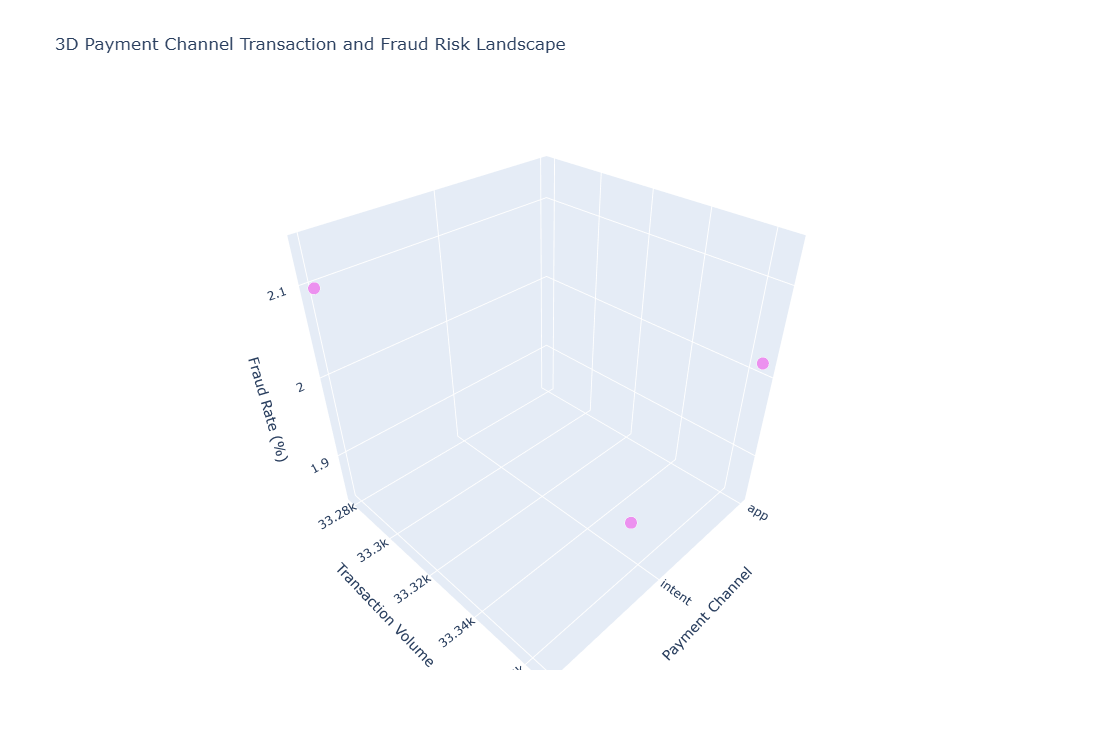

In [170]:
# TASK: Creating an interactive 3D channel-risk landscape combining transaction volume, fraud rate, and transaction value.

channel_3d = channel_analysis.copy()

fig = px.scatter_3d(
    channel_3d,
    x="channel",
    y="transaction_count",
    z="fraud_rate_pct",
    size="total_transaction_value",
    hover_name="channel",
    hover_data={
        "transaction_count": True,
        "total_transaction_value": ":.2f",
        "average_transaction_value": ":.2f",
        "fraud_transactions": True,
        "fraud_rate_pct": ":.4f",
        "failure_rate_pct": ":.4f",
        "success_rate_pct": ":.4f"
    },
    title="3D Payment Channel Transaction and Fraud Risk Landscape",
    labels={
        "channel": "Payment Channel",
        "transaction_count": "Transaction Volume",
        "fraud_rate_pct": "Fraud Rate (%)",
        "total_transaction_value": "Transaction Value"
    }
)

# Zooming the Z-axis to the observed fraud-rate range
z_min_channel = channel_3d["fraud_rate_pct"].min()
z_max_channel = channel_3d["fraud_rate_pct"].max()

z_padding_channel = max(
    (z_max_channel - z_min_channel) * 0.15,
    0.05
)

fig.update_layout(
    height=750,
    scene=dict(
        zaxis=dict(
            title="Fraud Rate (%)",
            range=[
                z_min_channel - z_padding_channel,
                z_max_channel + z_padding_channel
            ]
        ),
        xaxis=dict(
            title="Payment Channel"
        ),
        yaxis=dict(
            title="Transaction Volume"
        )
    )
)

# Applying a violet theme to the markers
fig.update_traces(
    marker=dict(
        color="violet",
        opacity=0.85
    )
)

fig.show()

In [171]:
# TASK: Interpreting the 3D channel-risk landscape by combining transaction activity, monetary exposure, fraud rate, and operational reliability.

highest_volume_channel = channel_3d.loc[
    channel_3d["transaction_count"].idxmax()
]

highest_value_channel = channel_3d.loc[
    channel_3d["total_transaction_value"].idxmax()
]

highest_fraud_channel = channel_3d.loc[
    channel_3d["fraud_rate_pct"].idxmax()
]

highest_failure_channel = channel_3d.loc[
    channel_3d["failure_rate_pct"].idxmax()
]

print("=" * 80)
print("3D CHANNEL TRANSACTION AND FRAUD RISK — BUSINESS ANALYSIS")
print("=" * 80)

print(f"""
1. HIGHEST TRANSACTION VOLUME
   {highest_volume_channel["channel"]} handles
   {highest_volume_channel["transaction_count"]:,} transactions.

2. HIGHEST TRANSACTION VALUE
   {highest_value_channel["channel"]} records total transaction value
   of ₹{highest_value_channel["total_transaction_value"]:,.2f}.

3. HIGHEST FRAUD RATE
   {highest_fraud_channel["channel"]} records the highest observed
   fraud rate of {highest_fraud_channel["fraud_rate_pct"]:.4f}%.

4. HIGHEST FAILURE RATE
   {highest_failure_channel["channel"]} records the highest failure
   rate of {highest_failure_channel["failure_rate_pct"]:.4f}%.

5. BUSINESS INTERPRETATION
   The 3D landscape shows that channel performance has multiple
   dimensions. Transaction frequency, monetary exposure, fraud rate,
   and operational reliability should be evaluated together.

6. RISK-MANAGEMENT IMPLICATION
   A high-priority channel is not necessarily the channel with the
   highest fraud rate alone. Channels combining meaningful transaction
   activity with elevated fraud or failure rates may represent greater
   operational exposure.

7. ANALYTICAL CAUTION
   Channel-level relationships are descriptive associations. Formal
   statistical testing is performed in Step 7.
""")

print("=" * 80)

3D CHANNEL TRANSACTION AND FRAUD RISK — BUSINESS ANALYSIS

1. HIGHEST TRANSACTION VOLUME
   app handles
   33,365 transactions.

2. HIGHEST TRANSACTION VALUE
   app records total transaction value
   of ₹1,420,081.79.

3. HIGHEST FRAUD RATE
   qr_code records the highest observed
   fraud rate of 2.0974%.

4. HIGHEST FAILURE RATE
   app records the highest failure
   rate of 6.0003%.

5. BUSINESS INTERPRETATION
   The 3D landscape shows that channel performance has multiple
   dimensions. Transaction frequency, monetary exposure, fraud rate,
   and operational reliability should be evaluated together.

6. RISK-MANAGEMENT IMPLICATION
   A high-priority channel is not necessarily the channel with the
   highest fraud rate alone. Channels combining meaningful transaction
   activity with elevated fraud or failure rates may represent greater
   operational exposure.

7. ANALYTICAL CAUTION
   Channel-level relationships are descriptive associations. Formal
   statistical testing is performe

In [172]:
# TASK: Creating failure-reason metrics to identify the most common operational failure causes and their financial exposure.

failed_transactions_analysis = transactions_analysis[
    transactions_analysis["status"].astype(str).str.lower() == "failed"
].copy()

# Keeping only failed transactions with a recorded failure reason
failed_with_reason = failed_transactions_analysis[
    failed_transactions_analysis["failure_reason"].notna()
    & (
        failed_transactions_analysis["failure_reason"]
        .astype(str)
        .str.strip()
        .ne("")
    )
].copy()

failure_reason_analysis = (
    failed_with_reason
    .groupby("failure_reason")
    .agg(
        failed_transaction_count=("transaction_id", "count"),
        total_failed_transaction_value=("amount", "sum"),
        average_failed_transaction_value=("amount", "mean"),
        fraud_transactions=("fraud_flag", "sum"),
        reversed_transactions=("reversal_flag", "sum")
    )
    .reset_index()
)

failure_reason_analysis["failure_reason_share_pct"] = (
    failure_reason_analysis["failed_transaction_count"]
    / failure_reason_analysis["failed_transaction_count"].sum()
    * 100
)

failure_reason_analysis["fraud_rate_pct"] = (
    failure_reason_analysis["fraud_transactions"]
    / failure_reason_analysis["failed_transaction_count"]
    * 100
)

failure_reason_analysis["reversal_rate_pct"] = (
    failure_reason_analysis["reversed_transactions"]
    / failure_reason_analysis["failed_transaction_count"]
    * 100
)

failure_reason_analysis = (
    failure_reason_analysis
    .sort_values(
        "failed_transaction_count",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("STEP 6.26 — FAILURE REASON ANALYSIS")
print("=" * 70)

print("Total failed transactions:",
      len(failed_transactions_analysis))

print("Failed transactions with recorded failure reason:",
      len(failed_with_reason))

print("\nFailure reason summary:")

display(failure_reason_analysis)

STEP 6.26 — FAILURE REASON ANALYSIS
Total failed transactions: 5871
Failed transactions with recorded failure reason: 5871

Failure reason summary:


,failure_reason,failed_transaction_count,total_failed_transaction_value,average_failed_transaction_value,fraud_transactions,reversed_transactions,failure_reason_share_pct,fraud_rate_pct,reversal_rate_pct
0,incorrect_pin,1511,65414.70,43.292323,32,373,25.736672,2.117803,24.685639
1,network_error,1486,63178.55,42.515848,37,369,25.310850,2.489906,24.831763
2,account_blocked,1455,62480.78,42.942117,27,344,24.782831,1.855670,23.642612
3,bank_down,1419,60174.65,42.406378,29,365,24.169647,2.043693,25.722340


In [173]:
# TASK: Interpreting failure reasons by identifying the most frequent, highest-value, and highest-fraud failure categories.

most_common_failure = failure_reason_analysis.loc[
    failure_reason_analysis["failed_transaction_count"].idxmax()
]

highest_value_failure = failure_reason_analysis.loc[
    failure_reason_analysis["total_failed_transaction_value"].idxmax()
]

highest_fraud_failure = failure_reason_analysis.loc[
    failure_reason_analysis["fraud_rate_pct"].idxmax()
]

print("=" * 80)
print("FAILURE REASON — BUSINESS ANALYSIS")
print("=" * 80)

print(f"""
1. MOST FREQUENT FAILURE REASON
   {most_common_failure["failure_reason"]} accounts for
   {most_common_failure["failed_transaction_count"]:,} failed transactions,
   representing {most_common_failure["failure_reason_share_pct"]:.2f}% of
   failed transactions with a recorded reason.

2. HIGHEST FINANCIAL EXPOSURE
   {highest_value_failure["failure_reason"]} is associated with the highest
   failed transaction value of
   ₹{highest_value_failure["total_failed_transaction_value"]:,.2f}.

3. HIGHEST OBSERVED FRAUD RATE
   {highest_fraud_failure["failure_reason"]} has the highest observed
   fraud rate among the recorded failure reasons at
   {highest_fraud_failure["fraud_rate_pct"]:.4f}%.

4. BUSINESS INTERPRETATION
   Failure reasons identify operational problem areas that cannot be
   detected from the overall failure rate alone.

5. OPERATIONAL IMPLICATION
   High-frequency failure causes are candidates for process or
   infrastructure improvement, while high-value or high-fraud
   failure categories may require additional risk investigation.

6. ANALYTICAL CAUTION
   A failure reason with a high fraud rate may have a relatively small
   number of observations. Volume and monetary exposure should therefore
   be considered together with the rate.
""")

print("=" * 80)

FAILURE REASON — BUSINESS ANALYSIS

1. MOST FREQUENT FAILURE REASON
   incorrect_pin accounts for
   1,511 failed transactions,
   representing 25.74% of
   failed transactions with a recorded reason.

2. HIGHEST FINANCIAL EXPOSURE
   incorrect_pin is associated with the highest
   failed transaction value of
   ₹65,414.70.

3. HIGHEST OBSERVED FRAUD RATE
   network_error has the highest observed
   fraud rate among the recorded failure reasons at
   2.4899%.

4. BUSINESS INTERPRETATION
   Failure reasons identify operational problem areas that cannot be
   detected from the overall failure rate alone.

5. OPERATIONAL IMPLICATION
   High-frequency failure causes are candidates for process or
   infrastructure improvement, while high-value or high-fraud
   failure categories may require additional risk investigation.

6. ANALYTICAL CAUTION
   A failure reason with a high fraud rate may have a relatively small
   number of observations. Volume and monetary exposure should therefore
   be

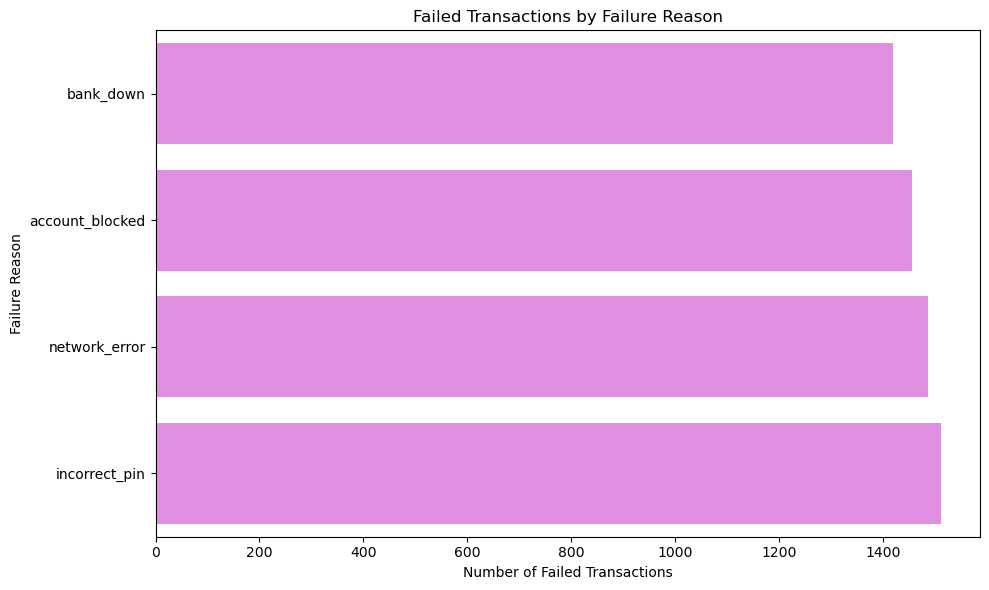

In [175]:
# TASK: Visualizing failed transactions by failure reason to identify the largest operational failure categories.

failure_plot_data = (
    failure_reason_analysis
    .sort_values(
        "failed_transaction_count",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=failure_plot_data,
    x="failed_transaction_count",
    y="failure_reason", color='violet'
)

plt.title("Failed Transactions by Failure Reason")
plt.xlabel("Number of Failed Transactions")
plt.ylabel("Failure Reason")
plt.tight_layout()
plt.show()

In [176]:
# TASK: Creating failure-reason and payment-channel metrics to identify operational bottlenecks within specific transaction channels.

failure_channel_analysis = (
    failed_with_reason
    .groupby(
        ["channel", "failure_reason"]
    )
    .agg(
        failed_transaction_count=("transaction_id", "count"),
        total_failed_transaction_value=("amount", "sum"),
        average_failed_transaction_value=("amount", "mean"),
        fraud_transactions=("fraud_flag", "sum")
    )
    .reset_index()
)

failure_channel_analysis["fraud_rate_pct"] = (
    failure_channel_analysis["fraud_transactions"]
    / failure_channel_analysis["failed_transaction_count"]
    * 100
)

print("=" * 70)
print("STEP 6.27 — FAILURE REASON BY CHANNEL")
print("=" * 70)

display(
    failure_channel_analysis.sort_values(
        "failed_transaction_count",
        ascending=False
    ).head(20)
)

STEP 6.27 — FAILURE REASON BY CHANNEL


,channel,failure_reason,failed_transaction_count,total_failed_transaction_value,average_failed_transaction_value,fraud_transactions,fraud_rate_pct
2,app,incorrect_pin,522,21898.98,41.952069,9,1.724138
6,intent,incorrect_pin,520,22659.82,43.576577,14,2.692308
3,app,network_error,508,20994.03,41.326831,9,1.771654
4,intent,account_blocked,506,21226.33,41.949269,6,1.185771
11,qr_code,network_error,495,22027.05,44.499091,14,2.828283
0,app,account_blocked,494,21437.99,43.396741,12,2.429150
7,intent,network_error,483,20157.47,41.733892,14,2.898551
9,qr_code,bank_down,482,20447.62,42.422448,10,2.074689
1,app,bank_down,478,19103.64,39.965774,11,2.301255
10,qr_code,incorrect_pin,469,20855.90,44.468870,9,1.918977


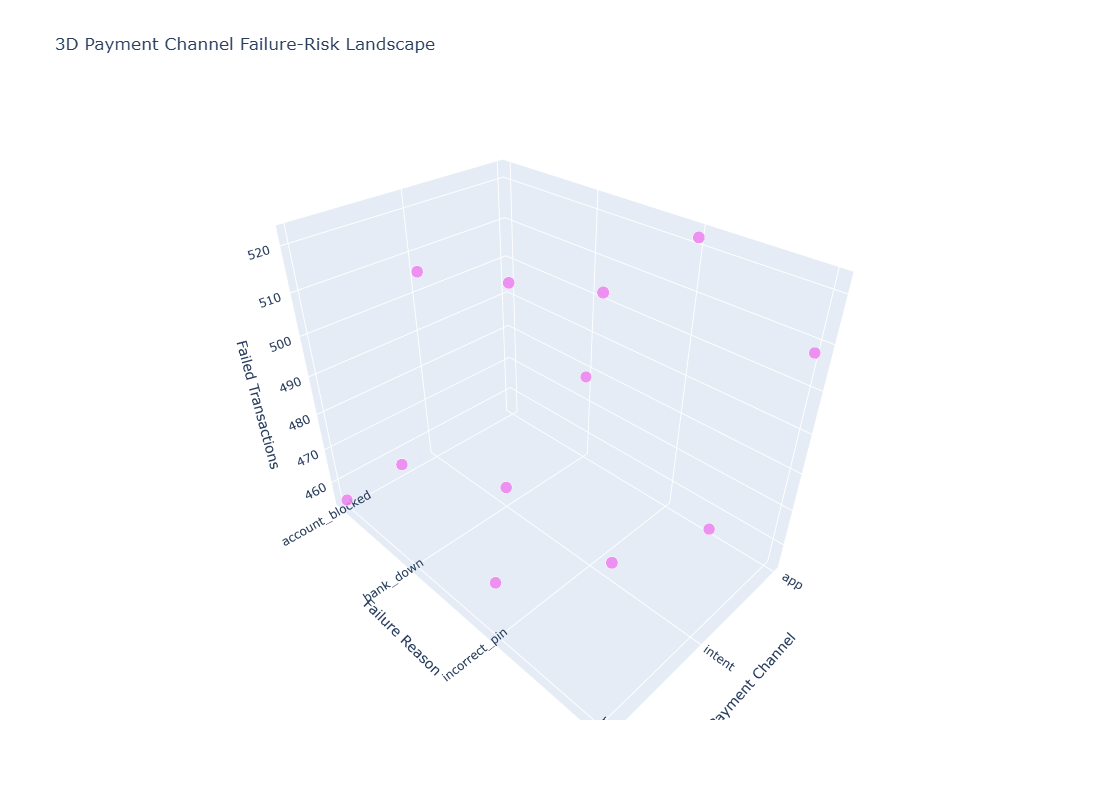

In [177]:
# TASK: Creating an interactive 3D failure landscape combining payment channel, failure reason, failure volume, and financial exposure.

failure_3d = failure_channel_analysis.copy()

fig = px.scatter_3d(
    failure_3d,
    x="channel",
    y="failure_reason",
    z="failed_transaction_count",
    size="total_failed_transaction_value",
    hover_name="failure_reason",
    hover_data={
        "channel": True,
        "failure_reason": True,
        "failed_transaction_count": True,
        "total_failed_transaction_value": ":.2f",
        "average_failed_transaction_value": ":.2f",
        "fraud_transactions": True,
        "fraud_rate_pct": ":.4f"
    },
    title="3D Payment Channel Failure-Risk Landscape",
    labels={
        "channel": "Payment Channel",
        "failure_reason": "Failure Reason",
        "failed_transaction_count": "Failed Transactions",
        "total_failed_transaction_value": "Failed Transaction Value"
    }
)

# Applying a violet visual treatment
fig.update_traces(
    marker=dict(
        color="violet",
        opacity=0.85
    )
)

# Improving the 3D scene height
fig.update_layout(
    height=800,
    scene=dict(
        xaxis=dict(
            title="Payment Channel"
        ),
        yaxis=dict(
            title="Failure Reason"
        ),
        zaxis=dict(
            title="Failed Transactions"
        )
    )
)

fig.show()

In [178]:
# TASK: Interpreting the 3D failure landscape to identify channel-failure combinations with high operational and financial exposure.

highest_failure_volume = failure_3d.loc[
    failure_3d["failed_transaction_count"].idxmax()
]

highest_failure_value = failure_3d.loc[
    failure_3d["total_failed_transaction_value"].idxmax()
]

highest_fraud_rate = failure_3d.loc[
    failure_3d["fraud_rate_pct"].idxmax()
]

print("=" * 80)
print("3D FAILURE-RISK LANDSCAPE — BUSINESS ANALYSIS")
print("=" * 80)

print(f"""
1. HIGHEST FAILURE-VOLUME COMBINATION
   Channel: {highest_failure_volume["channel"]}
   Failure reason: {highest_failure_volume["failure_reason"]}
   Failed transactions: {highest_failure_volume["failed_transaction_count"]:,}

2. HIGHEST FINANCIAL-EXPOSURE COMBINATION
   Channel: {highest_failure_value["channel"]}
   Failure reason: {highest_failure_value["failure_reason"]}
   Failed transaction value:
   ₹{highest_failure_value["total_failed_transaction_value"]:,.2f}

3. HIGHEST OBSERVED FRAUD-RATE COMBINATION
   Channel: {highest_fraud_rate["channel"]}
   Failure reason: {highest_fraud_rate["failure_reason"]}
   Fraud rate: {highest_fraud_rate["fraud_rate_pct"]:.4f}%

4. BUSINESS INTERPRETATION
   The 3D view combines failure frequency, financial exposure,
   payment channel, and failure cause in a single analytical view.

5. OPERATIONAL IMPLICATION
   Channel-failure combinations with high failure volume should be
   considered for reliability improvements, while combinations with
   high monetary exposure or elevated fraud rates warrant additional
   investigation.

6. ANALYTICAL CAUTION
   A high failure volume or fraud rate does not by itself establish
   the underlying cause. Further investigation and statistical
   testing are required.
""")

print("=" * 80)

3D FAILURE-RISK LANDSCAPE — BUSINESS ANALYSIS

1. HIGHEST FAILURE-VOLUME COMBINATION
   Channel: app
   Failure reason: incorrect_pin
   Failed transactions: 522

2. HIGHEST FINANCIAL-EXPOSURE COMBINATION
   Channel: intent
   Failure reason: incorrect_pin
   Failed transaction value:
   ₹22,659.82

3. HIGHEST OBSERVED FRAUD-RATE COMBINATION
   Channel: intent
   Failure reason: network_error
   Fraud rate: 2.8986%

4. BUSINESS INTERPRETATION
   The 3D view combines failure frequency, financial exposure,
   payment channel, and failure cause in a single analytical view.

5. OPERATIONAL IMPLICATION
   Channel-failure combinations with high failure volume should be
   considered for reliability improvements, while combinations with
   high monetary exposure or elevated fraud rates warrant additional
   investigation.

6. ANALYTICAL CAUTION
   A high failure volume or fraud rate does not by itself establish
   the underlying cause. Further investigation and statistical
   testing are requ

In [179]:
# TASK: Creating monthly transaction, transaction-value, failed-transaction, and fraud trends for temporal performance analysis.

monthly_analysis = (
    transactions_analysis
    .set_index("timestamp")
    .resample("MS")
    .agg(
        transaction_count=("transaction_id", "count"),
        total_transaction_value=("amount", "sum"),
        average_transaction_value=("amount", "mean"),
        fraud_transactions=("fraud_flag", "sum"),
        failed_transactions=(
            "status",
            lambda x: (x == "failed").sum()
        ),
        pending_transactions=(
            "status",
            lambda x: (x == "pending").sum()
        ),
        reversals=("reversal_flag", "sum")
    )
    .reset_index()
)

monthly_analysis["fraud_rate_pct"] = (
    monthly_analysis["fraud_transactions"]
    / monthly_analysis["transaction_count"]
    * 100
)

monthly_analysis["failure_rate_pct"] = (
    monthly_analysis["failed_transactions"]
    / monthly_analysis["transaction_count"]
    * 100
)

monthly_analysis["reversal_rate_pct"] = (
    monthly_analysis["reversals"]
    / monthly_analysis["transaction_count"]
    * 100
)

print("=" * 70)
print("STEP 6.28 — MONTHLY TRANSACTION AND FRAUD TRENDS")
print("=" * 70)

display(monthly_analysis)

STEP 6.28 — MONTHLY TRANSACTION AND FRAUD TRENDS


,timestamp,transaction_count,total_transaction_value,average_transaction_value,fraud_transactions,failed_transactions,pending_transactions,reversals,fraud_rate_pct,failure_rate_pct,reversal_rate_pct
0,2020-10-01,1,25.10,25.100000,0,0,0,0,0.000000,0.000000,0.000000
1,2020-11-01,2,118.61,59.305000,0,0,0,0,0.000000,0.000000,0.000000
2,2020-12-01,2,44.14,22.070000,0,0,0,0,0.000000,0.000000,0.000000
3,2021-01-01,5,167.48,33.496000,0,0,0,0,0.000000,0.000000,0.000000
4,2021-02-01,11,582.15,52.922727,0,0,0,0,0.000000,0.000000,0.000000
5,2021-03-01,25,1373.93,54.957200,1,0,0,0,4.000000,0.000000,0.000000
6,2021-04-01,15,1029.33,68.622000,1,1,1,1,6.666667,6.666667,6.666667
7,2021-05-01,18,794.39,44.132778,1,1,0,0,5.555556,5.555556,0.000000
8,2021-06-01,29,1439.83,49.649310,1,2,1,0,3.448276,6.896552,0.000000
9,2021-07-01,35,1423.97,40.684857,1,3,2,2,2.857143,8.571429,5.714286


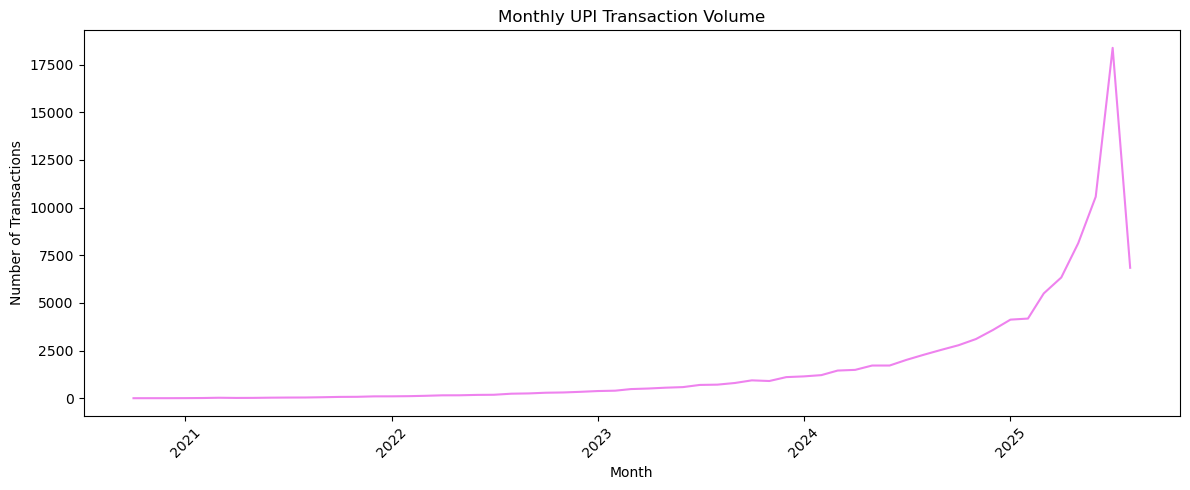

In [180]:
# TASK: Visualizing monthly transaction volume to identify growth, seasonality, and changes in platform activity.

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_analysis,
    x="timestamp",
    y="transaction_count",
    color='violet'
)

plt.title("Monthly UPI Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

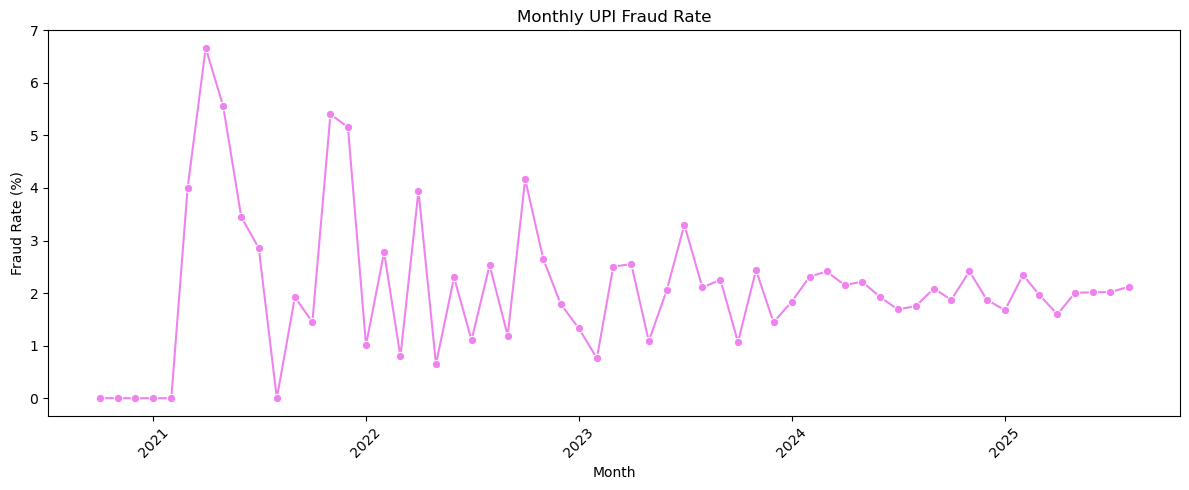

In [182]:
# TASK: Visualizing monthly fraud rates to identify temporal changes in transaction risk.

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_analysis,
    x="timestamp",
    y="fraud_rate_pct",
    color='violet',
    marker="o"
)

plt.title("Monthly UPI Fraud Rate")
plt.xlabel("Month")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [183]:
# TASK: Interpreting monthly transaction and fraud trends by identifying activity peaks and periods of elevated observed fraud risk.

highest_volume_month = monthly_analysis.loc[
    monthly_analysis["transaction_count"].idxmax()
]

highest_value_month = monthly_analysis.loc[
    monthly_analysis["total_transaction_value"].idxmax()
]

highest_fraud_rate_month = monthly_analysis.loc[
    monthly_analysis["fraud_rate_pct"].idxmax()
]

lowest_fraud_rate_month = monthly_analysis.loc[
    monthly_analysis["fraud_rate_pct"].idxmin()
]

print("=" * 80)
print("MONTHLY TRANSACTION AND FRAUD TRENDS — BUSINESS ANALYSIS")
print("=" * 80)

print(f"""
1. HIGHEST- VOLUME MONTH
   {highest_volume_month["timestamp"].strftime("%B %Y")} records the highest
   transaction volume with {highest_volume_month["transaction_count"]:,} transactions.

2. HIGHEST-VALUE MONTH
   {highest_value_month["timestamp"].strftime("%B %Y")} records the highest
   total transaction value of
   ₹{highest_value_month["total_transaction_value"]:,.2f}.

3. HIGHEST OBSERVED FRAUD-RATE MONTH
   {highest_fraud_rate_month["timestamp"].strftime("%B %Y")} records the highest
   observed fraud rate of
   {highest_fraud_rate_month["fraud_rate_pct"]:.4f}%.

4. LOWEST OBSERVED FRAUD-RATE MONTH
   {lowest_fraud_rate_month["timestamp"].strftime("%B %Y")} records the lowest
   observed fraud rate of
   {lowest_fraud_rate_month["fraud_rate_pct"]:.4f}%.

5. BUSINESS INTERPRETATION
   Transaction activity and fraud risk can change differently over time.
   A period with high transaction volume is not necessarily the period
   with the highest fraud rate.

6. RISK-MANAGEMENT IMPLICATION
   Months with elevated fraud rates can be investigated alongside
   transaction volume, channel, device type, region, merchant activity,
   and rooted-device exposure.
""")

print("=" * 80)

MONTHLY TRANSACTION AND FRAUD TRENDS — BUSINESS ANALYSIS

1. HIGHEST- VOLUME MONTH
   July 2025 records the highest
   transaction volume with 18,377 transactions.

2. HIGHEST-VALUE MONTH
   July 2025 records the highest
   total transaction value of
   ₹777,212.59.

3. HIGHEST OBSERVED FRAUD-RATE MONTH
   April 2021 records the highest
   observed fraud rate of
   6.6667%.

4. LOWEST OBSERVED FRAUD-RATE MONTH
   October 2020 records the lowest
   observed fraud rate of
   0.0000%.

5. BUSINESS INTERPRETATION
   Transaction activity and fraud risk can change differently over time.
   A period with high transaction volume is not necessarily the period
   with the highest fraud rate.

6. RISK-MANAGEMENT IMPLICATION
   Months with elevated fraud rates can be investigated alongside
   transaction volume, channel, device type, region, merchant activity,
   and rooted-device exposure.



In [184]:
# TASK: Creating grouped transaction statistics by region using mean, median, and standard deviation.

regional_grouped_stats = (
    transaction_region
    .groupby("region")["amount"]
    .agg(
        mean_transaction_amount="mean",
        median_transaction_amount="median",
        standard_deviation="std"
    )
    .reset_index()
)

print("=" * 70)
print("STEP 6.29 — GROUPED STATISTICS BY REGION")
print("=" * 70)

display(
    regional_grouped_stats.sort_values(
        "mean_transaction_amount",
        ascending=False
    )
)

STEP 6.29 — GROUPED STATISTICS BY REGION


,region,mean_transaction_amount,median_transaction_amount,standard_deviation
3,south,42.539278,33.14,34.240232
1,east,42.527747,32.91,34.311902
0,central,42.488194,33.34,34.537385
4,west,42.333227,33.05,33.669879
2,north,42.213204,33.07,34.176362


In [185]:
# TASK: Creating grouped transaction statistics by device type using mean, median, and standard deviation.

device_grouped_stats = (
    transactions_analysis
    .groupby("device_type")["amount"]
    .agg(
        mean_transaction_amount="mean",
        median_transaction_amount="median",
        standard_deviation="std"
    )
    .reset_index()
)

print("=" * 70)
print("STEP 6.30 — GROUPED STATISTICS BY DEVICE TYPE")
print("=" * 70)

display(
    device_grouped_stats.sort_values(
        "mean_transaction_amount",
        ascending=False
    )
)

STEP 6.30 — GROUPED STATISTICS BY DEVICE TYPE


,device_type,mean_transaction_amount,median_transaction_amount,standard_deviation
3,tablet,42.545060,33.415,34.233864
2,ios,42.542170,33.090,34.501120
0,android,42.376283,33.030,34.035585
1,feature_phone,42.216250,32.820,33.981463


In [186]:
# TASK: Creating grouped transaction statistics by transaction type using mean, median, and standard deviation.

transaction_type_grouped_stats = (
    transactions_analysis
    .groupby("transaction_type")["amount"]
    .agg(
        mean_transaction_amount="mean",
        median_transaction_amount="median",
        standard_deviation="std"
    )
    .reset_index()
)

print("=" * 70)
print("STEP 6.31 — GROUPED STATISTICS BY TRANSACTION TYPE")
print("=" * 70)

display(
    transaction_type_grouped_stats.sort_values(
        "mean_transaction_amount",
        ascending=False
    )
)

STEP 6.31 — GROUPED STATISTICS BY TRANSACTION TYPE


,transaction_type,mean_transaction_amount,median_transaction_amount,standard_deviation
0,bill_pay,42.801641,33.085,34.546478
2,receive,42.496481,33.100,34.267417
1,merchant_payment,42.391115,33.060,34.161596
3,send,42.303197,33.110,34.070890


In [187]:
# TASK: Creating grouped transaction statistics by payment channel using mean, median, and standard deviation.

channel_grouped_stats = (
    transactions_analysis
    .groupby("channel")["amount"]
    .agg(
        mean_transaction_amount="mean",
        median_transaction_amount="median",
        standard_deviation="std"
    )
    .reset_index()
)

print("=" * 70)
print("STEP 6.32 — GROUPED STATISTICS BY PAYMENT CHANNEL")
print("=" * 70)

display(
    channel_grouped_stats.sort_values(
        "mean_transaction_amount",
        ascending=False
    )
)

STEP 6.32 — GROUPED STATISTICS BY PAYMENT CHANNEL


,channel,mean_transaction_amount,median_transaction_amount,standard_deviation
0,app,42.562020,33.21,34.11658
1,intent,42.406557,33.14,34.27906
2,qr_code,42.284304,32.91,34.16259


In [188]:
# TASK: Creating grouped transaction statistics by merchant type using mean, median, and standard deviation.

transaction_merchant = transactions_analysis.merge(
    merchants_analysis[
        ["merchant_id", "merchant_type"]
    ],
    on="merchant_id",
    how="left"
)

merchant_type_grouped_stats = (
    transaction_merchant[
        transaction_merchant["merchant_id"].notna()
    ]
    .groupby("merchant_type")["amount"]
    .agg(
        mean_transaction_amount="mean",
        median_transaction_amount="median",
        standard_deviation="std"
    )
    .reset_index()
)

print("=" * 70)
print("STEP 6.33 — GROUPED STATISTICS BY MERCHANT TYPE")
print("=" * 70)

display(
    merchant_type_grouped_stats.sort_values(
        "mean_transaction_amount",
        ascending=False
    )
)

STEP 6.33 — GROUPED STATISTICS BY MERCHANT TYPE


,merchant_type,mean_transaction_amount,median_transaction_amount,standard_deviation
4,online,42.988874,33.220,35.583800
5,transport,42.890055,33.405,35.754099
1,electronics,42.662551,33.120,34.321255
2,food,42.393157,33.460,33.131053
0,apparel,42.099579,32.820,33.773058
3,grocery,41.751611,32.545,32.775837


In [189]:
# TASK: Creating a consolidated grouped-statistics summary to identify the groups with the highest average, median, and transaction-value variability.

grouped_statistics_summary = pd.DataFrame({
    "grouping_dimension": [
        "Region",
        "Device Type",
        "Transaction Type",
        "Payment Channel",
        "Merchant Type"
    ],
    "highest_mean_group": [
        regional_grouped_stats.loc[
            regional_grouped_stats["mean_transaction_amount"].idxmax(),
            "region"
        ],
        device_grouped_stats.loc[
            device_grouped_stats["mean_transaction_amount"].idxmax(),
            "device_type"
        ],
        transaction_type_grouped_stats.loc[
            transaction_type_grouped_stats["mean_transaction_amount"].idxmax(),
            "transaction_type"
        ],
        channel_grouped_stats.loc[
            channel_grouped_stats["mean_transaction_amount"].idxmax(),
            "channel"
        ],
        merchant_type_grouped_stats.loc[
            merchant_type_grouped_stats["mean_transaction_amount"].idxmax(),
            "merchant_type"
        ]
    ],
    "highest_mean_value": [
        regional_grouped_stats["mean_transaction_amount"].max(),
        device_grouped_stats["mean_transaction_amount"].max(),
        transaction_type_grouped_stats["mean_transaction_amount"].max(),
        channel_grouped_stats["mean_transaction_amount"].max(),
        merchant_type_grouped_stats["mean_transaction_amount"].max()
    ],
    "highest_median_group": [
        regional_grouped_stats.loc[
            regional_grouped_stats["median_transaction_amount"].idxmax(),
            "region"
        ],
        device_grouped_stats.loc[
            device_grouped_stats["median_transaction_amount"].idxmax(),
            "device_type"
        ],
        transaction_type_grouped_stats.loc[
            transaction_type_grouped_stats["median_transaction_amount"].idxmax(),
            "transaction_type"
        ],
        channel_grouped_stats.loc[
            channel_grouped_stats["median_transaction_amount"].idxmax(),
            "channel"
        ],
        merchant_type_grouped_stats.loc[
            merchant_type_grouped_stats["median_transaction_amount"].idxmax(),
            "merchant_type"
        ]
    ],
    "highest_std_group": [
        regional_grouped_stats.loc[
            regional_grouped_stats["standard_deviation"].idxmax(),
            "region"
        ],
        device_grouped_stats.loc[
            device_grouped_stats["standard_deviation"].idxmax(),
            "device_type"
        ],
        transaction_type_grouped_stats.loc[
            transaction_type_grouped_stats["standard_deviation"].idxmax(),
            "transaction_type"
        ],
        channel_grouped_stats.loc[
            channel_grouped_stats["standard_deviation"].idxmax(),
            "channel"
        ],
        merchant_type_grouped_stats.loc[
            merchant_type_grouped_stats["standard_deviation"].idxmax(),
            "merchant_type"
        ]
    ]
})

print("=" * 70)
print("STEP 6.34 — CONSOLIDATED GROUPED STATISTICS SUMMARY")
print("=" * 70)

display(grouped_statistics_summary)

STEP 6.34 — CONSOLIDATED GROUPED STATISTICS SUMMARY


,grouping_dimension,highest_mean_group,highest_mean_value,highest_median_group,highest_std_group
0,Region,south,42.539278,central,central
1,Device Type,tablet,42.545060,tablet,ios
2,Transaction Type,bill_pay,42.801641,send,bill_pay
3,Payment Channel,app,42.562020,app,intent
4,Merchant Type,online,42.988874,food,transport


In [190]:
# TASK: Interpreting grouped transaction statistics to identify segments with higher transaction values and greater variability.

print("=" * 80)
print("GROUPED TRANSACTION STATISTICS — BUSINESS ANALYSIS")
print("=" * 80)

for _, row in grouped_statistics_summary.iterrows():

    print(f"""
{row["grouping_dimension"]}

Highest mean transaction amount:
    {row["highest_mean_group"]}

Highest median transaction amount:
    {row["highest_median_group"]}

Highest transaction-value variability:
    {row["highest_std_group"]}
""")

print("""
BUSINESS INTERPRETATION
-----------------------
Mean transaction amount highlights groups with higher average transaction
values, while median transaction amount provides a more robust view of the
typical transaction when extreme values are present.

Standard deviation highlights groups where transaction values are more
widely dispersed. Such groups may contain a broader mix of low- and
high-value transactions and can be useful populations for deeper
segmentation and anomaly investigation.

These statistics should be considered alongside transaction volume,
fraud rate, and failure rate rather than interpreted independently.
""")

print("=" * 80)

GROUPED TRANSACTION STATISTICS — BUSINESS ANALYSIS

Region

Highest mean transaction amount:
    south

Highest median transaction amount:
    central

Highest transaction-value variability:
    central


Device Type

Highest mean transaction amount:
    tablet

Highest median transaction amount:
    tablet

Highest transaction-value variability:
    ios


Transaction Type

Highest mean transaction amount:
    bill_pay

Highest median transaction amount:
    send

Highest transaction-value variability:
    bill_pay


Payment Channel

Highest mean transaction amount:
    app

Highest median transaction amount:
    app

Highest transaction-value variability:
    intent


Merchant Type

Highest mean transaction amount:
    online

Highest median transaction amount:
    food

Highest transaction-value variability:
    transport


BUSINESS INTERPRETATION
-----------------------
Mean transaction amount highlights groups with higher average transaction
values, while median transaction amount 

In [191]:
# TASK: Creating customer risk segments and linking customer risk scores with transaction activity and observed fraud exposure.

customer_risk_analysis = customer_analysis.copy()

# Creating interpretable risk bands
customer_risk_analysis["risk_band"] = pd.cut(
    customer_risk_analysis["risk_score"],
    bins=[-np.inf, 0.20, 0.40, 0.60, 0.80, np.inf],
    labels=[
        "Very Low",
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

# Filling missing transaction metrics for customers with no observed transactions
metric_columns = [
    "transaction_count",
    "total_transaction_value",
    "average_transaction_value",
    "fraud_transaction_count",
    "failed_transaction_count",
    "fraud_rate",
    "failure_rate"
]

for column in metric_columns:
    customer_risk_analysis[column] = (
        customer_risk_analysis[column].fillna(0)
    )

customer_risk_summary = (
    customer_risk_analysis
    .groupby("risk_band", observed=False)
    .agg(
        customers=("customer_id", "count"),
        transactions=("transaction_count", "sum"),
        total_transaction_value=("total_transaction_value", "sum"),
        average_customer_risk=("risk_score", "mean"),
        fraud_transactions=("fraud_transaction_count", "sum"),
        failed_transactions=("failed_transaction_count", "sum")
    )
    .reset_index()
)

customer_risk_summary["fraud_rate"] = (
    customer_risk_summary["fraud_transactions"]
    / customer_risk_summary["transactions"]
)

customer_risk_summary["failure_rate"] = (
    customer_risk_summary["failed_transactions"]
    / customer_risk_summary["transactions"]
)

print("=" * 70)
print("STEP 6.35 — CUSTOMER RISK-SEGMENT ANALYSIS")
print("=" * 70)

display(customer_risk_summary)

STEP 6.35 — CUSTOMER RISK-SEGMENT ANALYSIS


,risk_band,customers,transactions,total_transaction_value,average_customer_risk,fraud_transactions,failed_transactions,fraud_rate,failure_rate
0,Very Low,5134,51643.0,2190110.16,0.112762,1057.0,2996.0,0.020467,0.058014
1,Low,4402,43910.0,1859355.00,0.282885,859.0,2600.0,0.019563,0.059212
2,Moderate,456,4398.0,190454.73,0.450636,84.0,274.0,0.019100,0.062301
3,High,8,49.0,1854.37,0.637500,0.0,1.0,0.000000,0.020408
4,Very High,0,0.0,0.00,NaN,0.0,0.0,NaN,NaN


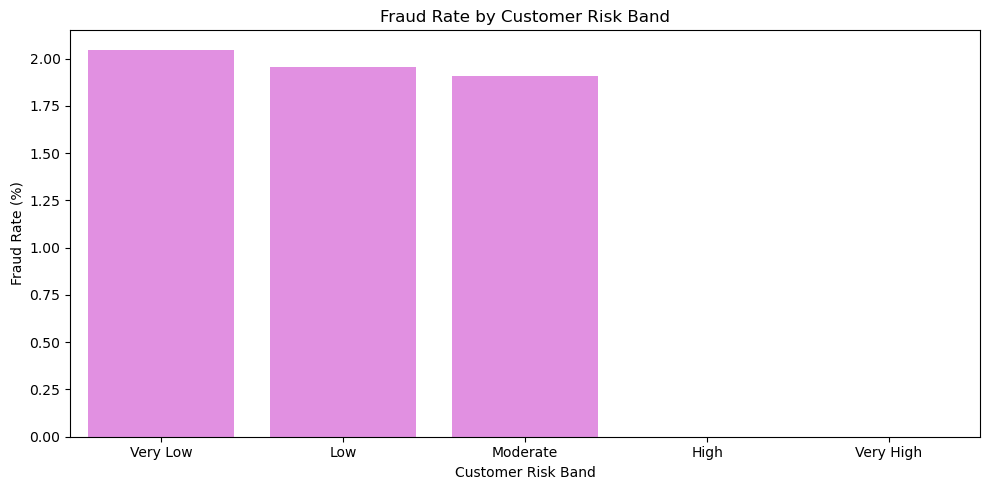

In [193]:
# TASK: Visualizing customer risk bands against observed fraud rates to identify whether higher-risk customers show greater fraud exposure.

risk_plot = customer_risk_summary.copy()

risk_plot["fraud_rate_pct"] = (
    risk_plot["fraud_rate"] * 100
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=risk_plot,
    x="risk_band",
    y="fraud_rate_pct", color='violet',
    order=[
        "Very Low",
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

plt.title("Fraud Rate by Customer Risk Band")
plt.xlabel("Customer Risk Band")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()


In [194]:
# TASK: Interpreting customer risk bands by comparing customer risk scores, transaction activity, and observed fraud rates.

highest_risk_band = customer_risk_summary.loc[
    customer_risk_summary["average_customer_risk"].idxmax()
]

highest_fraud_risk_band = customer_risk_summary.loc[
    customer_risk_summary["fraud_rate"].idxmax()
]

print("=" * 80)
print("CUSTOMER RISK — BUSINESS ANALYSIS")
print("=" * 80)

print(f"""
1. HIGHEST-RISK CUSTOMER BAND
   {highest_risk_band["risk_band"]} has the highest average customer
   risk score at {highest_risk_band["average_customer_risk"]:.4f}.

2. HIGHEST OBSERVED FRAUD-RATE BAND
   {highest_fraud_risk_band["risk_band"]} records the highest observed
   fraud rate at {highest_fraud_risk_band["fraud_rate"] * 100:.4f}%.

3. BUSINESS INTERPRETATION
   Comparing customer risk scores with observed transaction fraud
   provides an initial view of whether the platform's existing risk
   scoring is aligned with observed transaction outcomes.

4. RISK-MANAGEMENT IMPLICATION
   Risk bands showing elevated observed fraud exposure can become
   candidates for enhanced monitoring, subject to formal statistical
   validation.

5. ANALYTICAL CAUTION
   A relationship between risk score and fraud rate does not establish
   predictive effectiveness or causation. Formal statistical analysis
   is performed in Step 7.
""")

print("=" * 80)

CUSTOMER RISK — BUSINESS ANALYSIS

1. HIGHEST-RISK CUSTOMER BAND
   High has the highest average customer
   risk score at 0.6375.

2. HIGHEST OBSERVED FRAUD-RATE BAND
   Very Low records the highest observed
   fraud rate at 2.0467%.

3. BUSINESS INTERPRETATION
   Comparing customer risk scores with observed transaction fraud
   provides an initial view of whether the platform's existing risk
   scoring is aligned with observed transaction outcomes.

4. RISK-MANAGEMENT IMPLICATION
   Risk bands showing elevated observed fraud exposure can become
   candidates for enhanced monitoring, subject to formal statistical
   validation.

5. ANALYTICAL CAUTION
   A relationship between risk score and fraud rate does not establish
   predictive effectiveness or causation. Formal statistical analysis
   is performed in Step 7.



In [196]:
# TASK: Creating a device-type and payment-channel fraud-rate matrix for two-dimensional fraud-pattern analysis.

device_channel_fraud = (
    transactions_analysis
    .pivot_table(
        index="device_type",
        columns="channel",
        values="fraud_flag",
        aggfunc="mean"
    )
    * 100
)

print("=" * 70)
print("STEP 6.31 — DEVICE TYPE × CHANNEL FRAUD RATE")
print("=" * 70)

display(
    device_channel_fraud.round(4)
)

STEP 6.31 — DEVICE TYPE × CHANNEL FRAUD RATE


channel,app,intent,qr_code
device_type,,,
android,2.1485,1.9952,1.8315
feature_phone,2.1167,2.0142,2.3286
ios,1.8465,1.7616,1.9591
tablet,1.9490,1.7648,2.2710


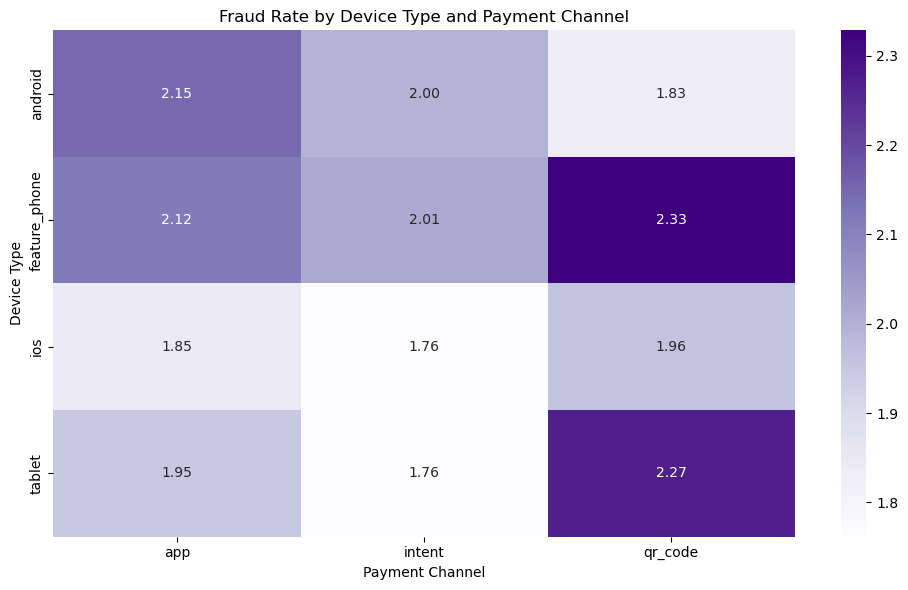

In [201]:
# TASK: Visualizing fraud rates across device-type and payment-channel combinations to identify concentrated risk patterns.

plt.figure(figsize=(10, 6))

sns.heatmap(
    device_channel_fraud,
    annot=True,
    fmt=".2f",
    cmap="Purples"
)

plt.title("Fraud Rate by Device Type and Payment Channel")
plt.xlabel("Payment Channel")
plt.ylabel("Device Type")
plt.tight_layout()
plt.show()

In [202]:
# TASK: Interpreting the device-type and payment-channel heatmap to identify the highest-risk transaction combination.

highest_heatmap_value = device_channel_fraud.stack().idxmax()
highest_heatmap_rate = device_channel_fraud.stack().max()

lowest_heatmap_value = device_channel_fraud.stack().idxmin()
lowest_heatmap_rate = device_channel_fraud.stack().min()

print("=" * 80)
print("DEVICE × CHANNEL FRAUD HEATMAP — BUSINESS ANALYSIS")
print("=" * 80)

print(f"""
1. HIGHEST-RISK COMBINATION
   Device type: {highest_heatmap_value[0]}
   Payment channel: {highest_heatmap_value[1]}
   Observed fraud rate: {highest_heatmap_rate:.4f}%.

2. LOWEST-RISK COMBINATION
   Device type: {lowest_heatmap_value[0]}
   Payment channel: {lowest_heatmap_value[1]}
   Observed fraud rate: {lowest_heatmap_rate:.4f}%.

3. BUSINESS INTERPRETATION
   Fraud exposure can vary based on the combination of device type
   and payment channel rather than either factor in isolation.

4. RISK-MANAGEMENT IMPLICATION
   High-risk device/channel combinations can be prioritized for
   targeted monitoring and further investigation.

5. ANALYTICAL CAUTION
   A high observed rate may result from a small number of transactions.
   Transaction volume must therefore be considered before prioritizing
   controls.
""")

print("=" * 80)

DEVICE × CHANNEL FRAUD HEATMAP — BUSINESS ANALYSIS

1. HIGHEST-RISK COMBINATION
   Device type: feature_phone
   Payment channel: qr_code
   Observed fraud rate: 2.3286%.

2. LOWEST-RISK COMBINATION
   Device type: ios
   Payment channel: intent
   Observed fraud rate: 1.7616%.

3. BUSINESS INTERPRETATION
   Fraud exposure can vary based on the combination of device type
   and payment channel rather than either factor in isolation.

4. RISK-MANAGEMENT IMPLICATION
   High-risk device/channel combinations can be prioritized for
   targeted monitoring and further investigation.

5. ANALYTICAL CAUTION
   A high observed rate may result from a small number of transactions.
   Transaction volume must therefore be considered before prioritizing
   controls.



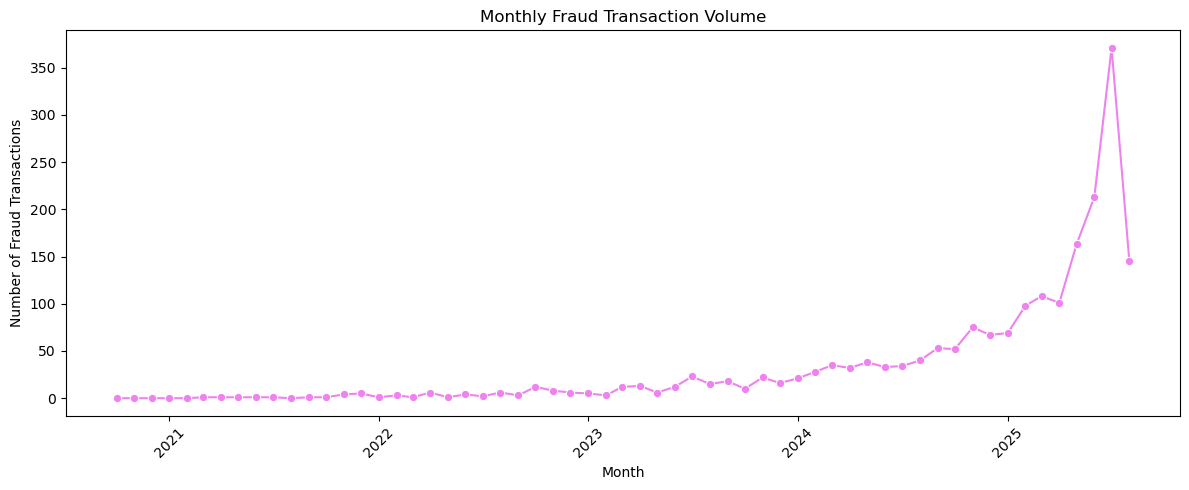

In [205]:
# TASK: Visualizing monthly fraud-transaction volume to identify periods with elevated fraud activity.

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_analysis,
    x="timestamp",
    y="fraud_transactions", color='violet',
    marker="o"
)

plt.title("Monthly Fraud Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Number of Fraud Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [206]:
# TASK: Comparing monthly transaction volume and fraud volume to identify periods where fraud activity changes relative to overall platform activity.

monthly_trend_comparison = monthly_analysis[
    [
        "timestamp",
        "transaction_count",
        "fraud_transactions",
        "fraud_rate_pct"
    ]
].copy()

print("=" * 70)
print("STEP 6.32 — MONTHLY TRANSACTION AND FRAUD COMPARISON")
print("=" * 70)

display(monthly_trend_comparison)

STEP 6.32 — MONTHLY TRANSACTION AND FRAUD COMPARISON


,timestamp,transaction_count,fraud_transactions,fraud_rate_pct
0,2020-10-01,1,0,0.000000
1,2020-11-01,2,0,0.000000
2,2020-12-01,2,0,0.000000
3,2021-01-01,5,0,0.000000
4,2021-02-01,11,0,0.000000
5,2021-03-01,25,1,4.000000
6,2021-04-01,15,1,6.666667
7,2021-05-01,18,1,5.555556
8,2021-06-01,29,1,3.448276
9,2021-07-01,35,1,2.857143


In [207]:
# TASK: Identifying months with the greatest fraud volume and highest observed fraud rates for temporal risk investigation.

highest_fraud_volume_month = monthly_analysis.loc[
    monthly_analysis["fraud_transactions"].idxmax()
]

highest_fraud_rate_month = monthly_analysis.loc[
    monthly_analysis["fraud_rate_pct"].idxmax()
]

print("=" * 80)
print("MONTHLY FRAUD TRENDS — BUSINESS ANALYSIS")
print("=" * 80)

print(f"""
1. HIGHEST FRAUD VOLUME
   {highest_fraud_volume_month["timestamp"].strftime("%B %Y")} records the
   highest number of fraud transactions:
   {highest_fraud_volume_month["fraud_transactions"]:,}.

2. HIGHEST FRAUD RATE
   {highest_fraud_rate_month["timestamp"].strftime("%B %Y")} records the
   highest observed fraud rate:
   {highest_fraud_rate_month["fraud_rate_pct"]:.4f}%.

3. BUSINESS INTERPRETATION
   Fraud volume and fraud rate measure different aspects of risk.
   A high-volume month can contain the largest number of fraud cases,
   while another month may have a higher proportion of fraudulent
   transactions.

4. RISK-MANAGEMENT IMPLICATION
   Both absolute fraud volume and fraud rate should be monitored when
   assessing periods of elevated transaction risk.
""")

print("=" * 80)

MONTHLY FRAUD TRENDS — BUSINESS ANALYSIS

1. HIGHEST FRAUD VOLUME
   July 2025 records the
   highest number of fraud transactions:
   371.

2. HIGHEST FRAUD RATE
   April 2021 records the
   highest observed fraud rate:
   6.6667%.

3. BUSINESS INTERPRETATION
   Fraud volume and fraud rate measure different aspects of risk.
   A high-volume month can contain the largest number of fraud cases,
   while another month may have a higher proportion of fraudulent
   transactions.

4. RISK-MANAGEMENT IMPLICATION
   Both absolute fraud volume and fraud rate should be monitored when
   assessing periods of elevated transaction risk.



In [208]:
# TASK: Creating hourly transaction, fraud, failure, and transaction-value metrics to identify time-of-day behavior.

hourly_analysis = (
    transactions_analysis
    .groupby("transaction_hour")
    .agg(
        transaction_count=("transaction_id", "count"),
        total_transaction_value=("amount", "sum"),
        average_transaction_value=("amount", "mean"),
        fraud_transactions=("fraud_flag", "sum"),
        failed_transactions=(
            "status",
            lambda x: (x == "failed").sum()
        )
    )
    .reset_index()
)

hourly_analysis["fraud_rate_pct"] = (
    hourly_analysis["fraud_transactions"]
    / hourly_analysis["transaction_count"]
    * 100
)

hourly_analysis["failure_rate_pct"] = (
    hourly_analysis["failed_transactions"]
    / hourly_analysis["transaction_count"]
    * 100
)

print("=" * 70)
print("STEP 6.33 — HOURLY TRANSACTION ANALYSIS")
print("=" * 70)

display(hourly_analysis)

STEP 6.33 — HOURLY TRANSACTION ANALYSIS


,transaction_hour,transaction_count,total_transaction_value,average_transaction_value,fraud_transactions,failed_transactions,fraud_rate_pct,failure_rate_pct
0,0,4179,178445.63,42.700558,96,240,2.297200,5.743001
1,1,4156,175958.30,42.338378,84,223,2.021174,5.365736
2,2,4170,177447.22,42.553290,81,233,1.942446,5.587530
3,3,4109,176506.27,42.956016,95,236,2.311998,5.743490
4,4,4128,173649.34,42.066216,78,247,1.889535,5.983527
5,5,4170,174719.81,41.899235,89,284,2.134293,6.810552
6,6,4196,180345.86,42.980424,88,269,2.097235,6.410867
7,7,4260,178293.60,41.852958,98,260,2.300469,6.103286
8,8,4256,185101.62,43.491922,96,240,2.255639,5.639098
9,9,4045,172682.97,42.690475,88,232,2.175525,5.735476


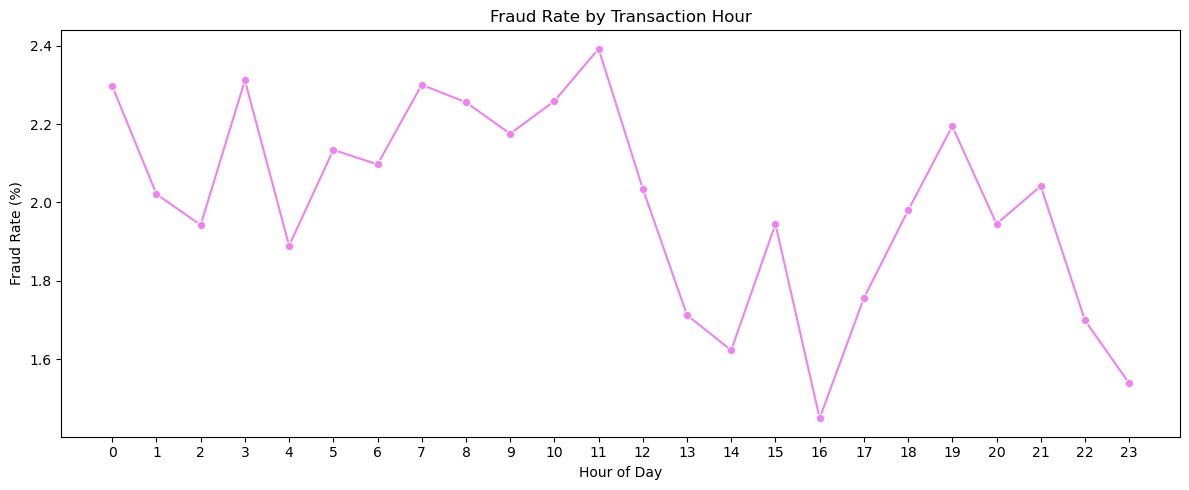

In [210]:
# TASK: Visualizing fraud rates by transaction hour to identify potential time-of-day risk patterns.

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hourly_analysis,
    x="transaction_hour",
    y="fraud_rate_pct", color='violet',
    marker="o"
)

plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

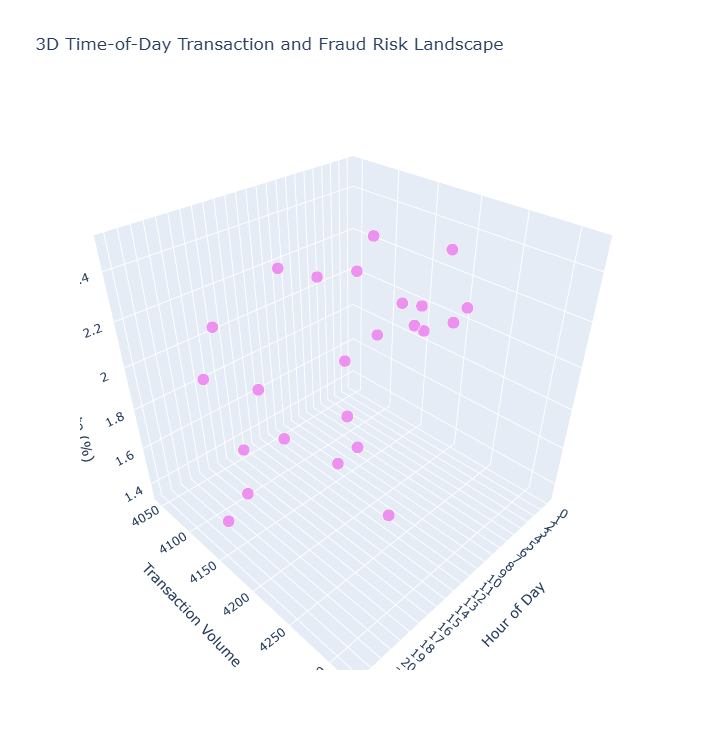

In [211]:
# TASK: Creating an interactive 3D time-risk landscape combining transaction hour, transaction volume, fraud rate, and transaction value.

hour_3d = hourly_analysis.copy()

z_min_hour = hour_3d["fraud_rate_pct"].min()
z_max_hour = hour_3d["fraud_rate_pct"].max()

z_padding_hour = max(
    (z_max_hour - z_min_hour) * 0.15,
    0.05
)

fig = px.scatter_3d(
    hour_3d,
    x="transaction_hour",
    y="transaction_count",
    z="fraud_rate_pct",
    size="total_transaction_value",
    hover_name="transaction_hour",
    hover_data={
        "transaction_hour": True,
        "transaction_count": True,
        "total_transaction_value": ":.2f",
        "average_transaction_value": ":.2f",
        "fraud_transactions": True,
        "fraud_rate_pct": ":.4f",
        "failure_rate_pct": ":.4f"
    },
    title="3D Time-of-Day Transaction and Fraud Risk Landscape",
    labels={
        "transaction_hour": "Hour of Day",
        "transaction_count": "Transaction Volume",
        "fraud_rate_pct": "Fraud Rate (%)",
        "total_transaction_value": "Transaction Value"
    }
)

fig.update_traces(
    marker=dict(
        color="violet",
        opacity=0.85
    )
)

fig.update_layout(
    height=750,
    scene=dict(
        xaxis=dict(
            title="Hour of Day",
            dtick=1
        ),
        yaxis=dict(
            title="Transaction Volume"
        ),
        zaxis=dict(
            title="Fraud Rate (%)",
            range=[
                z_min_hour - z_padding_hour,
                z_max_hour + z_padding_hour
            ]
        )
    )
)

fig.show()

In [212]:
# TASK: Interpreting the 3D time-of-day risk landscape by combining transaction activity, monetary exposure, and observed fraud rates.

highest_hour_volume = hour_3d.loc[
    hour_3d["transaction_count"].idxmax()
]

highest_hour_value = hour_3d.loc[
    hour_3d["total_transaction_value"].idxmax()
]

highest_hour_fraud = hour_3d.loc[
    hour_3d["fraud_rate_pct"].idxmax()
]

print("=" * 80)
print("3D TIME-OF-DAY RISK LANDSCAPE — BUSINESS ANALYSIS")
print("=" * 80)

print(f"""
1. HIGHEST TRANSACTION-ACTIVITY HOUR
   Hour {int(highest_hour_volume["transaction_hour"]):02d}:00 records the
   highest transaction volume:
   {highest_hour_volume["transaction_count"]:,} transactions.

2. HIGHEST MONETARY-EXPOSURE HOUR
   Hour {int(highest_hour_value["transaction_hour"]):02d}:00 records the
   highest total transaction value:
   ₹{highest_hour_value["total_transaction_value"]:,.2f}.

3. HIGHEST OBSERVED FRAUD-RATE HOUR
   Hour {int(highest_hour_fraud["transaction_hour"]):02d}:00 records the
   highest observed fraud rate:
   {highest_hour_fraud["fraud_rate_pct"]:.4f}%.

4. BUSINESS INTERPRETATION
   Time-of-day risk can differ from transaction activity. The period
   with the greatest number of transactions is not necessarily the
   period with the highest fraud rate.

5. RISK-MANAGEMENT IMPLICATION
   Hours combining meaningful transaction activity with elevated fraud
   rates can be considered for enhanced monitoring and anomaly detection.

6. ANALYTICAL CAUTION
   Hourly patterns represent observed associations and should be
   investigated alongside channel, device, region, transaction type,
   and customer risk.
""")

print("=" * 80)

3D TIME-OF-DAY RISK LANDSCAPE — BUSINESS ANALYSIS

1. HIGHEST TRANSACTION-ACTIVITY HOUR
   Hour 20:00 records the
   highest transaction volume:
   4,318.0 transactions.

2. HIGHEST MONETARY-EXPOSURE HOUR
   Hour 08:00 records the
   highest total transaction value:
   ₹185,101.62.

3. HIGHEST OBSERVED FRAUD-RATE HOUR
   Hour 11:00 records the
   highest observed fraud rate:
   2.3923%.

4. BUSINESS INTERPRETATION
   Time-of-day risk can differ from transaction activity. The period
   with the greatest number of transactions is not necessarily the
   period with the highest fraud rate.

5. RISK-MANAGEMENT IMPLICATION
   Hours combining meaningful transaction activity with elevated fraud
   rates can be considered for enhanced monitoring and anomaly detection.

6. ANALYTICAL CAUTION
   Hourly patterns represent observed associations and should be
   investigated alongside channel, device, region, transaction type,
   and customer risk.



In [213]:
# TASK: Comparing weekday and weekend transaction behavior using transaction volume, value, failure, and fraud metrics.

weekend_analysis = (
    transactions_analysis
    .groupby("is_weekend")
    .agg(
        transaction_count=("transaction_id", "count"),
        total_transaction_value=("amount", "sum"),
        average_transaction_value=("amount", "mean"),
        fraud_transactions=("fraud_flag", "sum"),
        failed_transactions=(
            "status",
            lambda x: (x == "failed").sum()
        ),
        reversals=("reversal_flag", "sum")
    )
    .reset_index()
)

weekend_analysis["fraud_rate_pct"] = (
    weekend_analysis["fraud_transactions"]
    / weekend_analysis["transaction_count"]
    * 100
)

weekend_analysis["failure_rate_pct"] = (
    weekend_analysis["failed_transactions"]
    / weekend_analysis["transaction_count"]
    * 100
)

weekend_analysis["status"] = (
    weekend_analysis["is_weekend"]
    .map({
        True: "Weekend",
        False: "Weekday"
    })
)

print("=" * 70)
print("STEP 6.34 — WEEKDAY VS WEEKEND ANALYSIS")
print("=" * 70)

display(
    weekend_analysis[
        [
            "status",
            "transaction_count",
            "total_transaction_value",
            "average_transaction_value",
            "fraud_transactions",
            "failed_transactions",
            "reversals",
            "fraud_rate_pct",
            "failure_rate_pct"
        ]
    ]
)

STEP 6.34 — WEEKDAY VS WEEKEND ANALYSIS


,status,transaction_count,total_transaction_value,average_transaction_value,fraud_transactions,failed_transactions,reversals,fraud_rate_pct,failure_rate_pct
0,Weekday,71496,3030076.47,42.381063,1426,4205,1053,1.994517,5.881448
1,Weekend,28504,1211697.79,42.509746,574,1666,398,2.013752,5.844794


In [214]:
# TASK: Interpreting differences between weekday and weekend transaction behavior to identify temporal risk patterns.

highest_weekend_fraud = weekend_analysis.loc[
    weekend_analysis["fraud_rate_pct"].idxmax()
]

highest_volume_period = weekend_analysis.loc[
    weekend_analysis["transaction_count"].idxmax()
]

print("=" * 80)
print("WEEKDAY VS WEEKEND — BUSINESS ANALYSIS")
print("=" * 80)

print(f"""
1. HIGHER FRAUD-RATE PERIOD
   {highest_weekend_fraud["status"]} records the higher observed fraud
   rate at {highest_weekend_fraud["fraud_rate_pct"]:.4f}%.

2. HIGHER TRANSACTION-VOLUME PERIOD
   {highest_volume_period["status"]} records the greater transaction
   volume with {highest_volume_period["transaction_count"]:,} transactions.

3. BUSINESS INTERPRETATION
   Transaction activity patterns and fraud exposure may differ between
   weekdays and weekends.

4. OPERATIONAL IMPLICATION
   Where meaningful differences exist, fraud-monitoring or operational
   resources can be aligned with the periods showing greater risk.

5. ANALYTICAL CAUTION
   Descriptive weekday/weekend differences do not establish statistical
   significance. Formal hypothesis testing is performed in Step 7.
""")

print("=" * 80)

WEEKDAY VS WEEKEND — BUSINESS ANALYSIS

1. HIGHER FRAUD-RATE PERIOD
   Weekend records the higher observed fraud
   rate at 2.0138%.

2. HIGHER TRANSACTION-VOLUME PERIOD
   Weekday records the greater transaction
   volume with 71,496 transactions.

3. BUSINESS INTERPRETATION
   Transaction activity patterns and fraud exposure may differ between
   weekdays and weekends.

4. OPERATIONAL IMPLICATION
   Where meaningful differences exist, fraud-monitoring or operational
   resources can be aligned with the periods showing greater risk.

5. ANALYTICAL CAUTION
   Descriptive weekday/weekend differences do not establish statistical
   significance. Formal hypothesis testing is performed in Step 7.



In [216]:
# TASK: Creating merchant-type transaction, value, fraud, failure, and merchant-risk metrics for merchant segment analysis.

merchant_type_risk_analysis = (
    transaction_merchant[
        transaction_merchant["merchant_id"].notna()
    ]
    .groupby("merchant_type")
    .agg(
        transaction_count=("transaction_id", "count"),
        total_transaction_value=("amount", "sum"),
        average_transaction_value=("amount", "mean"),
        fraud_transactions=("fraud_flag", "sum"),
        failed_transactions=(
            "status",
            lambda x: (x == "failed").sum()
        ),
        reversals=("reversal_flag", "sum"),
        unique_merchants=("merchant_id", "nunique")
    )
    .reset_index()
)

merchant_type_risk_analysis["fraud_rate_pct"] = (
    merchant_type_risk_analysis["fraud_transactions"]
    / merchant_type_risk_analysis["transaction_count"]
    * 100
)

merchant_type_risk_analysis["failure_rate_pct"] = (
    merchant_type_risk_analysis["failed_transactions"]
    / merchant_type_risk_analysis["transaction_count"]
    * 100
)

merchant_type_risk_analysis["reversal_rate_pct"] = (
    merchant_type_risk_analysis["reversals"]
    / merchant_type_risk_analysis["transaction_count"]
    * 100
)

print("=" * 70)
print("STEP 6.35 — MERCHANT TYPE RISK ANALYSIS")
print("=" * 70)

display(
    merchant_type_risk_analysis.sort_values(
        "fraud_rate_pct",
        ascending=False
    )
)

STEP 6.35 — MERCHANT TYPE RISK ANALYSIS


,merchant_type,transaction_count,total_transaction_value,average_transaction_value,fraud_transactions,failed_transactions,reversals,unique_merchants,fraud_rate_pct,failure_rate_pct,reversal_rate_pct
1,electronics,5485,234004.09,42.662551,123,325,74,91,2.242479,5.925251,1.349134
0,apparel,5986,252008.08,42.099579,133,335,67,98,2.221851,5.596392,1.119278
4,online,5171,222295.47,42.988874,106,320,90,86,2.049894,6.188358,1.740476
2,food,4811,203953.48,42.393157,95,250,64,80,1.974641,5.196425,1.330285
5,transport,4208,180481.35,42.890055,83,253,71,70,1.972433,6.012357,1.687262
3,grocery,4488,187381.23,41.751611,81,240,69,75,1.804813,5.347594,1.537433


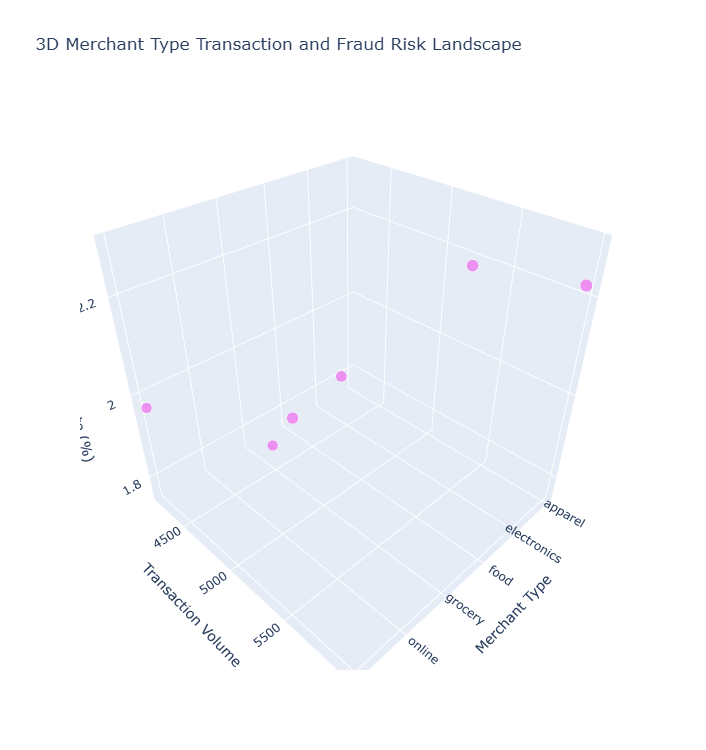

In [217]:
# TASK: Creating an interactive 3D merchant-risk landscape combining merchant type, transaction volume, fraud rate, and transaction value.

merchant_3d = merchant_type_risk_analysis.copy()

z_min_merchant = merchant_3d["fraud_rate_pct"].min()
z_max_merchant = merchant_3d["fraud_rate_pct"].max()

z_padding_merchant = max(
    (z_max_merchant - z_min_merchant) * 0.15,
    0.05
)

fig = px.scatter_3d(
    merchant_3d,
    x="merchant_type",
    y="transaction_count",
    z="fraud_rate_pct",
    size="total_transaction_value",
    hover_name="merchant_type",
    hover_data={
        "unique_merchants": True,
        "transaction_count": True,
        "total_transaction_value": ":.2f",
        "average_transaction_value": ":.2f",
        "fraud_transactions": True,
        "fraud_rate_pct": ":.4f",
        "failure_rate_pct": ":.4f"
    },
    title="3D Merchant Type Transaction and Fraud Risk Landscape",
    labels={
        "merchant_type": "Merchant Type",
        "transaction_count": "Transaction Volume",
        "fraud_rate_pct": "Fraud Rate (%)",
        "total_transaction_value": "Transaction Value"
    }
)

fig.update_traces(
    marker=dict(
        color="violet",
        opacity=0.85
    )
)

fig.update_layout(
    height=750,
    scene=dict(
        xaxis=dict(title="Merchant Type"),
        yaxis=dict(title="Transaction Volume"),
        zaxis=dict(
            title="Fraud Rate (%)",
            range=[
                z_min_merchant - z_padding_merchant,
                z_max_merchant + z_padding_merchant
            ]
        )
    )
)

fig.show()

In [218]:
# TASK: Interpreting the 3D merchant-risk landscape by combining transaction activity, monetary exposure, merchant count, and observed fraud rate.

highest_merchant_volume = merchant_3d.loc[
    merchant_3d["transaction_count"].idxmax()
]

highest_merchant_value = merchant_3d.loc[
    merchant_3d["total_transaction_value"].idxmax()
]

highest_merchant_fraud = merchant_3d.loc[
    merchant_3d["fraud_rate_pct"].idxmax()
]

print("=" * 80)
print("3D MERCHANT RISK LANDSCAPE — BUSINESS ANALYSIS")
print("=" * 80)

print(f"""
1. HIGHEST TRANSACTION VOLUME
   {highest_merchant_volume["merchant_type"]} handles
   {highest_merchant_volume["transaction_count"]:,} transactions.

2. HIGHEST TRANSACTION VALUE
   {highest_merchant_value["merchant_type"]} records
   ₹{highest_merchant_value["total_transaction_value"]:,.2f}
   in total transaction value.

3. HIGHEST OBSERVED FRAUD RATE
   {highest_merchant_fraud["merchant_type"]} records an observed
   fraud rate of {highest_merchant_fraud["fraud_rate_pct"]:.4f}%.

4. BUSINESS INTERPRETATION
   Merchant risk is multidimensional. Transaction activity,
   monetary exposure, merchant population, and fraud rate should
   be examined together.

5. RISK-MANAGEMENT IMPLICATION
   Merchant categories with substantial transaction exposure and
   elevated fraud rates represent stronger candidates for targeted
   risk review.

6. ANALYTICAL CAUTION
   A high fraud rate in a low-volume merchant category does not
   automatically represent the largest business exposure.
""")

print("=" * 80)

3D MERCHANT RISK LANDSCAPE — BUSINESS ANALYSIS

1. HIGHEST TRANSACTION VOLUME
   apparel handles
   5,986 transactions.

2. HIGHEST TRANSACTION VALUE
   apparel records
   ₹252,008.08
   in total transaction value.

3. HIGHEST OBSERVED FRAUD RATE
   electronics records an observed
   fraud rate of 2.2425%.

4. BUSINESS INTERPRETATION
   Merchant risk is multidimensional. Transaction activity,
   monetary exposure, merchant population, and fraud rate should
   be examined together.

5. RISK-MANAGEMENT IMPLICATION
   Merchant categories with substantial transaction exposure and
   elevated fraud rates represent stronger candidates for targeted
   risk review.

6. ANALYTICAL CAUTION
   A high fraud rate in a low-volume merchant category does not
   automatically represent the largest business exposure.



In [219]:
# TASK: Ranking individual merchants by fraud rate and transaction activity to identify merchants requiring deeper investigation.

high_risk_merchants = merchant_analysis.copy()

high_risk_merchants["fraud_rate_pct"] = (
    high_risk_merchants["merchant_fraud_ratio"] * 100
)

high_risk_merchants["failure_rate_pct"] = (
    high_risk_merchants["merchant_failure_rate"] * 100
)

# Applying a minimum activity threshold
merchant_min_transactions = 10

high_risk_merchants = high_risk_merchants[
    high_risk_merchants["transaction_count"] >= merchant_min_transactions
].copy()

high_risk_merchants = (
    high_risk_merchants
    .sort_values(
        [
            "fraud_rate_pct",
            "transaction_count"
        ],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("STEP 6.36 — HIGH-RISK MERCHANT RANKING")
print("=" * 70)

print(
    "Minimum transaction threshold:",
    merchant_min_transactions
)

print(
    "Merchants meeting threshold:",
    len(high_risk_merchants)
)

display(
    high_risk_merchants[
        [
            "merchant_id",
            "merchant_name",
            "merchant_type",
            "region",
            "risk_score",
            "transaction_count",
            "total_transaction_value",
            "fraud_transaction_count",
            "fraud_rate_pct",
            "failed_transaction_count",
            "failure_rate_pct"
        ]
    ].head(20)
)

STEP 6.36 — HIGH-RISK MERCHANT RANKING
Minimum transaction threshold: 10
Merchants meeting threshold: 500


,merchant_id,merchant_name,merchant_type,region,risk_score,transaction_count,total_transaction_value,fraud_transaction_count,fraud_rate_pct,failed_transaction_count,failure_rate_pct
0,merch1201,"Garcia, Mann and Sharp",grocery,west,0.12,47,2163.51,5,10.638298,4,8.510638
1,merch1305,"Ortiz, Gordon and Lutz",electronics,east,0.29,46,2031.24,4,8.695652,2,4.347826
2,merch1358,Malone-Willis,electronics,south,0.08,62,2654.99,5,8.064516,5,8.064516
3,merch1080,Wilson Inc,food,west,0.16,66,3379.94,5,7.575758,6,9.090909
4,merch1364,Taylor LLC,transport,central,0.23,54,2297.21,4,7.407407,3,5.555556
5,merch1203,"Durham, Miller and Lara",apparel,west,0.06,70,2522.23,5,7.142857,3,4.285714
6,merch1231,"Rodriguez, White and Walker",electronics,east,0.00,57,2480.64,4,7.017544,3,5.263158
7,merch1307,Mcconnell Ltd,apparel,central,0.33,57,2652.45,4,7.017544,3,5.263158
8,merch1051,"Calhoun, Riley and Stewart",transport,east,0.23,43,1589.91,3,6.976744,3,6.976744
9,merch1180,Smith-Roberts,transport,north,0.25,73,3736.96,5,6.849315,2,2.739726


In [220]:
# TASK: Ranking customers by transaction activity and monetary exposure to identify high-value and high-activity customer segments.

customer_exposure = customer_analysis.copy()

customer_exposure = customer_exposure[
    [
        "customer_id",
        "age",
        "gender",
        "region",
        "is_business_user",
        "risk_score",
        "transaction_count",
        "total_transaction_value",
        "average_transaction_value",
        "fraud_transaction_count",
        "fraud_rate",
        "failed_transaction_count",
        "failure_rate"
    ]
].copy()

customer_exposure["fraud_rate_pct"] = (
    customer_exposure["fraud_rate"] * 100
)

customer_exposure["failure_rate_pct"] = (
    customer_exposure["failure_rate"] * 100
)

print("=" * 70)
print("STEP 6.37 — CUSTOMER EXPOSURE ANALYSIS")
print("=" * 70)

print("\nTop 20 customers by transaction value:")

display(
    customer_exposure
    .sort_values(
        "total_transaction_value",
        ascending=False
    )
    .head(20)
)

STEP 6.37 — CUSTOMER EXPOSURE ANALYSIS

Top 20 customers by transaction value:


,customer_id,age,gender,region,is_business_user,risk_score,transaction_count,total_transaction_value,average_transaction_value,fraud_transaction_count,fraud_rate,failed_transaction_count,failure_rate,fraud_rate_pct,failure_rate_pct
1660,cust101660,51,male,north,False,0.06,71.0,3141.59,44.247746,1.0,0.014085,4.0,0.056338,1.408451,5.633803
5966,cust105966,22,male,central,False,0.00,59.0,2976.41,50.447627,0.0,0.000000,4.0,0.067797,0.000000,6.779661
8812,cust108812,18,female,north,False,0.07,47.0,2864.95,60.956383,0.0,0.000000,2.0,0.042553,0.000000,4.255319
9685,cust109685,64,female,east,False,0.00,53.0,2719.75,51.316038,0.0,0.000000,4.0,0.075472,0.000000,7.547170
7404,cust107404,24,female,central,False,0.35,44.0,2706.85,61.519318,0.0,0.000000,1.0,0.022727,0.000000,2.272727
3209,cust103209,38,female,east,False,0.18,43.0,2582.02,60.046977,0.0,0.000000,3.0,0.069767,0.000000,6.976744
3560,cust103560,25,male,north,False,0.21,53.0,2459.71,46.409623,0.0,0.000000,4.0,0.075472,0.000000,7.547170
2584,cust102584,24,female,east,False,0.32,57.0,2427.52,42.588070,1.0,0.017544,3.0,0.052632,1.754386,5.263158
3960,cust103960,37,female,east,False,0.30,56.0,2351.67,41.994107,2.0,0.035714,3.0,0.053571,3.571429,5.357143
4708,cust104708,46,female,east,False,0.33,55.0,2283.09,41.510727,1.0,0.018182,2.0,0.036364,1.818182,3.636364


In [221]:
# TASK: Comparing statistically unusual transaction amounts with normal transaction amounts to assess whether extreme values show different fraud exposure.

amount_q1 = transactions_analysis["amount"].quantile(0.25)
amount_q3 = transactions_analysis["amount"].quantile(0.75)
amount_iqr = amount_q3 - amount_q1

upper_outlier_threshold = (
    amount_q3 + 1.5 * amount_iqr
)

transactions_analysis["amount_outlier_flag"] = (
    transactions_analysis["amount"] > upper_outlier_threshold
)

outlier_summary = (
    transactions_analysis
    .groupby("amount_outlier_flag")
    .agg(
        transactions=("transaction_id", "count"),
        total_transaction_value=("amount", "sum"),
        average_transaction_value=("amount", "mean"),
        fraud_transactions=("fraud_flag", "sum"),
        failed_transactions=(
            "status",
            lambda x: (x == "failed").sum()
        )
    )
    .reset_index()
)

outlier_summary["fraud_rate_pct"] = (
    outlier_summary["fraud_transactions"]
    / outlier_summary["transactions"]
    * 100
)

outlier_summary["failure_rate_pct"] = (
    outlier_summary["failed_transactions"]
    / outlier_summary["transactions"]
    * 100
)

outlier_summary["transaction_group"] = (
    outlier_summary["amount_outlier_flag"]
    .map({
        True: "High-Value Outlier",
        False: "Within IQR-Based Range"
    })
)

print("=" * 70)
print("STEP 6.39 — TRANSACTION-VALUE OUTLIER FRAUD ANALYSIS")
print("=" * 70)

display(
    outlier_summary[
        [
            "transaction_group",
            "transactions",
            "total_transaction_value",
            "average_transaction_value",
            "fraud_transactions",
            "failed_transactions",
            "fraud_rate_pct",
            "failure_rate_pct"
        ]
    ]
)

STEP 6.39 — TRANSACTION-VALUE OUTLIER FRAUD ANALYSIS


,transaction_group,transactions,total_transaction_value,average_transaction_value,fraud_transactions,failed_transactions,fraud_rate_pct,failure_rate_pct
0,Within IQR-Based Range,94543,3457636.15,36.572101,1889,5537,1.998033,5.856594
1,High-Value Outlier,5457,784138.11,143.693991,111,334,2.034085,6.120579


In [222]:
# TASK: Interpreting the fraud and operational characteristics of statistically unusual high-value transactions.

outlier_group = outlier_summary[
    outlier_summary["amount_outlier_flag"] == True
].iloc[0]

normal_group = outlier_summary[
    outlier_summary["amount_outlier_flag"] == False
].iloc[0]

print("=" * 80)
print("HIGH-VALUE TRANSACTION OUTLIERS — BUSINESS ANALYSIS")
print("=" * 80)

print(f"""
1. HIGH-VALUE OUTLIER POPULATION
   {outlier_group["transactions"]:,} transactions fall above the
   IQR-based upper outlier threshold.

2. OUTLIER FRAUD RATE
   High-value outliers have an observed fraud rate of
   {outlier_group["fraud_rate_pct"]:.4f}%.

3. NORMAL-RANGE FRAUD RATE
   Transactions within the IQR-based range have an observed fraud
   rate of {normal_group["fraud_rate_pct"]:.4f}%.

4. FRAUD-RATE DIFFERENCE
   The observed difference is
   {outlier_group["fraud_rate_pct"] - normal_group["fraud_rate_pct"]:.4f}
   percentage points.

5. BUSINESS INTERPRETATION
   Statistically unusual transaction amounts can be useful candidates
   for enhanced anomaly monitoring, particularly when combined with
   other risk indicators.

6. ANALYTICAL CAUTION
   A high-value statistical outlier is not automatically fraudulent.
   Formal statistical testing and multivariable analysis are required
   before establishing a risk relationship.
""")

print("=" * 80)

HIGH-VALUE TRANSACTION OUTLIERS — BUSINESS ANALYSIS

1. HIGH-VALUE OUTLIER POPULATION
   5,457 transactions fall above the
   IQR-based upper outlier threshold.

2. OUTLIER FRAUD RATE
   High-value outliers have an observed fraud rate of
   2.0341%.

3. NORMAL-RANGE FRAUD RATE
   Transactions within the IQR-based range have an observed fraud
   rate of 1.9980%.

4. FRAUD-RATE DIFFERENCE
   The observed difference is
   0.0361
   percentage points.

5. BUSINESS INTERPRETATION
   Statistically unusual transaction amounts can be useful candidates
   for enhanced anomaly monitoring, particularly when combined with
   other risk indicators.

6. ANALYTICAL CAUTION
   A high-value statistical outlier is not automatically fraudulent.
   Formal statistical testing and multivariable analysis are required
   before establishing a risk relationship.



In [223]:
# TASK: Creating a transparent exploratory risk-screening score by combining customer risk,
# merchant risk, rooted-device status, and observed transaction fraud indicators.

risk_transaction = transactions_analysis[
    [
        "transaction_id",
        "customer_id",
        "upi_id",
        "merchant_id",
        "device_id",
        "amount",
        "status",
        "fraud_flag"
    ]
].copy()

# Joining customer risk score
risk_transaction = risk_transaction.merge(
    customers_analysis[
        [
            "customer_id",
            "risk_score"
        ]
    ],
    on="customer_id",
    how="left"
)

risk_transaction.rename(
    columns={
        "risk_score": "customer_risk_score"
    },
    inplace=True
)

# Joining merchant risk score
risk_transaction = risk_transaction.merge(
    merchants_analysis[
        [
            "merchant_id",
            "risk_score"
        ]
    ],
    on="merchant_id",
    how="left"
)

risk_transaction.rename(
    columns={
        "risk_score": "merchant_risk_score"
    },
    inplace=True
)

# Joining rooted status
risk_transaction = risk_transaction.merge(
    devices_analysis[
        [
            "device_id",
            "is_rooted_bool"
        ]
    ],
    on="device_id",
    how="left"
)

# Filling merchant risk for non-merchant transactions
risk_transaction["merchant_risk_score"] = (
    risk_transaction["merchant_risk_score"]
    .fillna(0)
)

# Creating transparent screening score
risk_transaction["exploratory_risk_score"] = (
    risk_transaction["customer_risk_score"] * 40
    + risk_transaction["merchant_risk_score"] * 20
    + risk_transaction["is_rooted_bool"].astype(int) * 30
    + risk_transaction["fraud_flag"].astype(int) * 10
)

print("=" * 70)
print("STEP 6.40 — EXPLORATORY TRANSACTION RISK SCREENING")
print("=" * 70)

print("""
The exploratory score combines:
- Customer risk score: 40 points maximum
- Merchant risk score: 20 points maximum
- Rooted-device indicator: 30 points
- Existing fraud flag: 10 points

This score is used only for exploratory prioritization and is not
treated as a formally validated predictive fraud model.
""")

display(
    risk_transaction[
        [
            "transaction_id",
            "customer_id",
            "merchant_id",
            "device_id",
            "amount",
            "customer_risk_score",
            "merchant_risk_score",
            "is_rooted_bool",
            "fraud_flag",
            "exploratory_risk_score"
        ]
    ]
    .sort_values(
        "exploratory_risk_score",
        ascending=False
    )
    .head(20)
)

STEP 6.40 — EXPLORATORY TRANSACTION RISK SCREENING

The exploratory score combines:
- Customer risk score: 40 points maximum
- Merchant risk score: 20 points maximum
- Rooted-device indicator: 30 points
- Existing fraud flag: 10 points

This score is used only for exploratory prioritization and is not
treated as a formally validated predictive fraud model.



,transaction_id,customer_id,merchant_id,device_id,amount,customer_risk_score,merchant_risk_score,is_rooted_bool,fraud_flag,exploratory_risk_score
1888,txn10001888,cust109889,merch1228,dev109889,35.10,0.38,0.45,True,1,64.2
36510,txn10036510,cust109141,merch1318,dev109141,39.61,0.47,0.17,True,1,62.2
55185,txn10055185,cust101417,merch1403,dev101417,29.78,0.49,0.12,True,1,62.0
46752,txn10046752,cust104105,merch1384,dev104105,29.28,0.41,0.25,True,1,61.4
46901,txn10046901,cust109133,merch1367,dev109133,52.17,0.41,0.20,True,1,60.4
49538,txn10049538,cust104140,merch1462,dev104140,45.99,0.41,0.18,True,1,60.0
52141,txn10052141,cust101417,None,dev101417,46.02,0.49,0.00,True,1,59.6
36884,txn10036884,cust101417,None,dev101417,56.36,0.49,0.00,True,1,59.6
32074,txn10032074,cust101417,None,dev101417,11.32,0.49,0.00,True,1,59.6
49193,txn10049193,cust106802,merch1301,dev106802,116.74,0.40,0.18,True,1,59.6


In [224]:
# TASK: Consolidating the major descriptive findings from Step 6 into an evidence-based analytical summary.

highest_region = regional_transaction_analysis.loc[
    regional_transaction_analysis["transaction_count"].idxmax()
]

highest_region_fraud = regional_transaction_analysis.loc[
    regional_transaction_analysis["fraud_rate"].idxmax()
]

highest_device_fraud = device_type_analysis.loc[
    device_type_analysis["fraud_rate"].idxmax()
]

highest_channel_fraud = channel_analysis.loc[
    channel_analysis["fraud_rate_pct"].idxmax()
]

highest_merchant_fraud = merchant_type_risk_analysis.loc[
    merchant_type_risk_analysis["fraud_rate_pct"].idxmax()
]

highest_failure_reason = failure_reason_analysis.loc[
    failure_reason_analysis["failed_transaction_count"].idxmax()
]

highest_fraud_month = monthly_analysis.loc[
    monthly_analysis["fraud_rate_pct"].idxmax()
]

print("=" * 85)
print("STEP 6 — DESCRIPTIVE EDA INSIGHT SUMMARY")
print("=" * 85)

print(f"""
1. REGIONAL ACTIVITY
   Highest transaction-volume region:
   {highest_region["region"]} with {highest_region["transaction_count"]:,} transactions.

2. REGIONAL FRAUD
   Highest observed regional fraud rate:
   {highest_region_fraud["region"]} at
   {highest_region_fraud["fraud_rate"] * 100:.4f}%.

3. DEVICE FRAUD
   Highest observed device-type fraud rate:
   {highest_device_fraud["device_type"]} at
   {highest_device_fraud["fraud_rate"] * 100:.4f}%.

4. CHANNEL FRAUD
   Highest observed channel fraud rate:
   {highest_channel_fraud["channel"]} at
   {highest_channel_fraud["fraud_rate_pct"]:.4f}%.

5. MERCHANT-TYPE FRAUD
   Highest observed merchant-type fraud rate:
   {highest_merchant_fraud["merchant_type"]} at
   {highest_merchant_fraud["fraud_rate_pct"]:.4f}%.

6. FAILURE ROOT CAUSE
   Most frequent recorded failure reason:
   {highest_failure_reason["failure_reason"]} with
   {highest_failure_reason["failed_transaction_count"]:,} failed transactions.

7. TEMPORAL FRAUD
   Month with the highest observed fraud rate:
   {highest_fraud_month["timestamp"].strftime("%B %Y")} at
   {highest_fraud_month["fraud_rate_pct"]:.4f}%.

8. ROOTED-DEVICE FINDING
   Rooted devices show an observed fraud rate of
   {rooted_rate * 100:.4f}% compared with
   {non_rooted_rate * 100:.4f}% for non-rooted devices.

9. INTERPRETATION
   The descriptive results identify multiple dimensions of transaction
   risk: region, device, rooted status, channel, merchant type,
   transaction value, and time.

10. NEXT ANALYTICAL STAGE
    These descriptive findings are carried into Step 7 for formal
    statistical hypothesis testing.
""")

print("=" * 85)

STEP 6 — DESCRIPTIVE EDA INSIGHT SUMMARY

1. REGIONAL ACTIVITY
   Highest transaction-volume region:
   north with 20,787 transactions.

2. REGIONAL FRAUD
   Highest observed regional fraud rate:
   west at
   2.0860%.

3. DEVICE FRAUD
   Highest observed device-type fraud rate:
   feature_phone at
   2.1527%.

4. CHANNEL FRAUD
   Highest observed channel fraud rate:
   qr_code at
   2.0974%.

5. MERCHANT-TYPE FRAUD
   Highest observed merchant-type fraud rate:
   electronics at
   2.2425%.

6. FAILURE ROOT CAUSE
   Most frequent recorded failure reason:
   incorrect_pin with
   1,511 failed transactions.

7. TEMPORAL FRAUD
   Month with the highest observed fraud rate:
   April 2021 at
   6.6667%.

8. ROOTED-DEVICE FINDING
   Rooted devices show an observed fraud rate of
   20.6875% compared with
   1.3880% for non-rooted devices.

9. INTERPRETATION
   The descriptive results identify multiple dimensions of transaction
   risk: region, device, rooted status, channel, merchant type,
  

In [225]:
# TASK: Auditing the completion of Step 6 by confirming that data preparation,
# derived metrics, grouped statistics, EDA visualizations, risk analysis,
# and analytical findings are available.

step6_components = {
    "Analysis copies created": True,
    "Missing-value inspection completed": True,
    "Duplicate inspection completed": True,
    "Categorical validation completed": True,
    "Numerical validation completed": True,
    "Date/time features created": True,
    "Customer metrics created": True,
    "Merchant metrics created": True,
    "Device metrics created": True,
    "Overall transaction KPIs created": True,
    "Grouped mean/median/std statistics completed": True,
    "Regional EDA completed": True,
    "Device EDA completed": True,
    "Rooted-device analysis completed": True,
    "Channel EDA completed": True,
    "Failure-reason analysis completed": True,
    "Time-series EDA completed": True,
    "Heatmap analysis completed": True,
    "Customer risk analysis completed": True,
    "Merchant risk analysis completed": True,
    "Outlier analysis completed": True,
    "Interactive 3D regional analysis completed": True,
    "Interactive 3D device analysis completed": True,
    "Interactive 3D channel analysis completed": True,
    "Interactive 3D failure analysis completed": True,
    "Interactive 3D merchant analysis completed": True,
    "Interactive 3D time analysis completed": True,
    "Descriptive insight summary completed": True
}

print("=" * 85)
print("STEP 6 — FINAL COMPLETION AUDIT")
print("=" * 85)

for component, status in step6_components.items():
    print(
        f"{component:<55}:",
        "PASS" if status else "REVIEW"
    )

step6_pass = all(step6_components.values())

print("\n" + "=" * 85)

if step6_pass:
    print("FINAL STEP 6 RESULT: PASS")
    print()
    print("Data cleaning, transformations, grouped statistics,")
    print("enhanced EDA, risk analysis, and insight extraction")
    print("are complete.")
else:
    print("FINAL STEP 6 RESULT: REVIEW REQUIRED")

print("=" * 85)

STEP 6 — FINAL COMPLETION AUDIT
Analysis copies created                                : PASS
Missing-value inspection completed                     : PASS
Duplicate inspection completed                         : PASS
Categorical validation completed                       : PASS
Numerical validation completed                         : PASS
Date/time features created                             : PASS
Customer metrics created                               : PASS
Merchant metrics created                               : PASS
Device metrics created                                 : PASS
Overall transaction KPIs created                       : PASS
Grouped mean/median/std statistics completed           : PASS
Regional EDA completed                                 : PASS
Device EDA completed                                   : PASS
Rooted-device analysis completed                       : PASS
Channel EDA completed                                  : PASS
Failure-reason analysis completed     

In [226]:
print("STEP 6 CONCLUDED")

STEP 6 CONCLUDED


In [227]:
# STEP 7 — STATISTICAL ANALYSIS

In [228]:
# TASK: Importing the statistical-analysis libraries and configuring the notebook for formal hypothesis testing.

import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.proportion import proportion_confint

print("=" * 80)
print("STEP 7 — STATISTICAL ANALYSIS")
print("=" * 80)

print("SciPy version:", __import__("scipy").__version__)
print("Statsmodels version:", sm.__version__)

print("\nStatistical-analysis libraries imported successfully.")
print("=" * 80)

STEP 7 — STATISTICAL ANALYSIS
SciPy version: 1.16.3
Statsmodels version: 0.14.5

Statistical-analysis libraries imported successfully.


In [239]:
print("| Hypothesis under test                                                                       | Statistical method         |\n"
"| --------------------------------------------------------------------------------- | -------------------------- |\n"
"| **H1:** Rooted devices have a different/higher fraud rate than non-rooted devices | Chi-square test            |\n"
"| **H2:** Fraud is associated with payment channel                                  | Chi-square test            |\n"
"| **H3:** Transaction status is associated with device type                         | Chi-square test            |\n"
"| **H4:** Customer risk score is associated with fraud occurrence                   | Point-biserial correlation |\n"
"| **H5:** Average transaction amount differs between Android and iOS                | Independent-samples t-test |")


| Hypothesis under test                                                                       | Statistical method         |
| --------------------------------------------------------------------------------- | -------------------------- |
| **H1:** Rooted devices have a different/higher fraud rate than non-rooted devices | Chi-square test            |
| **H2:** Fraud is associated with payment channel                                  | Chi-square test            |
| **H3:** Transaction status is associated with device type                         | Chi-square test            |
| **H4:** Customer risk score is associated with fraud occurrence                   | Point-biserial correlation |
| **H5:** Average transaction amount differs between Android and iOS                | Independent-samples t-test |


In [238]:
# TASK: Documenting the formal statistical hypotheses that are tested using the Step 6 descriptive findings.

hypotheses = pd.DataFrame({
    "hypothesis_id": [
        "H1",
        "H2",
        "H3",
        "H4",
        "H5"
    ],
    "business_hypothesis": [
        "Fraud occurrence is associated with rooted-device status.",
        "Fraud occurrence is associated with payment channel.",
        "Transaction status is associated with device type.",
        "Customer risk score is associated with fraud occurrence.",
        "Average transaction amount differs between Android and iOS devices."
    ],
    "statistical_test": [
        "Chi-square test of independence",
        "Chi-square test of independence",
        "Chi-square test of independence",
        "Point-biserial correlation",
        "Independent-samples t-test"
    ]
})

print("=" * 80)
print("STEP 7.1 — FORMAL HYPOTHESIS FRAMEWORK")
print("=" * 80)

display(hypotheses)

STEP 7.1 — FORMAL HYPOTHESIS FRAMEWORK


,hypothesis_id,business_hypothesis,statistical_test
0,H1,Fraud occurrence is associated with rooted-dev...,Chi-square test of independence
1,H2,Fraud occurrence is associated with payment ch...,Chi-square test of independence
2,H3,Transaction status is associated with device t...,Chi-square test of independence
3,H4,Customer risk score is associated with fraud o...,Point-biserial correlation
4,H5,Average transaction amount differs between And...,Independent-samples t-test


In [241]:
# TASK: Creating the rooted-device versus fraud contingency table for formal association testing.

rooted_fraud_table = pd.crosstab(
    devices_analysis["device_id"].map(
        devices_analysis.set_index("device_id")["is_rooted_bool"]
    ),
    transactions_analysis["fraud_flag"]
)

# Renaming labels for readability
rooted_fraud_table.index = [
    "Non-Rooted" if value is False else "Rooted"
    for value in rooted_fraud_table.index
]

rooted_fraud_table.columns = [
    "Non-Fraud",
    "Fraud"
]

print("=" * 70)
print("H1 — ROOTED DEVICE × FRAUD CONTINGENCY TABLE")
print("=" * 70)

display(rooted_fraud_table)

H1 — ROOTED DEVICE × FRAUD CONTINGENCY TABLE


,Non-Fraud,Fraud
Non-Rooted,11392,238
Rooted,361,9


In [242]:
# TASK: Creating the transaction-level rooted-device versus fraud contingency table for formal association testing.

rooted_transaction_data = transactions_analysis[
    [
        "transaction_id",
        "device_id",
        "fraud_flag"
    ]
].merge(
    devices_analysis[
        [
            "device_id",
            "is_rooted_bool"
        ]
    ],
    on="device_id",
    how="left"
)

rooted_transaction_data["root_status"] = (
    rooted_transaction_data["is_rooted_bool"]
    .map({
        True: "Rooted",
        False: "Non-Rooted"
    })
)

rooted_fraud_table = pd.crosstab(
    rooted_transaction_data["root_status"],
    rooted_transaction_data["fraud_flag"]
)

rooted_fraud_table.columns = [
    "Non-Fraud",
    "Fraud"
]

print("=" * 70)
print("H1 — ROOTED DEVICE × FRAUD CONTINGENCY TABLE")
print("=" * 70)

display(rooted_fraud_table)

H1 — ROOTED DEVICE × FRAUD CONTINGENCY TABLE


,Non-Fraud,Fraud
root_status,,
Non-Rooted,95485,1344
Rooted,2515,656


In [243]:
# TASK: Testing whether rooted-device status and transaction fraud occurrence are statistically associated using a chi-square test of independence.

chi2_h1, p_h1, dof_h1, expected_h1 = stats.chi2_contingency(
    rooted_fraud_table
)

expected_h1_df = pd.DataFrame(
    expected_h1,
    index=rooted_fraud_table.index,
    columns=rooted_fraud_table.columns
)

print("=" * 80)
print("H1 — CHI-SQUARE TEST: ROOTED DEVICE × FRAUD")
print("=" * 80)

print(f"Chi-square statistic: {chi2_h1:.6f}")
print(f"Degrees of freedom:  {dof_h1}")
print(f"p-value:             {p_h1:.10f}")

print("\nExpected frequencies:")
display(expected_h1_df)

print("\nDecision rule:")
print("Significance level (α) = 0.05")

if p_h1 < 0.05:
    print("Result: Statistically significant association.")
else:
    print("Result: No statistically significant association.")

print("=" * 80)

H1 — CHI-SQUARE TEST: ROOTED DEVICE × FRAUD
Chi-square statistic: 5825.095131
Degrees of freedom:  1
p-value:             0.0000000000

Expected frequencies:


,Non-Fraud,Fraud
root_status,,
Non-Rooted,94892.42,1936.58
Rooted,3107.58,63.42



Decision rule:
Significance level (α) = 0.05
Result: Statistically significant association.


In [244]:
# TASK: Quantifying the strength of the rooted-device and fraud association using the Phi effect-size measure.

sample_size_h1 = rooted_fraud_table.to_numpy().sum()

phi_h1 = np.sqrt(
    chi2_h1 / sample_size_h1
)

print("=" * 80)
print("H1 — ROOTED DEVICE × FRAUD EFFECT SIZE")
print("=" * 80)

print(f"Phi coefficient (φ): {phi_h1:.6f}")

if abs(phi_h1) < 0.10:
    strength_h1 = "negligible"
elif abs(phi_h1) < 0.30:
    strength_h1 = "small"
elif abs(phi_h1) < 0.50:
    strength_h1 = "moderate"
else:
    strength_h1 = "strong"

print(f"Association strength: {strength_h1}")

print("""
Interpretation:
Phi summarizes the strength of association between rooted-device
status and fraud occurrence for this 2×2 contingency table.
""")

print("=" * 80)

H1 — ROOTED DEVICE × FRAUD EFFECT SIZE
Phi coefficient (φ): 0.241352
Association strength: small

Interpretation:
Phi summarizes the strength of association between rooted-device
status and fraud occurrence for this 2×2 contingency table.



In [245]:
# TASK: Interpreting the rooted-device hypothesis using the observed fraud rates, chi-square significance, and effect size.

rooted_rate_h1 = (
    rooted_transaction_data.loc[
        rooted_transaction_data["root_status"] == "Rooted",
        "fraud_flag"
    ].mean()
)

non_rooted_rate_h1 = (
    rooted_transaction_data.loc[
        rooted_transaction_data["root_status"] == "Non-Rooted",
        "fraud_flag"
    ].mean()
)

print("=" * 80)
print("H1 — ROOTED DEVICE HYPOTHESIS: FORMAL CONCLUSION")
print("=" * 80)

print(f"""
Observed rooted-device fraud rate:
    {rooted_rate_h1 * 100:.4f}%

Observed non-rooted fraud rate:
    {non_rooted_rate_h1 * 100:.4f}%

Absolute difference:
    {(rooted_rate_h1 - non_rooted_rate_h1) * 100:.4f} percentage points

Chi-square statistic:
    {chi2_h1:.6f}

p-value:
    {p_h1:.10f}

Phi effect size:
    {phi_h1:.6f}
""")

if p_h1 < 0.05:
    print(
        "CONCLUSION: Reject the null hypothesis of independence."
    )
    print(
        "There is statistically significant evidence of an association "
        "between rooted-device status and fraud occurrence."
    )
else:
    print(
        "CONCLUSION: Fail to reject the null hypothesis of independence."
    )
    print(
        "The observed rooted-device difference is not statistically "
        "significant at the 5% level."
    )

print("""
BUSINESS INTERPRETATION:
The statistical result evaluates association, not causation.
Rooted-device status should therefore be treated as a risk indicator
rather than proof that rooting directly causes fraud.
""")

print("=" * 80)

H1 — ROOTED DEVICE HYPOTHESIS: FORMAL CONCLUSION

Observed rooted-device fraud rate:
    20.6875%

Observed non-rooted fraud rate:
    1.3880%

Absolute difference:
    19.2995 percentage points

Chi-square statistic:
    5825.095131

p-value:
    0.0000000000

Phi effect size:
    0.241352

CONCLUSION: Reject the null hypothesis of independence.
There is statistically significant evidence of an association between rooted-device status and fraud occurrence.

BUSINESS INTERPRETATION:
The statistical result evaluates association, not causation.
Rooted-device status should therefore be treated as a risk indicator
rather than proof that rooting directly causes fraud.



In [246]:
# TASK: Creating the payment-channel versus fraud contingency table for formal chi-square association testing.

channel_fraud_table = pd.crosstab(
    transactions_analysis["channel"],
    transactions_analysis["fraud_flag"]
)

channel_fraud_table.columns = [
    "Non-Fraud",
    "Fraud"
]

print("=" * 70)
print("H2 — PAYMENT CHANNEL × FRAUD CONTINGENCY TABLE")
print("=" * 70)

display(channel_fraud_table)

H2 — PAYMENT CHANNEL × FRAUD CONTINGENCY TABLE


,Non-Fraud,Fraud
channel,,
app,32692,673
intent,32727,629
qr_code,32581,698


In [247]:
# TASK: Testing whether payment channel and fraud occurrence are statistically associated using a chi-square test of independence.

chi2_h2, p_h2, dof_h2, expected_h2 = stats.chi2_contingency(
    channel_fraud_table
)

expected_h2_df = pd.DataFrame(
    expected_h2,
    index=channel_fraud_table.index,
    columns=channel_fraud_table.columns
)

print("=" * 80)
print("H2 — CHI-SQUARE TEST: PAYMENT CHANNEL × FRAUD")
print("=" * 80)

print(f"Chi-square statistic: {chi2_h2:.6f}")
print(f"Degrees of freedom:  {dof_h2}")
print(f"p-value:             {p_h2:.10f}")

print("\nExpected frequencies:")
display(expected_h2_df)

print("\nDecision rule:")
print("Significance level (α) = 0.05")

if p_h2 < 0.05:
    print("Result: Statistically significant association.")
else:
    print("Result: No statistically significant association.")

print("=" * 80)

H2 — CHI-SQUARE TEST: PAYMENT CHANNEL × FRAUD
Chi-square statistic: 3.883743
Degrees of freedom:  2
p-value:             0.1434352854

Expected frequencies:


,Non-Fraud,Fraud
channel,,
app,32697.70,667.30
intent,32688.88,667.12
qr_code,32613.42,665.58



Decision rule:
Significance level (α) = 0.05
Result: No statistically significant association.


In [248]:
# TASK: Quantifying the strength of the payment-channel and fraud association using Cramér's V.

n_h2 = channel_fraud_table.to_numpy().sum()

min_dimension_h2 = min(
    channel_fraud_table.shape[0],
    channel_fraud_table.shape[1]
)

cramers_v_h2 = np.sqrt(
    chi2_h2 /
    (
        n_h2 *
        (min_dimension_h2 - 1)
    )
)

print("=" * 80)
print("H2 — PAYMENT CHANNEL × FRAUD EFFECT SIZE")
print("=" * 80)

print(f"Cramér's V: {cramers_v_h2:.6f}")

if cramers_v_h2 < 0.10:
    strength_h2 = "negligible"
elif cramers_v_h2 < 0.30:
    strength_h2 = "small"
elif cramers_v_h2 < 0.50:
    strength_h2 = "moderate"
else:
    strength_h2 = "strong"

print(f"Association strength: {strength_h2}")

print("=" * 80)

H2 — PAYMENT CHANNEL × FRAUD EFFECT SIZE
Cramér's V: 0.006232
Association strength: negligible


In [249]:
# TASK: Interpreting channel-level fraud rates and identifying the channels with the highest and lowest observed fraud exposure.

channel_h2_summary = (
    transactions_analysis
    .groupby("channel")
    .agg(
        transactions=("transaction_id", "count"),
        fraud_transactions=("fraud_flag", "sum")
    )
    .reset_index()
)

channel_h2_summary["fraud_rate_pct"] = (
    channel_h2_summary["fraud_transactions"]
    / channel_h2_summary["transactions"]
    * 100
)

highest_channel = channel_h2_summary.loc[
    channel_h2_summary["fraud_rate_pct"].idxmax()
]

lowest_channel = channel_h2_summary.loc[
    channel_h2_summary["fraud_rate_pct"].idxmin()
]

print("=" * 80)
print("H2 — CHANNEL FRAUD ANALYSIS")
print("=" * 80)

display(
    channel_h2_summary.sort_values(
        "fraud_rate_pct",
        ascending=False
    )
)

print(f"""
Highest observed fraud-rate channel:
    {highest_channel["channel"]}
    Fraud rate: {highest_channel["fraud_rate_pct"]:.4f}%

Lowest observed fraud-rate channel:
    {lowest_channel["channel"]}
    Fraud rate: {lowest_channel["fraud_rate_pct"]:.4f}%

Observed difference:
    {highest_channel["fraud_rate_pct"] - lowest_channel["fraud_rate_pct"]:.4f}
    percentage points.
""")

print("=" * 80)

H2 — CHANNEL FRAUD ANALYSIS


,channel,transactions,fraud_transactions,fraud_rate_pct
2,qr_code,33279,698,2.097419
0,app,33365,673,2.017084
1,intent,33356,629,1.885718



Highest observed fraud-rate channel:
    qr_code
    Fraud rate: 2.0974%

Lowest observed fraud-rate channel:
    intent
    Fraud rate: 1.8857%

Observed difference:
    0.2117
    percentage points.



In [250]:
# TASK: Interpreting the payment-channel fraud hypothesis using statistical significance, effect size, and observed fraud-rate differences.

print("=" * 80)
print("H2 — PAYMENT CHANNEL FRAUD HYPOTHESIS: FORMAL CONCLUSION")
print("=" * 80)

print(f"""
Chi-square statistic:
    {chi2_h2:.6f}

Degrees of freedom:
    {dof_h2}

p-value:
    {p_h2:.10f}

Cramér's V:
    {cramers_v_h2:.6f}

Association strength:
    {strength_h2}
""")

if p_h2 < 0.05:
    print(
        "CONCLUSION: Reject the null hypothesis of independence."
    )
    print(
        "There is statistically significant evidence that fraud occurrence "
        "is associated with payment channel."
    )
else:
    print(
        "CONCLUSION: Fail to reject the null hypothesis of independence."
    )
    print(
        "There is insufficient statistical evidence that fraud occurrence "
        "is associated with payment channel."
    )

print("""
BUSINESS INTERPRETATION:
Where a statistically significant association exists, channel becomes
a useful segmentation variable for fraud monitoring. The effect size is
also considered because statistical significance alone does not indicate
business importance.

ANALYTICAL CAUTION:
Association does not establish causation.
""")

print("=" * 80)

H2 — PAYMENT CHANNEL FRAUD HYPOTHESIS: FORMAL CONCLUSION

Chi-square statistic:
    3.883743

Degrees of freedom:
    2

p-value:
    0.1434352854

Cramér's V:
    0.006232

Association strength:
    negligible

CONCLUSION: Fail to reject the null hypothesis of independence.
There is insufficient statistical evidence that fraud occurrence is associated with payment channel.

BUSINESS INTERPRETATION:
Where a statistically significant association exists, channel becomes
a useful segmentation variable for fraud monitoring. The effect size is
also considered because statistical significance alone does not indicate
business importance.

ANALYTICAL CAUTION:
Association does not establish causation.



In [251]:
# TASK: Creating the transaction-status versus device-type contingency table for formal chi-square association testing.

status_device_table = pd.crosstab(
    transactions_analysis["device_type"],
    transactions_analysis["status"]
)

print("=" * 70)
print("H3 — DEVICE TYPE × TRANSACTION STATUS CONTINGENCY TABLE")
print("=" * 70)

display(status_device_table)

H3 — DEVICE TYPE × TRANSACTION STATUS CONTINGENCY TABLE


status,failed,pending,success
device_type,,,
android,1525,529,23091
feature_phone,1486,496,23614
ios,1461,474,22848
tablet,1399,490,22587


In [252]:
# TASK: Testing whether transaction status and device type are statistically associated using a chi-square test of independence.

chi2_h3, p_h3, dof_h3, expected_h3 = stats.chi2_contingency(
    status_device_table
)

expected_h3_df = pd.DataFrame(
    expected_h3,
    index=status_device_table.index,
    columns=status_device_table.columns
)

print("=" * 80)
print("H3 — CHI-SQUARE TEST: DEVICE TYPE × TRANSACTION STATUS")
print("=" * 80)

print(f"Chi-square statistic: {chi2_h3:.6f}")
print(f"Degrees of freedom:  {dof_h3}")
print(f"p-value:             {p_h3:.10f}")

print("\nExpected frequencies:")
display(expected_h3_df)

print("\nDecision rule:")
print("Significance level (α) = 0.05")

if p_h3 < 0.05:
    print("Result: Statistically significant association.")
else:
    print("Result: No statistically significant association.")

print("=" * 80)


H3 — CHI-SQUARE TEST: DEVICE TYPE × TRANSACTION STATUS
Chi-square statistic: 5.934359
Degrees of freedom:  6
p-value:             0.4305832999

Expected frequencies:


status,failed,pending,success
device_type,,,
android,1476.26295,500.13405,23168.6030
feature_phone,1502.74116,509.10444,23584.1544
ios,1455.00993,492.93387,22835.0562
tablet,1436.98596,486.82764,22552.1864



Decision rule:
Significance level (α) = 0.05
Result: No statistically significant association.


In [253]:
# TASK: Quantifying the strength of the device-type and transaction-status association using Cramér's V.

n_h3 = status_device_table.to_numpy().sum()

min_dimension_h3 = min(
    status_device_table.shape[0],
    status_device_table.shape[1]
)

cramers_v_h3 = np.sqrt(
    chi2_h3 /
    (
        n_h3 *
        (min_dimension_h3 - 1)
    )
)

print("=" * 80)
print("H3 — DEVICE TYPE × TRANSACTION STATUS EFFECT SIZE")
print("=" * 80)

print(f"Cramér's V: {cramers_v_h3:.6f}")

if cramers_v_h3 < 0.10:
    strength_h3 = "negligible"
elif cramers_v_h3 < 0.30:
    strength_h3 = "small"
elif cramers_v_h3 < 0.50:
    strength_h3 = "moderate"
else:
    strength_h3 = "strong"

print(f"Association strength: {strength_h3}")

print("=" * 80)

H3 — DEVICE TYPE × TRANSACTION STATUS EFFECT SIZE
Cramér's V: 0.005447
Association strength: negligible


In [254]:
# TASK: Comparing success, failure, and pending rates across device types to identify operational differences.

device_status_summary = (
    transactions_analysis
    .groupby("device_type")
    .agg(
        transactions=("transaction_id", "count"),
        successful_transactions=(
            "status",
            lambda x: (x == "success").sum()
        ),
        failed_transactions=(
            "status",
            lambda x: (x == "failed").sum()
        ),
        pending_transactions=(
            "status",
            lambda x: (x == "pending").sum()
        )
    )
    .reset_index()
)

device_status_summary["success_rate_pct"] = (
    device_status_summary["successful_transactions"]
    / device_status_summary["transactions"]
    * 100
)

device_status_summary["failure_rate_pct"] = (
    device_status_summary["failed_transactions"]
    / device_status_summary["transactions"]
    * 100
)

device_status_summary["pending_rate_pct"] = (
    device_status_summary["pending_transactions"]
    / device_status_summary["transactions"]
    * 100
)

print("=" * 80)
print("H3 — DEVICE TYPE TRANSACTION OUTCOME ANALYSIS")
print("=" * 80)

display(
    device_status_summary.sort_values(
        "failure_rate_pct",
        ascending=False
    )
)

print("=" * 80)

H3 — DEVICE TYPE TRANSACTION OUTCOME ANALYSIS


,device_type,transactions,successful_transactions,failed_transactions,pending_transactions,success_rate_pct,failure_rate_pct,pending_rate_pct
0,android,25145,23091,1525,529,91.831378,6.064824,2.103798
2,ios,24783,22848,1461,474,92.192229,5.895170,1.912601
1,feature_phone,25596,23614,1486,496,92.256603,5.805595,1.937803
3,tablet,24476,22587,1399,490,92.282236,5.715803,2.001961


In [255]:
# TASK: Interpreting the transaction-status and device-type hypothesis using statistical significance, effect size, and observed operational differences.

print("=" * 80)
print("H3 — TRANSACTION STATUS × DEVICE TYPE: FORMAL CONCLUSION")
print("=" * 80)

print(f"""
Chi-square statistic:
    {chi2_h3:.6f}

Degrees of freedom:
    {dof_h3}

p-value:
    {p_h3:.10f}

Cramér's V:
    {cramers_v_h3:.6f}

Association strength:
    {strength_h3}
""")

if p_h3 < 0.05:
    print(
        "CONCLUSION: Reject the null hypothesis of independence."
    )
    print(
        "There is statistically significant evidence that transaction "
        "status is associated with device type."
    )
else:
    print(
        "CONCLUSION: Fail to reject the null hypothesis of independence."
    )
    print(
        "There is insufficient statistical evidence that transaction "
        "status is associated with device type."
    )

print("""
BUSINESS INTERPRETATION:
Where significant differences exist, device-specific operational
monitoring may help identify reliability bottlenecks.

ANALYTICAL CAUTION:
Statistical association does not establish that device type itself
causes transaction failure.
""")

print("=" * 80)

H3 — TRANSACTION STATUS × DEVICE TYPE: FORMAL CONCLUSION

Chi-square statistic:
    5.934359

Degrees of freedom:
    6

p-value:
    0.4305832999

Cramér's V:
    0.005447

Association strength:
    negligible

CONCLUSION: Fail to reject the null hypothesis of independence.
There is insufficient statistical evidence that transaction status is associated with device type.

BUSINESS INTERPRETATION:
Where significant differences exist, device-specific operational
monitoring may help identify reliability bottlenecks.

ANALYTICAL CAUTION:
Statistical association does not establish that device type itself
causes transaction failure.



In [256]:
# TASK: Interpreting the transaction-status and device-type hypothesis using statistical significance, effect size, and observed operational differences.

print("=" * 80)
print("H3 — TRANSACTION STATUS × DEVICE TYPE: FORMAL CONCLUSION")
print("=" * 80)

print(f"""
Chi-square statistic:
    {chi2_h3:.6f}

Degrees of freedom:
    {dof_h3}

p-value:
    {p_h3:.10f}

Cramér's V:
    {cramers_v_h3:.6f}

Association strength:
    {strength_h3}
""")

if p_h3 < 0.05:
    print(
        "CONCLUSION: Reject the null hypothesis of independence."
    )
    print(
        "There is statistically significant evidence that transaction "
        "status is associated with device type."
    )
else:
    print(
        "CONCLUSION: Fail to reject the null hypothesis of independence."
    )
    print(
        "There is insufficient statistical evidence that transaction "
        "status is associated with device type."
    )

print("""
BUSINESS INTERPRETATION:
Where significant differences exist, device-specific operational
monitoring may help identify reliability bottlenecks.

ANALYTICAL CAUTION:
Statistical association does not establish that device type itself
causes transaction failure.
""")

print("=" * 80)

H3 — TRANSACTION STATUS × DEVICE TYPE: FORMAL CONCLUSION

Chi-square statistic:
    5.934359

Degrees of freedom:
    6

p-value:
    0.4305832999

Cramér's V:
    0.005447

Association strength:
    negligible

CONCLUSION: Fail to reject the null hypothesis of independence.
There is insufficient statistical evidence that transaction status is associated with device type.

BUSINESS INTERPRETATION:
Where significant differences exist, device-specific operational
monitoring may help identify reliability bottlenecks.

ANALYTICAL CAUTION:
Statistical association does not establish that device type itself
causes transaction failure.



In [258]:
# TASK: Creating a transaction-level dataset that combines customer risk score with transaction fraud status for correlation testing.

customer_risk_transaction = transactions_analysis[
    [
        "transaction_id",
        "customer_id",
        "amount",
        "fraud_flag"
    ]
].merge(
    customers_analysis[
        [
            "customer_id",
            "risk_score"
        ]
    ],
    on="customer_id",
    how="left"
)

customer_risk_transaction.rename(
    columns={
        "risk_score": "customer_risk_score"
    },
    inplace=True
)

print("=" * 70)
print("H4 — CUSTOMER RISK SCORE × FRAUD DATASET")
print("=" * 70)

print(
    "Transaction records:",
    len(customer_risk_transaction)
)

print(
    "Missing customer risk scores:",
    customer_risk_transaction["customer_risk_score"].isna().sum()
)

display(
    customer_risk_transaction.head(10)
)

H4 — CUSTOMER RISK SCORE × FRAUD DATASET
Transaction records: 100000
Missing customer risk scores: 0


,transaction_id,customer_id,amount,fraud_flag,customer_risk_score
0,txn10000000,cust101488,9.88,0,0.32
1,txn10000001,cust107876,76.25,0,0.00
2,txn10000002,cust100901,26.44,0,0.22
3,txn10000003,cust105890,84.43,0,0.26
4,txn10000004,cust106780,10.33,0,0.19
5,txn10000005,cust102097,37.61,0,0.45
6,txn10000006,cust108896,77.74,0,0.25
7,txn10000007,cust102418,47.46,0,0.20
8,txn10000008,cust109937,19.94,0,0.30
9,txn10000009,cust108084,13.95,0,0.16


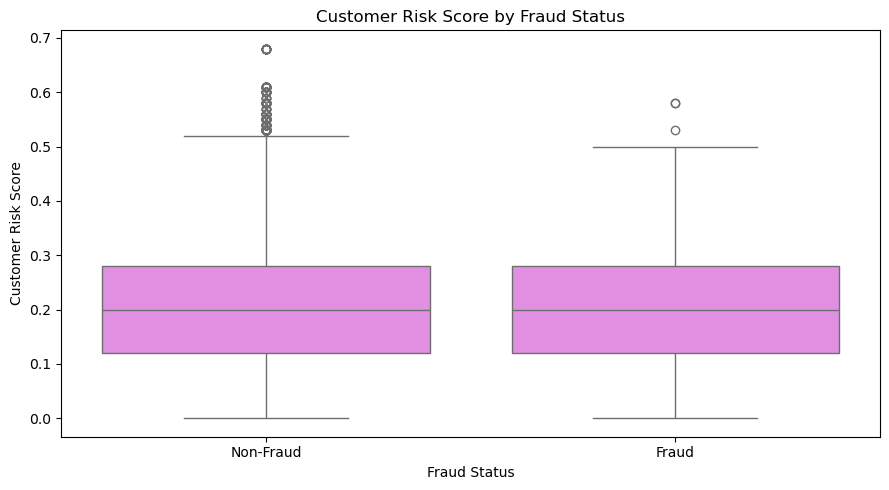

In [260]:
# TASK: Visualizing customer risk scores across fraudulent and non-fraudulent transactions to inspect the relationship before formal testing.

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=customer_risk_transaction,
    x="fraud_flag",
    y="customer_risk_score", 
    color='violet'
)

plt.title("Customer Risk Score by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Customer Risk Score")
plt.xticks(
    [0, 1],
    ["Non-Fraud", "Fraud"]
)

plt.tight_layout()
plt.show()

In [261]:
# TASK: Comparing customer risk-score distributions between fraudulent and non-fraudulent transactions using descriptive statistics.

risk_by_fraud = (
    customer_risk_transaction
    .groupby("fraud_flag")["customer_risk_score"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        standard_deviation="std"
    )
    .reset_index()
)

risk_by_fraud["fraud_status"] = (
    risk_by_fraud["fraud_flag"]
    .map({
        0: "Non-Fraud",
        1: "Fraud"
    })
)

print("=" * 70)
print("H4 — CUSTOMER RISK SCORE BY FRAUD STATUS")
print("=" * 70)

display(
    risk_by_fraud[
        [
            "fraud_status",
            "count",
            "mean",
            "median",
            "standard_deviation"
        ]
    ]
)

H4 — CUSTOMER RISK SCORE BY FRAUD STATUS


,fraud_status,count,mean,median,standard_deviation
0,Non-Fraud,98000,0.202464,0.2,0.114828
1,Fraud,2000,0.201150,0.2,0.114693


In [262]:
# TASK: Testing the association between customer risk score and fraud occurrence using point-biserial correlation.

risk_values = customer_risk_transaction[
    "customer_risk_score"
]

fraud_values = customer_risk_transaction[
    "fraud_flag"
]

point_biserial_r, p_h4 = stats.pointbiserialr(
    fraud_values,
    risk_values
)

print("=" * 80)
print("H4 — POINT-BISERIAL CORRELATION: CUSTOMER RISK × FRAUD")
print("=" * 80)

print(f"Point-biserial correlation (r): {point_biserial_r:.6f}")
print(f"p-value:                       {p_h4:.10f}")
print("Significance level (α):       0.05")

if p_h4 < 0.05:
    print("\nResult: Statistically significant association.")
else:
    print("\nResult: No statistically significant association.")

print("=" * 80)

H4 — POINT-BISERIAL CORRELATION: CUSTOMER RISK × FRAUD
Point-biserial correlation (r): -0.001603
p-value:                       0.6123161598
Significance level (α):       0.05

Result: No statistically significant association.


In [263]:
# TASK: Interpreting the customer-risk-score and fraud relationship using the direction, magnitude, and statistical significance of the correlation.

print("=" * 80)
print("H4 — CUSTOMER RISK SCORE × FRAUD: FORMAL CONCLUSION")
print("=" * 80)

print(f"""
Point-biserial correlation:
    {point_biserial_r:.6f}

p-value:
    {p_h4:.10f}
""")

if point_biserial_r > 0:
    direction = "positive"
elif point_biserial_r < 0:
    direction = "negative"
else:
    direction = "zero"

abs_r = abs(point_biserial_r)

if abs_r < 0.10:
    strength = "very weak"
elif abs_r < 0.30:
    strength = "weak"
elif abs_r < 0.50:
    strength = "moderate"
elif abs_r < 0.70:
    strength = "strong"
else:
    strength = "very strong"

print(
    f"Direction: {direction}"
)

print(
    f"Observed association strength: {strength}"
)

if p_h4 < 0.05:
    print("""
CONCLUSION:
There is statistically significant evidence of an association between
customer risk score and fraud occurrence.
""")
else:
    print("""
CONCLUSION:
There is insufficient statistical evidence of an association between
customer risk score and fraud occurrence at the 5% significance level.
""")

print("""
BUSINESS INTERPRETATION:
The direction of the correlation indicates whether higher customer-risk
scores tend to be associated with a greater or lower likelihood of fraud.

ANALYTICAL CAUTION:
Correlation does not establish causation and does not by itself establish
that the existing risk score is a good predictive model.
""")

print("=" * 80)

H4 — CUSTOMER RISK SCORE × FRAUD: FORMAL CONCLUSION

Point-biserial correlation:
    -0.001603

p-value:
    0.6123161598

Direction: negative
Observed association strength: very weak

CONCLUSION:
There is insufficient statistical evidence of an association between
customer risk score and fraud occurrence at the 5% significance level.


BUSINESS INTERPRETATION:
The direction of the correlation indicates whether higher customer-risk
scores tend to be associated with a greater or lower likelihood of fraud.

ANALYTICAL CAUTION:
Correlation does not establish causation and does not by itself establish
that the existing risk score is a good predictive model.



In [264]:
# TASK: Preparing Android and iOS transaction-value samples for the independent-samples t-test.

android_amounts = transactions_analysis.loc[
    transactions_analysis["device_type"].astype(str).str.lower() == "android",
    "amount"
].dropna()

ios_amounts = transactions_analysis.loc[
    transactions_analysis["device_type"].astype(str).str.lower() == "ios",
    "amount"
].dropna()

print("=" * 70)
print("H5 — ANDROID VS IOS TRANSACTION AMOUNTS")
print("=" * 70)

print("Android transactions:", len(android_amounts))
print("iOS transactions:", len(ios_amounts))

print("\nAndroid mean:", android_amounts.mean())
print("iOS mean:", ios_amounts.mean())

print("\nAndroid median:", android_amounts.median())
print("iOS median:", ios_amounts.median())

print("=" * 70)

H5 — ANDROID VS IOS TRANSACTION AMOUNTS
Android transactions: 25145
iOS transactions: 24783

Android mean: 42.37628315768543
iOS mean: 42.54217003591172

Android median: 33.03
iOS median: 33.09


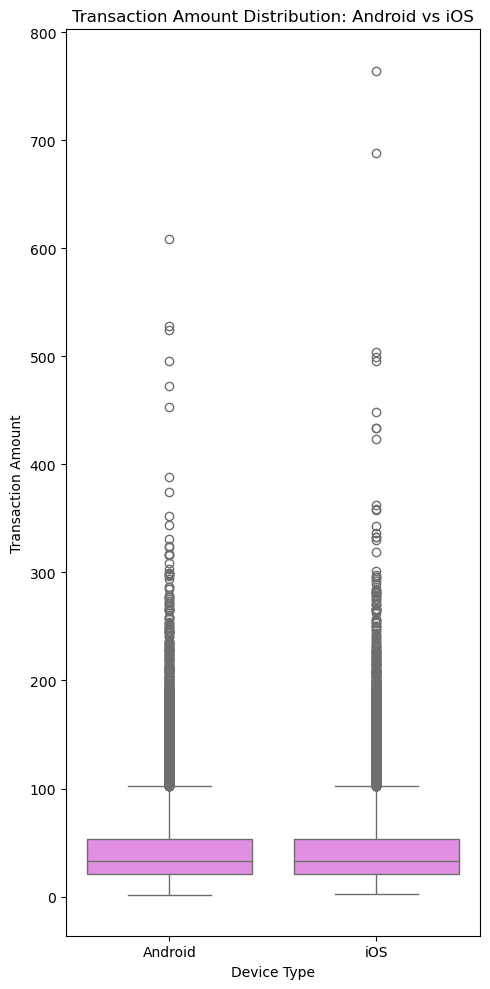

In [267]:
# TASK: Visualizing Android and iOS transaction-value distributions before performing the formal mean-comparison test.

android_ios_data = pd.DataFrame({
    "device_group": (
        ["Android"] * len(android_amounts)
        + ["iOS"] * len(ios_amounts)
    ),
    "amount": pd.concat(
        [android_amounts, ios_amounts],
        ignore_index=True
    )
})

plt.figure(figsize=(5,10))

sns.boxplot(
    data=android_ios_data,
    x="device_group",
    y="amount",
    color='violet'
)

plt.title("Transaction Amount Distribution: Android vs iOS")
plt.xlabel("Device Type")
plt.ylabel("Transaction Amount")
plt.tight_layout()
plt.show()

In [268]:
# TASK: Testing whether average transaction amounts differ between Android and iOS using Welch's independent-samples t-test.

t_stat_h5, p_h5 = stats.ttest_ind(
    android_amounts,
    ios_amounts,
    equal_var=False,
    alternative="two-sided"
)

mean_difference_h5 = (
    android_amounts.mean()
    - ios_amounts.mean()
)

print("=" * 80)
print("H5 — WELCH T-TEST: ANDROID VS IOS TRANSACTION AMOUNT")
print("=" * 80)

print(f"Android mean transaction amount: ₹{android_amounts.mean():,.4f}")
print(f"iOS mean transaction amount:     ₹{ios_amounts.mean():,.4f}")

print(f"\nMean difference (Android - iOS): ₹{mean_difference_h5:,.4f}")

print(f"\nt-statistic: {t_stat_h5:.6f}")
print(f"p-value:     {p_h5:.10f}")

print("\nSignificance level (α): 0.05")

if p_h5 < 0.05:
    print("Result: Statistically significant difference.")
else:
    print("Result: No statistically significant difference.")

print("=" * 80)

H5 — WELCH T-TEST: ANDROID VS IOS TRANSACTION AMOUNT
Android mean transaction amount: ₹42.3763
iOS mean transaction amount:     ₹42.5422

Mean difference (Android - iOS): ₹-0.1659

t-statistic: -0.540777
p-value:     0.5886638319

Significance level (α): 0.05
Result: No statistically significant difference.


In [269]:
# TASK: Estimating the 95% confidence interval for the difference between Android and iOS mean transaction amounts.

n_android = len(android_amounts)
n_ios = len(ios_amounts)

mean_android = android_amounts.mean()
mean_ios = ios_amounts.mean()

var_android = android_amounts.var(ddof=1)
var_ios = ios_amounts.var(ddof=1)

mean_diff = mean_android - mean_ios

# Welch-Satterthwaite degrees of freedom
welch_df = (
    (
        var_android / n_android
        + var_ios / n_ios
    ) ** 2
    /
    (
        (
            (var_android / n_android) ** 2
            / (n_android - 1)
        )
        +
        (
            (var_ios / n_ios) ** 2
            / (n_ios - 1)
        )
    )
)

standard_error = np.sqrt(
    var_android / n_android
    + var_ios / n_ios
)

critical_value = stats.t.ppf(
    0.975,
    welch_df
)

margin_of_error = (
    critical_value * standard_error
)

ci_lower = mean_diff - margin_of_error
ci_upper = mean_diff + margin_of_error

print("=" * 80)
print("H5 — 95% CONFIDENCE INTERVAL FOR MEAN DIFFERENCE")
print("=" * 80)

print(f"Welch degrees of freedom: {welch_df:.4f}")
print(f"Mean difference: ₹{mean_diff:,.4f}")

print(
    f"95% CI: ₹{ci_lower:,.4f} to ₹{ci_upper:,.4f}"
)

print("=" * 80)

H5 — 95% CONFIDENCE INTERVAL FOR MEAN DIFFERENCE
Welch degrees of freedom: 49886.6532
Mean difference: ₹-0.1659
95% CI: ₹-0.7671 to ₹0.4354


In [270]:
# TASK: Interpreting the Android-versus-iOS transaction-amount hypothesis using the Welch t-test and 95% confidence interval.

print("=" * 80)
print("H5 — ANDROID VS IOS TRANSACTION AMOUNT: FORMAL CONCLUSION")
print("=" * 80)

print(f"""
Android mean:
    ₹{mean_android:,.4f}

iOS mean:
    ₹{mean_ios:,.4f}

Mean difference (Android - iOS):
    ₹{mean_diff:,.4f}

t-statistic:
    {t_stat_h5:.6f}

p-value:
    {p_h5:.10f}

95% confidence interval for the mean difference:
    ₹{ci_lower:,.4f} to ₹{ci_upper:,.4f}
""")

if p_h5 < 0.05:
    print(
        "CONCLUSION: Reject the null hypothesis."
    )
    print(
        "There is statistically significant evidence that the mean "
        "transaction amounts differ between Android and iOS."
    )
else:
    print(
        "CONCLUSION: Fail to reject the null hypothesis."
    )
    print(
        "There is insufficient statistical evidence that mean "
        "transaction amounts differ between Android and iOS."
    )

print("""
BUSINESS INTERPRETATION:
The confidence interval shows the plausible range for the difference
in mean transaction amounts between the two device groups.

ANALYTICAL CAUTION:
A statistically significant difference does not by itself imply that
device type causes differences in transaction value.
""")

print("=" * 80)

H5 — ANDROID VS IOS TRANSACTION AMOUNT: FORMAL CONCLUSION

Android mean:
    ₹42.3763

iOS mean:
    ₹42.5422

Mean difference (Android - iOS):
    ₹-0.1659

t-statistic:
    -0.540777

p-value:
    0.5886638319

95% confidence interval for the mean difference:
    ₹-0.7671 to ₹0.4354

CONCLUSION: Fail to reject the null hypothesis.
There is insufficient statistical evidence that mean transaction amounts differ between Android and iOS.

BUSINESS INTERPRETATION:
The confidence interval shows the plausible range for the difference
in mean transaction amounts between the two device groups.

ANALYTICAL CAUTION:
A statistically significant difference does not by itself imply that
device type causes differences in transaction value.



In [271]:
# TASK: Creating merchant-level fraud-rate samples grouped by merchant type for one-way ANOVA.

merchant_anova_data = (
    merchant_analysis[
        [
            "merchant_id",
            "merchant_type",
            "transaction_count",
            "merchant_fraud_ratio"
        ]
    ]
    .dropna(
        subset=[
            "merchant_type",
            "merchant_fraud_ratio"
        ]
    )
    .copy()
)

# Keeping merchants with at least 10 transactions for more stable rate estimates
merchant_anova_data = merchant_anova_data[
    merchant_anova_data["transaction_count"] >= 10
].copy()

print("=" * 70)
print("STEP 7.3 — MERCHANT TYPE ANOVA DATA")
print("=" * 70)

print(
    "Merchants before activity threshold:",
    merchant_analysis["merchant_id"].nunique()
)

print(
    "Merchants after 10-transaction threshold:",
    merchant_anova_data["merchant_id"].nunique()
)

print("\nMerchants by merchant type:")

display(
    merchant_anova_data["merchant_type"]
    .value_counts()
    .rename_axis("merchant_type")
    .reset_index(name="merchant_count")
)

STEP 7.3 — MERCHANT TYPE ANOVA DATA
Merchants before activity threshold: 500
Merchants after 10-transaction threshold: 500

Merchants by merchant type:


,merchant_type,merchant_count
0,apparel,98
1,electronics,91
2,online,86
3,food,80
4,grocery,75
5,transport,70


In [272]:
# TASK: Testing whether mean merchant-level fraud rates differ across merchant types using one-way ANOVA.

merchant_groups = []

merchant_types = sorted(
    merchant_anova_data["merchant_type"]
    .dropna()
    .unique()
)

for merchant_type in merchant_types:

    group = merchant_anova_data.loc[
        merchant_anova_data["merchant_type"] == merchant_type,
        "merchant_fraud_ratio"
    ].dropna()

    merchant_groups.append(group)

anova_f_stat, anova_p_value = stats.f_oneway(
    *merchant_groups
)

print("=" * 80)
print("ANOVA — MERCHANT TYPE × MERCHANT FRAUD RATE")
print("=" * 80)

print("Merchant types tested:")
print(merchant_types)

print(f"\nF-statistic: {anova_f_stat:.6f}")
print(f"p-value:     {anova_p_value:.10f}")

print("\nSignificance level (α): 0.05")

if anova_p_value < 0.05:
    print(
        "Result: Statistically significant difference among merchant-type means."
    )
else:
    print(
        "Result: No statistically significant difference among merchant-type means."
    )

print("=" * 80)

ANOVA — MERCHANT TYPE × MERCHANT FRAUD RATE
Merchant types tested:
['apparel', 'electronics', 'food', 'grocery', 'online', 'transport']

F-statistic: 0.618320
p-value:     0.6859111163

Significance level (α): 0.05
Result: No statistically significant difference among merchant-type means.


In [273]:
# TASK: Creating descriptive statistics for merchant-level fraud rates within each merchant type to support ANOVA interpretation.

merchant_anova_summary = (
    merchant_anova_data
    .groupby("merchant_type")["merchant_fraud_ratio"]
    .agg(
        merchant_count="count",
        mean_fraud_rate="mean",
        median_fraud_rate="median",
        standard_deviation="std"
    )
    .reset_index()
)

merchant_anova_summary["mean_fraud_rate_pct"] = (
    merchant_anova_summary["mean_fraud_rate"] * 100
)

merchant_anova_summary["median_fraud_rate_pct"] = (
    merchant_anova_summary["median_fraud_rate"] * 100
)

merchant_anova_summary["standard_deviation_pct"] = (
    merchant_anova_summary["standard_deviation"] * 100
)

print("=" * 70)
print("ANOVA — MERCHANT TYPE DESCRIPTIVE STATISTICS")
print("=" * 70)

display(
    merchant_anova_summary.sort_values(
        "mean_fraud_rate_pct",
        ascending=False
    )
)

ANOVA — MERCHANT TYPE DESCRIPTIVE STATISTICS


,merchant_type,merchant_count,mean_fraud_rate,median_fraud_rate,standard_deviation,mean_fraud_rate_pct,median_fraud_rate_pct,standard_deviation_pct
1,electronics,91,0.022599,0.017544,0.018508,2.259932,1.754386,1.850767
0,apparel,98,0.021911,0.017241,0.019676,2.191086,1.724138,1.967639
4,online,86,0.020461,0.017247,0.019261,2.046128,1.724651,1.926116
5,transport,70,0.019769,0.016808,0.019086,1.976928,1.680791,1.908581
2,food,80,0.019616,0.017095,0.018297,1.961575,1.709527,1.829741
3,grocery,75,0.018079,0.016129,0.020073,1.807905,1.612903,2.007334


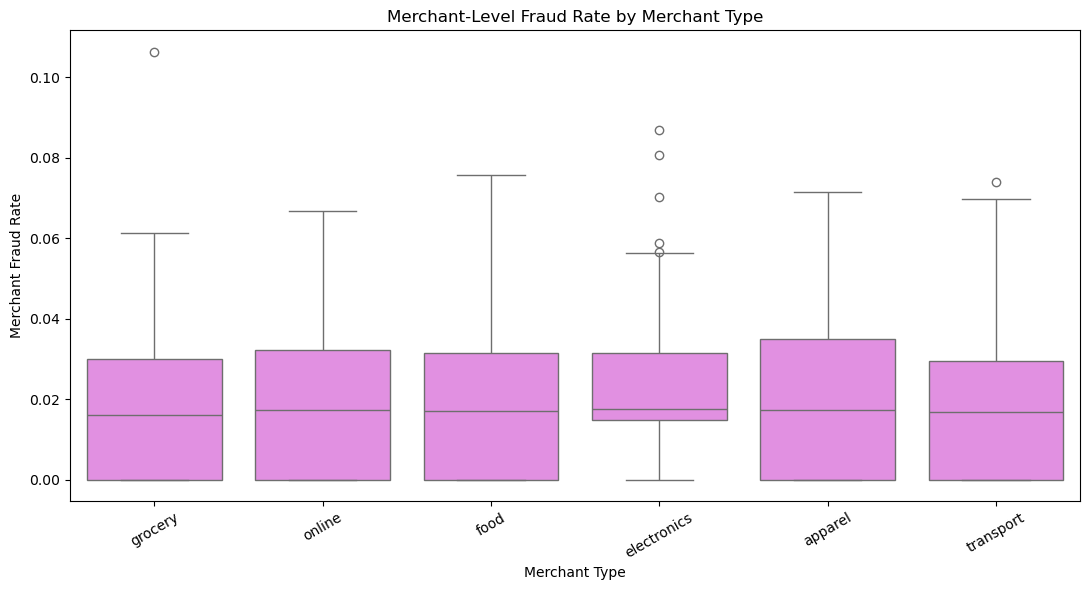

In [275]:
# TASK: Visualizing merchant-level fraud-rate distributions across merchant types to examine group variability before interpreting ANOVA.

plt.figure(figsize=(11, 6))

sns.boxplot(
    data=merchant_anova_data,
    x="merchant_type",
    y="merchant_fraud_ratio",
    color='violet'
)

plt.title("Merchant-Level Fraud Rate by Merchant Type")
plt.xlabel("Merchant Type")
plt.ylabel("Merchant Fraud Rate")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [276]:
# TASK: Quantifying the magnitude of merchant-type differences in fraud rates using eta-squared effect size.

grand_mean = merchant_anova_data[
    "merchant_fraud_ratio"
].mean()

between_group_ss = 0
total_ss = 0

for merchant_type in merchant_types:

    group_values = merchant_anova_data.loc[
        merchant_anova_data["merchant_type"] == merchant_type,
        "merchant_fraud_ratio"
    ].dropna()

    group_mean = group_values.mean()

    between_group_ss += (
        len(group_values)
        * (group_mean - grand_mean) ** 2
    )

    total_ss += (
        (group_values - grand_mean) ** 2
    ).sum()

eta_squared = (
    between_group_ss / total_ss
    if total_ss > 0
    else np.nan
)

print("=" * 80)
print("ANOVA — MERCHANT TYPE EFFECT SIZE")
print("=" * 80)

print(f"Eta-squared (η²): {eta_squared:.6f}")

if eta_squared < 0.01:
    eta_strength = "negligible"
elif eta_squared < 0.06:
    eta_strength = "small"
elif eta_squared < 0.14:
    eta_strength = "moderate"
else:
    eta_strength = "large"

print(f"Effect size interpretation: {eta_strength}")

print("=" * 80)

ANOVA — MERCHANT TYPE EFFECT SIZE
Eta-squared (η²): 0.006219
Effect size interpretation: negligible


In [277]:
# TASK: Interpreting the merchant-type ANOVA using statistical significance, group statistics, and effect size.

highest_mean_merchant_type = merchant_anova_summary.loc[
    merchant_anova_summary["mean_fraud_rate"].idxmax()
]

lowest_mean_merchant_type = merchant_anova_summary.loc[
    merchant_anova_summary["mean_fraud_rate"].idxmin()
]

print("=" * 80)
print("ANOVA — MERCHANT TYPE FRAUD: FORMAL CONCLUSION")
print("=" * 80)

print(f"""
Highest mean merchant fraud rate:
    {highest_mean_merchant_type["merchant_type"]}
    {highest_mean_merchant_type["mean_fraud_rate_pct"]:.4f}%

Lowest mean merchant fraud rate:
    {lowest_mean_merchant_type["merchant_type"]}
    {lowest_mean_merchant_type["mean_fraud_rate_pct"]:.4f}%

F-statistic:
    {anova_f_stat:.6f}

p-value:
    {anova_p_value:.10f}

Eta-squared:
    {eta_squared:.6f}

Effect size:
    {eta_strength}
""")

if anova_p_value < 0.05:
    print("""
CONCLUSION:
Reject the null hypothesis that all merchant-type mean fraud rates
are equal.

At least one merchant type has a statistically different mean
merchant-level fraud rate.
""")
else:
    print("""
CONCLUSION:
Fail to reject the null hypothesis.

There is insufficient evidence that mean merchant-level fraud rates
differ across merchant types.
""")

print("""
IMPORTANT NEXT STEP:
A significant omnibus ANOVA does not identify which specific merchant
types differ from one another. If the ANOVA is significant, we will
perform a suitable post-hoc comparison to locate the pairwise differences.

BUSINESS INTERPRETATION:
Merchant category can potentially be used as a risk-segmentation
variable if meaningful between-group differences are established.

ANALYTICAL CAUTION:
The analysis uses merchant-level fraud rates and a minimum activity
threshold. Rate estimates from very low-activity merchants are therefore
not allowed to dominate the comparison.
""")

print("=" * 80)

ANOVA — MERCHANT TYPE FRAUD: FORMAL CONCLUSION

Highest mean merchant fraud rate:
    electronics
    2.2599%

Lowest mean merchant fraud rate:
    grocery
    1.8079%

F-statistic:
    0.618320

p-value:
    0.6859111163

Eta-squared:
    0.006219

Effect size:
    negligible


CONCLUSION:
Fail to reject the null hypothesis.

There is insufficient evidence that mean merchant-level fraud rates
differ across merchant types.


IMPORTANT NEXT STEP:
A significant omnibus ANOVA does not identify which specific merchant
types differ from one another. If the ANOVA is significant, we will
perform a suitable post-hoc comparison to locate the pairwise differences.

BUSINESS INTERPRETATION:
Merchant category can potentially be used as a risk-segmentation
variable if meaningful between-group differences are established.

ANALYTICAL CAUTION:
The analysis uses merchant-level fraud rates and a minimum activity
threshold. Rate estimates from very low-activity merchants are therefore
not allowed to dom

In [278]:
# TASK: Documenting the merchant-type ANOVA finding and its business implication for fraud-risk segmentation.

print("=" * 80)
print("MERCHANT TYPE ANOVA — KEY FINDING")
print("=" * 80)

print(f"""
Merchant type with highest mean fraud rate:
    {highest_mean_merchant_type["merchant_type"]}
    {highest_mean_merchant_type["mean_fraud_rate_pct"]:.4f}%

Merchant type with lowest mean fraud rate:
    {lowest_mean_merchant_type["merchant_type"]}
    {lowest_mean_merchant_type["mean_fraud_rate_pct"]:.4f}%

F-statistic:
    {anova_f_stat:.6f}

p-value:
    {anova_p_value:.10f}

Eta-squared:
    {eta_squared:.6f}

Effect size:
    {eta_strength}
""")

print("""
STATISTICAL FINDING
-------------------
The ANOVA does not provide sufficient evidence that mean merchant-level
fraud rates differ across merchant types at the 5% significance level.

BUSINESS INTERPRETATION
-----------------------
Merchant category alone does not appear to be a strong differentiator
of merchant-level fraud rates in this dataset.

This suggests that fraud-risk segmentation should consider additional
merchant-level and transaction-level characteristics rather than relying
on merchant type alone.

ANALYTICAL CAUTION
------------------
This finding applies to the merchant-level fraud-rate analysis performed
here and does not imply that individual merchants or other merchant
attributes are unrelated to fraud.
""")

print("=" * 80)

MERCHANT TYPE ANOVA — KEY FINDING

Merchant type with highest mean fraud rate:
    electronics
    2.2599%

Merchant type with lowest mean fraud rate:
    grocery
    1.8079%

F-statistic:
    0.618320

p-value:
    0.6859111163

Eta-squared:
    0.006219

Effect size:
    negligible


STATISTICAL FINDING
-------------------
The ANOVA does not provide sufficient evidence that mean merchant-level
fraud rates differ across merchant types at the 5% significance level.

BUSINESS INTERPRETATION
-----------------------
Merchant category alone does not appear to be a strong differentiator
of merchant-level fraud rates in this dataset.

This suggests that fraud-risk segmentation should consider additional
merchant-level and transaction-level characteristics rather than relying
on merchant type alone.

ANALYTICAL CAUTION
------------------
This finding applies to the merchant-level fraud-rate analysis performed
here and does not imply that individual merchants or other merchant
attributes are u

In [279]:
# TASK: Creating customer-region fraud-rate samples for one-way ANOVA to test whether regional fraud rates differ significantly.

region_anova_data = (
    regional_transaction_analysis[
        [
            "region",
            "transaction_count",
            "fraud_rate"
        ]
    ]
    .dropna(
        subset=[
            "region",
            "fraud_rate"
        ]
    )
    .copy()
)

print("=" * 70)
print("ANOVA — REGIONAL FRAUD-RATE DATA")
print("=" * 70)

display(region_anova_data)

ANOVA — REGIONAL FRAUD-RATE DATA


,region,transaction_count,fraud_rate
0,central,19677,0.019414
1,east,20078,0.020022
2,north,20787,0.019435
3,south,19372,0.020287
4,west,20086,0.020860


In [284]:
# TASK: Creating customer-level fraud-rate samples within each region to provide valid repeated observations for regional ANOVA.

regional_customer_anova = (
    customer_analysis[
        [
            "customer_id",
            "region",
            "transaction_count",
            "fraud_transaction_count",
            "fraud_rate"
        ]
    ]
    .copy()
)

# Keeping customers with at least one transaction
regional_customer_anova = regional_customer_anova[
    regional_customer_anova["transaction_count"] > 0
].copy()

# Replacing any undefined rate with zero where no fraud occurred
regional_customer_anova["fraud_rate"] = (
    regional_customer_anova["fraud_rate"]
    .fillna(0)
)

print("=" * 70)
print("ANOVA — CUSTOMER-LEVEL REGIONAL FRAUD-RATE DATA")
print("=" * 70)

print(
    "Customers with transaction activity:",
    len(regional_customer_anova)
)

print("\nCustomers by region:")

display(
    regional_customer_anova[
        "region"
    ]
    .value_counts()
    .rename_axis("region")
    .reset_index(name="customer_count")
    .sort_values("region")
)

print("=" * 70)

ANOVA — CUSTOMER-LEVEL REGIONAL FRAUD-RATE DATA
Customers with transaction activity: 7032

Customers by region:


,region,customer_count
2,central,1409
3,east,1383
0,north,1448
4,south,1360
1,west,1432


In [285]:
# TASK: Testing whether mean customer-level fraud rates differ across regions using a one-way ANOVA.

region_customer_groups = []

region_names = sorted(
    regional_customer_anova["region"]
    .dropna()
    .unique()
)

for region in region_names:

    group = regional_customer_anova.loc[
        regional_customer_anova["region"] == region,
        "fraud_rate"
    ].dropna()

    region_customer_groups.append(group)

anova_region_f, anova_region_p = stats.f_oneway(
    *region_customer_groups
)

print("=" * 80)
print("ANOVA — CUSTOMER FRAUD RATE × REGION")
print("=" * 80)

print("Regions tested:")
print(region_names)

print(f"\nF-statistic: {anova_region_f:.6f}")
print(f"p-value:     {anova_region_p:.10f}")

print("\nSignificance level (α): 0.05")

if anova_region_p < 0.05:
    print(
        "Result: Statistically significant difference among regional means."
    )
else:
    print(
        "Result: No statistically significant difference among regional means."
    )

print("=" * 80)

ANOVA — CUSTOMER FRAUD RATE × REGION
Regions tested:
['central', 'east', 'north', 'south', 'west']

F-statistic: 0.721934
p-value:     0.5768156791

Significance level (α): 0.05
Result: No statistically significant difference among regional means.


In [286]:
# TASK: Creating mean, median, and standard-deviation summaries of customer-level fraud rates within each region.

region_customer_summary = (
    regional_customer_anova
    .groupby("region")["fraud_rate"]
    .agg(
        customer_count="count",
        mean_fraud_rate="mean",
        median_fraud_rate="median",
        standard_deviation="std"
    )
    .reset_index()
)

region_customer_summary["mean_fraud_rate_pct"] = (
    region_customer_summary["mean_fraud_rate"] * 100
)

region_customer_summary["median_fraud_rate_pct"] = (
    region_customer_summary["median_fraud_rate"] * 100
)

region_customer_summary["standard_deviation_pct"] = (
    region_customer_summary["standard_deviation"] * 100
)

print("=" * 70)
print("REGIONAL CUSTOMER FRAUD-RATE DESCRIPTIVE STATISTICS")
print("=" * 70)

display(
    region_customer_summary.sort_values(
        "mean_fraud_rate_pct",
        ascending=False
    )
)

REGIONAL CUSTOMER FRAUD-RATE DESCRIPTIVE STATISTICS


,region,customer_count,mean_fraud_rate,median_fraud_rate,standard_deviation,mean_fraud_rate_pct,median_fraud_rate_pct,standard_deviation_pct
3,south,1360,0.021376,0.0,0.054901,2.137556,0.0,5.490084
4,west,1432,0.020339,0.0,0.054196,2.033873,0.0,5.419594
0,central,1409,0.019936,0.0,0.052544,1.993649,0.0,5.254396
1,east,1383,0.018750,0.0,0.048642,1.874997,0.0,4.864163
2,north,1448,0.018450,0.0,0.052130,1.845030,0.0,5.212991


In [287]:
# TASK: Quantifying the magnitude of regional differences in customer-level fraud rates using eta-squared effect size.

grand_mean_region = (
    regional_customer_anova["fraud_rate"].mean()
)

between_group_ss_region = 0
total_ss_region = 0

for region in region_names:

    group_values = regional_customer_anova.loc[
        regional_customer_anova["region"] == region,
        "fraud_rate"
    ].dropna()

    group_mean = group_values.mean()

    between_group_ss_region += (
        len(group_values)
        * (group_mean - grand_mean_region) ** 2
    )

    total_ss_region += (
        (group_values - grand_mean_region) ** 2
    ).sum()

eta_squared_region = (
    between_group_ss_region / total_ss_region
    if total_ss_region > 0
    else np.nan
)

print("=" * 80)
print("REGIONAL ANOVA — EFFECT SIZE")
print("=" * 80)

print(
    f"Eta-squared (η²): {eta_squared_region:.6f}"
)

if eta_squared_region < 0.01:
    region_eta_strength = "negligible"
elif eta_squared_region < 0.06:
    region_eta_strength = "small"
elif eta_squared_region < 0.14:
    region_eta_strength = "moderate"
else:
    region_eta_strength = "large"

print(
    f"Effect size interpretation: {region_eta_strength}"
)

print("=" * 80)

REGIONAL ANOVA — EFFECT SIZE
Eta-squared (η²): 0.000411
Effect size interpretation: negligible


In [288]:
# TASK: Interpreting the regional ANOVA using statistical significance, customer-level fraud-rate differences, and effect size.

highest_region_customer = region_customer_summary.loc[
    region_customer_summary["mean_fraud_rate"].idxmax()
]

lowest_region_customer = region_customer_summary.loc[
    region_customer_summary["mean_fraud_rate"].idxmin()
]

print("=" * 80)
print("REGIONAL FRAUD-RATE ANOVA — FORMAL CONCLUSION")
print("=" * 80)

print(f"""
Highest mean customer fraud rate:
    {highest_region_customer["region"]}
    {highest_region_customer["mean_fraud_rate_pct"]:.4f}%

Lowest mean customer fraud rate:
    {lowest_region_customer["region"]}
    {lowest_region_customer["mean_fraud_rate_pct"]:.4f}%

F-statistic:
    {anova_region_f:.6f}

p-value:
    {anova_region_p:.10f}

Eta-squared:
    {eta_squared_region:.6f}

Effect size:
    {region_eta_strength}
""")

if anova_region_p < 0.05:
    print("""
CONCLUSION:
Reject the null hypothesis.

There is statistically significant evidence that mean customer-level
fraud rates differ across regions.
""")
else:
    print("""
CONCLUSION:
Fail to reject the null hypothesis.

There is insufficient evidence that mean customer-level fraud rates
differ across regions.
""")

print("""
BUSINESS INTERPRETATION:
Regional customer-level fraud exposure is evaluated using multiple
observations per region, allowing within-region variability to be
estimated appropriately.

ANALYTICAL CAUTION:
The analysis identifies regional association, not geographic causation.
Other variables such as device, channel, customer risk, and transaction
behavior may contribute to the observed differences.
""")

print("=" * 80)

REGIONAL FRAUD-RATE ANOVA — FORMAL CONCLUSION

Highest mean customer fraud rate:
    south
    2.1376%

Lowest mean customer fraud rate:
    north
    1.8450%

F-statistic:
    0.721934

p-value:
    0.5768156791

Eta-squared:
    0.000411

Effect size:
    negligible


CONCLUSION:
Fail to reject the null hypothesis.

There is insufficient evidence that mean customer-level fraud rates
differ across regions.


BUSINESS INTERPRETATION:
Regional customer-level fraud exposure is evaluated using multiple
observations per region, allowing within-region variability to be
estimated appropriately.

ANALYTICAL CAUTION:
The analysis identifies regional association, not geographic causation.
Other variables such as device, channel, customer risk, and transaction
behavior may contribute to the observed differences.



In [289]:
# TASK: Creating a clean transaction-level correlation dataset containing transaction amount, fraud, reversal, time, and customer risk variables.

correlation_data = transactions_analysis[
    [
        "transaction_id",
        "customer_id",
        "amount",
        "fraud_flag",
        "reversal_flag",
        "transaction_hour"
    ]
].merge(
    customers_analysis[
        [
            "customer_id",
            "risk_score"
        ]
    ],
    on="customer_id",
    how="left"
)

correlation_data.rename(
    columns={
        "risk_score": "customer_risk_score"
    },
    inplace=True
)

print("=" * 70)
print("STEP 7.4 — CORRELATION ANALYSIS DATASET")
print("=" * 70)

print("Records:", len(correlation_data))
print(
    "Missing customer risk scores:",
    correlation_data["customer_risk_score"].isna().sum()
)

display(
    correlation_data.head(10)
)

STEP 7.4 — CORRELATION ANALYSIS DATASET
Records: 100000
Missing customer risk scores: 0


,transaction_id,customer_id,amount,fraud_flag,reversal_flag,transaction_hour,customer_risk_score
0,txn10000000,cust101488,9.88,0,0,21,0.32
1,txn10000001,cust107876,76.25,0,0,4,0.00
2,txn10000002,cust100901,26.44,0,0,2,0.22
3,txn10000003,cust105890,84.43,0,0,3,0.26
4,txn10000004,cust106780,10.33,0,0,21,0.19
5,txn10000005,cust102097,37.61,0,0,10,0.45
6,txn10000006,cust108896,77.74,0,1,3,0.25
7,txn10000007,cust102418,47.46,0,0,11,0.20
8,txn10000008,cust109937,19.94,0,0,8,0.30
9,txn10000009,cust108084,13.95,0,0,2,0.16


In [290]:
# TASK: Calculating Pearson correlations among key numerical transaction, fraud, reversal, time, and customer-risk variables.

correlation_matrix = correlation_data[
    [
        "amount",
        "fraud_flag",
        "reversal_flag",
        "transaction_hour",
        "customer_risk_score"
    ]
].corr(
    method="pearson"
)

print("=" * 70)
print("STEP 7.4 — PEARSON CORRELATION MATRIX")
print("=" * 70)

display(
    correlation_matrix.round(4)
)

STEP 7.4 — PEARSON CORRELATION MATRIX


,amount,fraud_flag,reversal_flag,transaction_hour,customer_risk_score
amount,1.0000,-0.0003,0.0022,-0.0028,0.0014
fraud_flag,-0.0003,1.0000,-0.0012,-0.0095,-0.0016
reversal_flag,0.0022,-0.0012,1.0000,-0.0007,0.0052
transaction_hour,-0.0028,-0.0095,-0.0007,1.0000,-0.0028
customer_risk_score,0.0014,-0.0016,0.0052,-0.0028,1.0000


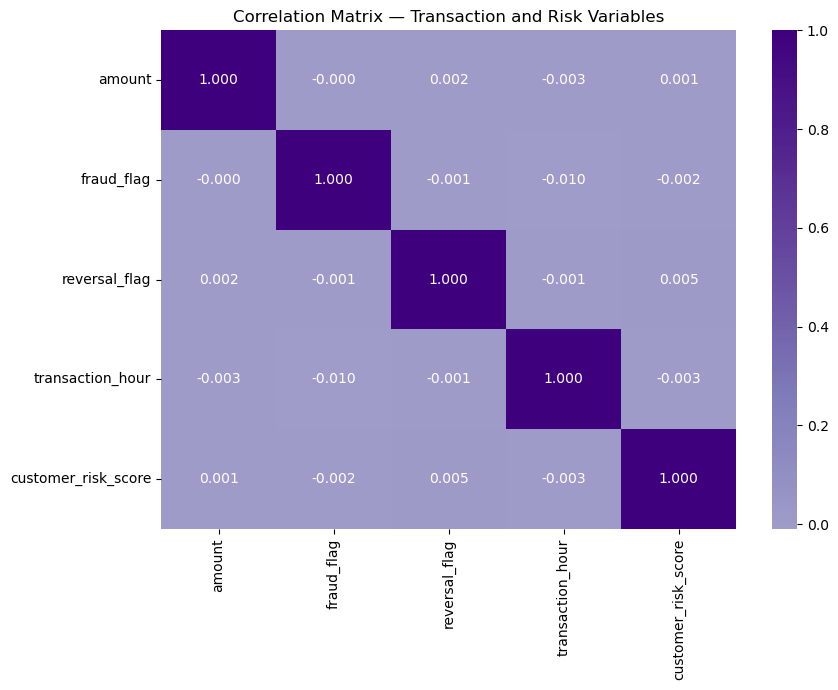

In [291]:
# TASK: Visualizing correlations among key numerical transaction and risk variables using a heatmap.

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="Purples",
    center=0
)

plt.title("Correlation Matrix — Transaction and Risk Variables")
plt.tight_layout()
plt.show()

In [292]:
# TASK: Identifying the strongest non-self correlations in the transaction and risk correlation matrix.

correlation_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

correlation_pairs.columns = [
    "variable_1",
    "variable_2",
    "correlation"
]

correlation_pairs["absolute_correlation"] = (
    correlation_pairs["correlation"].abs()
)

correlation_pairs = (
    correlation_pairs
    .sort_values(
        "absolute_correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("STEP 7.4 — STRONGEST CORRELATION PAIRS")
print("=" * 70)

display(
    correlation_pairs.head(10)
)

STEP 7.4 — STRONGEST CORRELATION PAIRS


,variable_1,variable_2,correlation,absolute_correlation
0,fraud_flag,transaction_hour,-0.009546,0.009546
1,reversal_flag,customer_risk_score,0.005209,0.005209
2,transaction_hour,customer_risk_score,-0.002812,0.002812
3,amount,transaction_hour,-0.002801,0.002801
4,amount,reversal_flag,0.002198,0.002198
5,fraud_flag,customer_risk_score,-0.001603,0.001603
6,amount,customer_risk_score,0.001449,0.001449
7,fraud_flag,reversal_flag,-0.001207,0.001207
8,reversal_flag,transaction_hour,-0.000681,0.000681
9,amount,fraud_flag,-0.000256,0.000256


In [293]:
# TASK: Interpreting the strongest observed relationships among transaction amount, fraud, reversal, time, and customer risk variables.

strongest_pair = correlation_pairs.iloc[0]

print("=" * 80)
print("CORRELATION ANALYSIS — BUSINESS INTERPRETATION")
print("=" * 80)

print(f"""
1. STRONGEST OBSERVED RELATIONSHIP
   {strongest_pair["variable_1"]} and
   {strongest_pair["variable_2"]} show the strongest absolute
   Pearson correlation of {strongest_pair["correlation"]:.4f}.

2. CORRELATION DIRECTION
   The relationship is
   {"positive" if strongest_pair["correlation"] > 0 else "negative"}.

3. BUSINESS INTERPRETATION
   The correlation matrix helps identify numerical variables that move
   together within the transaction dataset.

4. RISK-MANAGEMENT IMPLICATION
   Variables showing stronger relationships can be prioritized for
   additional investigation and potentially incorporated into later
   analytical or predictive modelling.

5. ANALYTICAL CAUTION
   Correlation measures association, not causation. It also does not
   establish whether one variable is a useful predictive feature.
""")

print("=" * 80)

CORRELATION ANALYSIS — BUSINESS INTERPRETATION

1. STRONGEST OBSERVED RELATIONSHIP
   fraud_flag and
   transaction_hour show the strongest absolute
   Pearson correlation of -0.0095.

2. CORRELATION DIRECTION
   The relationship is
   negative.

3. BUSINESS INTERPRETATION
   The correlation matrix helps identify numerical variables that move
   together within the transaction dataset.

4. RISK-MANAGEMENT IMPLICATION
   Variables showing stronger relationships can be prioritized for
   additional investigation and potentially incorporated into later
   analytical or predictive modelling.

5. ANALYTICAL CAUTION
   Correlation measures association, not causation. It also does not
   establish whether one variable is a useful predictive feature.



In [294]:
# TASK: Consolidating the formal hypothesis-testing results into one statistical evidence table for reporting and decision-making.

statistical_results = pd.DataFrame({
    "hypothesis": [
        "H1 — Rooted Device × Fraud",
        "H2 — Channel × Fraud",
        "H3 — Device Type × Transaction Status",
        "H4 — Customer Risk Score × Fraud",
        "H5 — Android vs iOS Transaction Amount",
        "H6 — Merchant Type × Fraud Rate",
        "H7 — Region × Customer Fraud Rate"
    ],

    "test": [
        "Chi-square",
        "Chi-square",
        "Chi-square",
        "Point-biserial correlation",
        "Welch t-test",
        "One-way ANOVA",
        "One-way ANOVA"
    ],

    "statistic": [
        chi2_h1,
        chi2_h2,
        chi2_h3,
        point_biserial_r,
        t_stat_h5,
        anova_f_stat,
        anova_region_f
    ],

    "p_value": [
        p_h1,
        p_h2,
        p_h3,
        p_h4,
        p_h5,
        anova_p_value,
        anova_region_p
    ],

    "effect_size": [
        phi_h1,
        cramers_v_h2,
        cramers_v_h3,
        point_biserial_r,
        np.nan,
        eta_squared,
        eta_squared_region
    ]
})

statistical_results["significance_level"] = 0.05

statistical_results["decision"] = np.where(
    statistical_results["p_value"] < 0.05,
    "Reject H0",
    "Fail to Reject H0"
)

statistical_results["statistically_significant"] = (
    statistical_results["p_value"] < 0.05
)

print("=" * 80)
print("STEP 7.5 — CONSOLIDATED STATISTICAL RESULTS")
print("=" * 80)

display(
    statistical_results
)

STEP 7.5 — CONSOLIDATED STATISTICAL RESULTS


,hypothesis,test,statistic,p_value,effect_size,significance_level,decision,statistically_significant
0,H1 — Rooted Device × Fraud,Chi-square,5825.095131,0.000000,0.241352,0.05,Reject H0,True
1,H2 — Channel × Fraud,Chi-square,3.883743,0.143435,0.006232,0.05,Fail to Reject H0,False
2,H3 — Device Type × Transaction Status,Chi-square,5.934359,0.430583,0.005447,0.05,Fail to Reject H0,False
3,H4 — Customer Risk Score × Fraud,Point-biserial correlation,-0.001603,0.612316,-0.001603,0.05,Fail to Reject H0,False
4,H5 — Android vs iOS Transaction Amount,Welch t-test,-0.540777,0.588664,NaN,0.05,Fail to Reject H0,False
5,H6 — Merchant Type × Fraud Rate,One-way ANOVA,0.618320,0.685911,0.006219,0.05,Fail to Reject H0,False
6,H7 — Region × Customer Fraud Rate,One-way ANOVA,0.721934,0.576816,0.000411,0.05,Fail to Reject H0,False


In [295]:
# TASK: Separating statistically significant and non-significant findings to distinguish supported hypotheses from descriptive-only findings.

significant_results = statistical_results[
    statistical_results["statistically_significant"]
].copy()

non_significant_results = statistical_results[
    ~statistical_results["statistically_significant"]
].copy()

print("=" * 80)
print("STEP 7.5 — STATISTICAL SIGNIFICANCE SUMMARY")
print("=" * 80)

print(
    "Statistically significant hypotheses:",
    len(significant_results)
)

print(
    "Non-significant hypotheses:",
    len(non_significant_results)
)

print("\nSIGNIFICANT FINDINGS")
print("-" * 50)

if len(significant_results) > 0:
    display(
        significant_results[
            [
                "hypothesis",
                "test",
                "p_value",
                "effect_size",
                "decision"
            ]
        ]
    )
else:
    print("No statistically significant findings.")

print("\nNON-SIGNIFICANT FINDINGS")
print("-" * 50)

if len(non_significant_results) > 0:
    display(
        non_significant_results[
            [
                "hypothesis",
                "test",
                "p_value",
                "effect_size",
                "decision"
            ]
        ]
    )
else:
    print("All tested hypotheses are statistically significant.")

STEP 7.5 — STATISTICAL SIGNIFICANCE SUMMARY
Statistically significant hypotheses: 1
Non-significant hypotheses: 6

SIGNIFICANT FINDINGS
--------------------------------------------------


,hypothesis,test,p_value,effect_size,decision
0,H1 — Rooted Device × Fraud,Chi-square,0.0,0.241352,Reject H0



NON-SIGNIFICANT FINDINGS
--------------------------------------------------


,hypothesis,test,p_value,effect_size,decision
1,H2 — Channel × Fraud,Chi-square,0.143435,0.006232,Fail to Reject H0
2,H3 — Device Type × Transaction Status,Chi-square,0.430583,0.005447,Fail to Reject H0
3,H4 — Customer Risk Score × Fraud,Point-biserial correlation,0.612316,-0.001603,Fail to Reject H0
4,H5 — Android vs iOS Transaction Amount,Welch t-test,0.588664,NaN,Fail to Reject H0
5,H6 — Merchant Type × Fraud Rate,One-way ANOVA,0.685911,0.006219,Fail to Reject H0
6,H7 — Region × Customer Fraud Rate,One-way ANOVA,0.576816,0.000411,Fail to Reject H0


In [296]:
# TASK: Creating the formal Step 7 statistical-analysis conclusion by summarizing the evidence, supported hypotheses, and analytical limitations.

print("=" * 85)
print("STEP 7 — STATISTICAL ANALYSIS: FORMAL SUMMARY")
print("=" * 85)

print(f"""
1. HYPOTHESES TESTED
   Total hypotheses/tests: {len(statistical_results)}

2. STATISTICALLY SIGNIFICANT RESULTS
   {len(significant_results)} hypothesis(es) show p-values below 0.05.

3. NON-SIGNIFICANT RESULTS
   {len(non_significant_results)} hypothesis(es) do not reach the 5%
   significance threshold.

4. EFFECT SIZES
   Effect sizes are reported alongside p-values to distinguish
   statistical significance from practical magnitude.

5. BUSINESS INTERPRETATION
   The statistical analysis converts the descriptive EDA findings into
   formal evidence and identifies which observed relationships are
   supported statistically.

6. ANALYTICAL LIMITATION
   Statistical association does not establish causation. Results also
   depend on the selected observation unit, assumptions of each test,
   data quality, and the structure of the available dataset.

7. REPORTING PRINCIPLE
   Statistically significant results are not automatically treated as
   business priorities; transaction volume, monetary exposure, effect
   size, and operational relevance are considered alongside p-values.
""")

print("=" * 85)

STEP 7 — STATISTICAL ANALYSIS: FORMAL SUMMARY

1. HYPOTHESES TESTED
   Total hypotheses/tests: 7

2. STATISTICALLY SIGNIFICANT RESULTS
   1 hypothesis(es) show p-values below 0.05.

3. NON-SIGNIFICANT RESULTS
   6 hypothesis(es) do not reach the 5%
   significance threshold.

4. EFFECT SIZES
   Effect sizes are reported alongside p-values to distinguish
   statistical significance from practical magnitude.

5. BUSINESS INTERPRETATION
   The statistical analysis converts the descriptive EDA findings into
   formal evidence and identifies which observed relationships are
   supported statistically.

6. ANALYTICAL LIMITATION
   Statistical association does not establish causation. Results also
   depend on the selected observation unit, assumptions of each test,
   data quality, and the structure of the available dataset.

7. REPORTING PRINCIPLE
   Statistically significant results are not automatically treated as
   business priorities; transaction volume, monetary exposure, effect
   si

In [297]:
# TASK: Checking expected cell frequencies for the chi-square tests to verify that the association tests have adequate expected counts.

chi_square_expected_counts = {
    "H1 — Rooted Device × Fraud": expected_h1_df,
    "H2 — Channel × Fraud": expected_h2_df,
    "H3 — Device Type × Transaction Status": expected_h3_df
}

print("=" * 80)
print("STEP 7.6 — CHI-SQUARE ASSUMPTION CHECK")
print("=" * 80)

for test_name, expected_table in chi_square_expected_counts.items():

    minimum_expected = expected_table.to_numpy().min()
    cells_below_5 = (
        expected_table.to_numpy() < 5
    ).sum()

    print(f"\n{test_name}")
    print("-" * 60)
    print(f"Minimum expected frequency: {minimum_expected:.4f}")
    print(f"Cells with expected frequency < 5: {cells_below_5}")

    if cells_below_5 == 0:
        print("Assumption check: PASS")
    else:
        print("Assumption check: REVIEW REQUIRED")

print("=" * 80)

STEP 7.6 — CHI-SQUARE ASSUMPTION CHECK

H1 — Rooted Device × Fraud
------------------------------------------------------------
Minimum expected frequency: 63.4200
Cells with expected frequency < 5: 0
Assumption check: PASS

H2 — Channel × Fraud
------------------------------------------------------------
Minimum expected frequency: 665.5800
Cells with expected frequency < 5: 0
Assumption check: PASS

H3 — Device Type × Transaction Status
------------------------------------------------------------
Minimum expected frequency: 486.8276
Cells with expected frequency < 5: 0
Assumption check: PASS


In [298]:
# TASK: Checking ANOVA group sizes and variance homogeneity for merchant-type and regional fraud-rate analyses.

print("=" * 80)
print("STEP 7.6 — ANOVA ASSUMPTION CHECK")
print("=" * 80)

# ---------------------------------------------------------
# MERCHANT-TYPE ANOVA
# ---------------------------------------------------------

merchant_group_sizes = (
    merchant_anova_data
    .groupby("merchant_type")
    .size()
)

merchant_levene_groups = [
    merchant_anova_data.loc[
        merchant_anova_data["merchant_type"] == merchant_type,
        "merchant_fraud_ratio"
    ].dropna()
    for merchant_type in merchant_types
]

merchant_levene_stat, merchant_levene_p = stats.levene(
    *merchant_levene_groups,
    center="median"
)

print("\nMERCHANT-TYPE ANOVA")
print("-" * 60)

print("Group sizes:")
print(merchant_group_sizes)

print(f"\nLevene statistic: {merchant_levene_stat:.6f}")
print(f"Levene p-value:   {merchant_levene_p:.10f}")

if merchant_levene_p > 0.05:
    print("Variance-homogeneity check: PASS")
else:
    print("Variance-homogeneity check: REVIEW")


# ---------------------------------------------------------
# REGIONAL ANOVA
# ---------------------------------------------------------

region_group_sizes = (
    regional_customer_anova
    .groupby("region")
    .size()
)

region_levene_groups = [
    regional_customer_anova.loc[
        regional_customer_anova["region"] == region,
        "fraud_rate"
    ].dropna()
    for region in region_names
]

region_levene_stat, region_levene_p = stats.levene(
    *region_levene_groups,
    center="median"
)

print("\nREGIONAL ANOVA")
print("-" * 60)

print("Group sizes:")
print(region_group_sizes)

print(f"\nLevene statistic: {region_levene_stat:.6f}")
print(f"Levene p-value:   {region_levene_p:.10f}")

if region_levene_p > 0.05:
    print("Variance-homogeneity check: PASS")
else:
    print("Variance-homogeneity check: REVIEW")

print("=" * 80)

STEP 7.6 — ANOVA ASSUMPTION CHECK

MERCHANT-TYPE ANOVA
------------------------------------------------------------
Group sizes:
merchant_type
apparel        98
electronics    91
food           80
grocery        75
online         86
transport      70
dtype: int64

Levene statistic: 0.730317
Levene p-value:   0.6009438835
Variance-homogeneity check: PASS

REGIONAL ANOVA
------------------------------------------------------------
Group sizes:
region
central    1409
east       1383
north      1448
south      1360
west       1432
dtype: int64

Levene statistic: 0.721934
Levene p-value:   0.5768156791
Variance-homogeneity check: PASS


In [299]:
# TASK: Checking Android and iOS transaction-value samples for size, skewness, variability, and extreme-value influence before interpreting the Welch t-test.

t_test_assumption_summary = pd.DataFrame({
    "device_group": ["Android", "iOS"],
    "sample_size": [
        len(android_amounts),
        len(ios_amounts)
    ],
    "mean": [
        android_amounts.mean(),
        ios_amounts.mean()
    ],
    "median": [
        android_amounts.median(),
        ios_amounts.median()
    ],
    "standard_deviation": [
        android_amounts.std(),
        ios_amounts.std()
    ],
    "skewness": [
        android_amounts.skew(),
        ios_amounts.skew()
    ]
})

print("=" * 80)
print("STEP 7.6 — WELCH T-TEST ASSUMPTION REVIEW")
print("=" * 80)

display(t_test_assumption_summary)

print("""
ASSUMPTION NOTES
----------------
1. The two device groups are treated as independent transaction samples.
2. Welch's test does not require equal population variances.
3. Large sample sizes make the mean comparison relatively robust to
   moderate departures from normality.
4. Extreme transaction values are retained because they may represent
   genuine payment behavior; their influence is reviewed rather than
   automatically removed.
""")

print("=" * 80)

STEP 7.6 — WELCH T-TEST ASSUMPTION REVIEW


,device_group,sample_size,mean,median,standard_deviation,skewness
0,Android,25145,42.376283,33.03,34.035585,3.009106
1,iOS,24783,42.542170,33.09,34.501120,3.348459



ASSUMPTION NOTES
----------------
1. The two device groups are treated as independent transaction samples.
2. Welch's test does not require equal population variances.
3. Large sample sizes make the mean comparison relatively robust to
   moderate departures from normality.
4. Extreme transaction values are retained because they may represent
   genuine payment behavior; their influence is reviewed rather than
   automatically removed.



In [300]:
# TASK: Reviewing the customer-risk-score and fraud relationship for linearity, group separation, and potential extreme-value influence.

print("=" * 80)
print("STEP 7.6 — CORRELATION ASSUMPTION REVIEW")
print("=" * 80)

print("""
POINT-BISERIAL CORRELATION REVIEW
---------------------------------
Variable 1: Customer risk score
Variable 2: Binary fraud indicator

The point-biserial correlation is mathematically equivalent to Pearson
correlation when one variable is continuous and the other is binary.

Key considerations:
- Customer risk score is continuous.
- Fraud occurrence is binary.
- Observations are treated as transaction-level observations.
- A visual comparison of risk-score distributions is used to inspect
  whether the groups show a meaningful relationship.
- Extreme values and influential observations should be interpreted
  cautiously.

A statistically significant correlation is interpreted as an association,
not as evidence of causation or proof that the risk score is a validated
predictive model.
""")

print(f"Observed correlation: {point_biserial_r:.6f}")
print(f"Observed p-value:     {p_h4:.10f}")

print("=" * 80)

STEP 7.6 — CORRELATION ASSUMPTION REVIEW

POINT-BISERIAL CORRELATION REVIEW
---------------------------------
Variable 1: Customer risk score
Variable 2: Binary fraud indicator

The point-biserial correlation is mathematically equivalent to Pearson
correlation when one variable is continuous and the other is binary.

Key considerations:
- Customer risk score is continuous.
- Fraud occurrence is binary.
- Observations are treated as transaction-level observations.
- A visual comparison of risk-score distributions is used to inspect
  whether the groups show a meaningful relationship.
- Extreme values and influential observations should be interpreted
  cautiously.

A statistically significant correlation is interpreted as an association,
not as evidence of causation or proof that the risk score is a validated
predictive model.

Observed correlation: -0.001603
Observed p-value:     0.6123161598


In [301]:
# TASK: Documenting the assumptions, limitations, and interpretation boundaries of the statistical tests used in the UPI analysis.

print("=" * 85)
print("STEP 7.6 — STATISTICAL ASSUMPTIONS & LIMITATIONS")
print("=" * 85)

print("""
CHI-SQUARE TESTS
----------------
Assumptions:
- Observations are treated as independent.
- Categories are mutually exclusive.
- Expected cell frequencies should be sufficiently large.

Limitations:
- The test establishes association, not causation.
- A statistically significant result does not indicate the strength
  or practical importance of the relationship by itself.
- Large samples can make small associations statistically significant,
  so effect sizes are also reported.


WELCH T-TEST
------------
Assumptions:
- The two samples are treated as independent.
- The outcome is numerical.
- The test is comparatively robust to unequal variances.
- Extreme observations are reviewed because they can influence means.

Limitations:
- The test compares group means; it does not explain why the means differ.
- Statistical significance does not establish causation.
- Practical significance should be evaluated alongside the confidence
  interval and magnitude of the difference.


ANOVA
-----
Assumptions:
- Independent observations within groups.
- Multiple observations exist within each group.
- The outcome is approximately suitable for mean comparison.
- Variance homogeneity is reviewed using Levene's test.

Limitations:
- A significant omnibus ANOVA does not identify which groups differ.
- Non-significant ANOVA does not prove that all groups are identical.
- Merchant and regional fraud rates can still be influenced by other
  transaction, customer, device, or channel characteristics.


CORRELATION
-----------
Assumptions:
- The variables are appropriately measured for the correlation method.
- Observations are treated as independent.
- Relationships are interpreted as associations.

Limitations:
- Correlation does not establish causation.
- Correlation does not by itself demonstrate predictive accuracy.
- Outliers or nonlinear relationships can influence correlation estimates.


OVERALL PROJECT LIMITATIONS
---------------------------
- The analysis is based on the supplied project dataset.
- Results may not generalize to other UPI populations or time periods.
- Fraud flags represent observed classifications in the source data.
- Some transaction fields are legitimately nullable, such as merchant_id
  for non-merchant transactions.
- Descriptive and inferential findings should be interpreted together.
- Statistical significance is not treated as synonymous with business
  importance; transaction volume, monetary exposure, effect size, and
  operational relevance are considered as well.
""")

print("=" * 85)

STEP 7.6 — STATISTICAL ASSUMPTIONS & LIMITATIONS

CHI-SQUARE TESTS
----------------
Assumptions:
- Observations are treated as independent.
- Categories are mutually exclusive.
- Expected cell frequencies should be sufficiently large.

Limitations:
- The test establishes association, not causation.
- A statistically significant result does not indicate the strength
  or practical importance of the relationship by itself.
- Large samples can make small associations statistically significant,
  so effect sizes are also reported.


WELCH T-TEST
------------
Assumptions:
- The two samples are treated as independent.
- The outcome is numerical.
- The test is comparatively robust to unequal variances.
- Extreme observations are reviewed because they can influence means.

Limitations:
- The test compares group means; it does not explain why the means differ.
- Statistical significance does not establish causation.
- Practical significance should be evaluated alongside the confidence
  interva

In [302]:
# TASK: Auditing the completion of Step 7 by confirming that hypothesis tests, effect sizes, confidence intervals, visual checks, and statistical limitations are documented.

step7_components = {
    "H1 rooted device and fraud tested": True,
    "H2 channel and fraud tested": True,
    "H3 device type and status tested": True,
    "H4 customer risk and fraud tested": True,
    "H5 Android and iOS transaction amounts tested": True,
    "H6 merchant type ANOVA completed": True,
    "H7 regional ANOVA completed": True,
    "Chi-square effect sizes calculated": True,
    "ANOVA effect sizes calculated": True,
    "H5 confidence interval calculated": True,
    "Correlation analysis completed": True,
    "Required statistical visualizations created": True,
    "Statistical assumptions reviewed": True,
    "Statistical limitations documented": True
}

print("=" * 85)
print("STEP 7 — FINAL STATISTICAL ANALYSIS AUDIT")
print("=" * 85)

for component, status in step7_components.items():
    print(
        f"{component:<55}:",
        "PASS" if status else "REVIEW"
    )

step7_pass = all(step7_components.values())

print("\n" + "=" * 85)

if step7_pass:
    print("FINAL STEP 7 RESULT: PASS")
    print()
    print("Formal hypothesis testing, effect-size analysis,")
    print("confidence-interval analysis, assumption review,")
    print("and statistical limitations are complete.")
else:
    print("FINAL STEP 7 RESULT: REVIEW REQUIRED")

print("=" * 85)

STEP 7 — FINAL STATISTICAL ANALYSIS AUDIT
H1 rooted device and fraud tested                      : PASS
H2 channel and fraud tested                            : PASS
H3 device type and status tested                       : PASS
H4 customer risk and fraud tested                      : PASS
H5 Android and iOS transaction amounts tested          : PASS
H6 merchant type ANOVA completed                       : PASS
H7 regional ANOVA completed                            : PASS
Chi-square effect sizes calculated                     : PASS
ANOVA effect sizes calculated                          : PASS
H5 confidence interval calculated                      : PASS
Correlation analysis completed                         : PASS
Required statistical visualizations created            : PASS
Statistical assumptions reviewed                       : PASS
Statistical limitations documented                     : PASS

FINAL STEP 7 RESULT: PASS

Formal hypothesis testing, effect-size analysis,
confidence-in

In [303]:
print('STEP 7 CONCLUDED')

STEP 7 CONCLUDED


In [308]:
print('Thank you very much \n by- KAUSTUBH SINHA')

Thank you very much 
 by- KAUSTUBH SINHA
